<a href="https://colab.research.google.com/github/RaquelHernanz/BachelorsThesis_SyntheticClinicalData/blob/master/NOTEBOOK4_BTSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 4 — VIF, AIC and BIC on Logistic Regression, and Risk Scoring Systems**

- **Author:** Raquel Hernanz Hernández
- **Supervisors:** José María Herrera and Guillermo José Ortega
- **Degree:** Biomedical Engineering  
- **Project:** Bachelor Thesis — *Generation and Validation of Synthetic Data from a Hospital Emergency Department*

---

## Role in the pipeline

| Notebook | Purpose |
|----------|---------|
| NB1 | Data loading, cleaning, column removal, binary re-encoding, export |
| NB2 | Exploratory Data Analysis (distributions, clustering, feature screening) |
| NB3 | Outlier detection and clinical plausibility audit |
| **NB4 (this notebook)** | VIF multicollinearity control, AIC variable selection, unsupervised clustering with selected variables, clinical risk scoring system |

---

## Pipeline overview

| Stage | Section | Description |
|-------|---------|-------------|
| 1 | Libraries | Package imports |
| 2 | Configuration | Global parameters, feature sets, variable typing |
| 3 | VIF | Multicollinearity control via Variance Inflation Factor |
| 4 | AIC/BIC | Backward stepwise logistic regression (statsmodels) |
| 5 | Coefficients | β, odds ratios, p-values, forest plot |
| 6 | K-Means | Descriptive clustering (elbow + silhouette) |
| 7 | FAMD + Ward | Hierarchical clustering for mixed-type data |
| 8 | LOESS | Cutpoint identification via nonparametric smoothing |
| 9 | Binning | Variable discretisation and reference category selection |
| 10 | Scoring | Ridge logistic regression + β-rounding (Zhang et al. 2017) |
| 11 | Validation | AUC-ROC, calibration, clinical metrics |
| 12 | Scorecard | Integer point table for clinical use |
| 13 | Confusion matrix | Youden-optimal threshold |
| 14 | Conclusions | Findings, limitations, and next steps |

---

## Objectives

In **Notebook 4 (NB4)** there are two principal tasks:

- Select variables based on the **Variance Inflation Factor (VIF)**, the **Akaike Information Criteria (AIC)** and the **Bayesian Information Criteria (BIC)**.
- Built three different risk score systems based on Logistic Regresion and employing the selected variables.  

## Multi-outcome support

This notebook is designed to run for **any of the three mortality endpoints** by changing `TARGET_COL` in the configuration cell (Section 2). The risk scoring system, validation metrics, and clustering analyses will automatically adapt.

## **1. Libraries**

| Library | Role |
|---------|------|
| `pandas`, `numpy` | Data handling |
| `sklearn` | Imputation, scaling, logistic regression, clustering, OHE, metrics |
| `statsmodels` | Unpenalised Logit for AIC/BIC stepwise and coefficient tables |
| `scipy` | Savitzky-Golay filter (LOESS), statistical tests, hierarchical clustering |
| `prince` | FAMD for mixed-type dimensionality reduction |
| `matplotlib`, `seaborn` | Visualisation |

In [ ]:
import os
import sys
!pip install -q prince

import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    ConfusionMatrixDisplay,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from scipy.signal import savgol_filter
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy import stats

import prince
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, Markdown

plt.rcParams["font.size"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ Libraries loaded.")
print(f"Python:       {sys.version.split()[0]}")
print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"statsmodels:  {sm.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 2.8 MB/s eta 0:00:00
✅ Libraries loaded.
Python:       3.12.13
pandas:       2.2.2
numpy:        2.0.2
scikit-learn: 1.6.1
statsmodels:  0.14.6


### Global plot style

All figures in this notebook use the **TFG unified style**, a `theme_bw()`-equivalent
for matplotlib/seaborn, consistent across **NB2, NB3, and NB4**. Inspired by **Zhang Z et al. (2017)** *Development of scoring system for risk stratification in clinical medicine*.

**Key visual conventions:**
- White background, light grey grid, thin black panel border.
- Serif font family (DejaVu Serif / Times New Roman).
- Consistent colour palette via `TFG_COLORS` (alias: `TFG_COLORS` for backward compatibility).
- Output: 100 dpi screen / 150 dpi saved.

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ── TFG Unified Plot Style (Zhang et al. 2017 – theme_bw equivalent) ─────────
TFG_STYLE = {
    "axes.facecolor":    "white",
    "figure.facecolor":  "white",
    "axes.edgecolor":    "black",
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "#d9d9d9",
    "grid.linewidth":    0.5,
    "grid.linestyle":    "-",
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#cccccc",
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "figure.dpi":        100,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
}
mpl.rcParams.update(TFG_STYLE)
sns.set_theme(style="white", rc=TFG_STYLE)

# ── TFG Colour Palette ────────────────────────────────────────────────────────
TFG_COLORS = {
    "loess_curve":       "#3366CC",
    "loess_band":        "#B0C4DE",
    "cutpoint":          "#2ca02c",
    "ref_line":          "#d62728",
    "survivors":         "#FFD700",
    "non_survivors":     "#87CEEB",
    "dead_leaf":         "#d62728",
    "alive_leaf":        "#4CAF50",
    "pred_prob_line":    "black",
    "pred_prob_ci":      "#d62728",
    "ideal_line":        "#888888",
    "calib_curve":       "black",
    "jitter_pts":        "#555555",
    "inliers":           "#aec6cf",
    "cluster_0":         "#5b9bd5",
    "cluster_1":         "#ed7d31",
    "cluster_2":         "#70ad47",
    "cluster_consensus": "#404040",
}

import os

def _save_fig(fig, fname: str, dpi: int = 150) -> None:
    """Save a figure to OUTPUT_DIR and display it inline.

    Parameters
    ----------
    fig   : matplotlib Figure
        The figure object to save.
    fname : str
        Output filename (e.g. ``"fig_03_vif.png"``).
    dpi   : int, optional
        Output resolution in dots per inch (default 150).

    Notes
    -----
    ``OUTPUT_DIR`` must be defined in 2 before this function is called.
    If Drive is not mounted the figure is displayed but the save is skipped.
    """
    try:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=dpi, bbox_inches="tight")
    except Exception as _e:
        print(f"\u26a0 Could not save {fname}: {_e}")
    plt.show()
    plt.close(fig)


## **2. Shared configuration**

Everything below is designed for changing parameters:
- switch outcome (`TARGET_COL`)
- change the feature set used in the score
- tweak LOESS cutpoint behaviour / plot style
- automatically derive non-leaky risk strata for the final score

**Key idea:** the LOESS **section 8.** produces diagnostics and fallback cutpoints.  
The binning **section 9.** applies cutpoints with this priority:

1) `CLINICAL_CUTS_PER_OUTCOME[TARGET_COL]` (primary)  
2) LOESS-suggested cut-points (fallback)

---

### Parameters

| Parameter | Purpose |
|---|---|
| `TARGET_COL` | Outcome endpoint (`"Mort. 2D"`, `"Mort. 7D"`, `"Mort. 30D"`) |
| `FEATURES_PER_OUTCOME` | Final variables retained for each outcome after VIF, AIC/BIC review, coefficient table, and p-value inspection |
| `BINARY_VARS`, `GCS_VARS`, `CATEGORICAL_VARS` | Variable typing (drives preprocessing + binning) |
| `CATEGORICAL_MAPS` | Integer-code → clinical-group mapping for categorical variables (e.g. Ritmo, ST) |
| `LOESS_PARAMS` + `MONO` | Cutpoint detection and monotonic constraints for visual diagnostics/fallback cuts |
| `RISK_MAX_CATEGORIES`, `RISK_MIN_GROUP_SIZE`, `RISK_ENFORCE_MONOTONIC` | Simple automatic risk-band settings; cutoffs are learned from training scores only and then applied to test |
| `PLOT_CFG` | Plot readability (sizes, jitter, densities) |

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2  SHARED CONFIGURATION (single edit point)
# ══════════════════════════════════════════════════════════════════════════════

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE  = 42
np.random.seed(RANDOM_STATE)

# ── Outcome & split ───────────────────────────────────────────────────────────
TARGET_COL    = "Mort. 7D"          # ← Change: "Mort. 2D" | "Mort. 7D" | "Mort. 30D"
ALL_MORT_COLS = ["Mort. 2D", "Mort. 7D", "Mort. 30D"]
TARGET_SUFFIX = TARGET_COL.replace(" ", "_").replace(".", "")
TEST_SIZE     = 0.25

# ── Per-outcome feature sets ──────────────────────────────────────────────────
FEATURES_PER_OUTCOME = {
    "Mort. 2D":  ["Edad", "GCS", "Lactato", "FR", "SpO2","TAM", "Resrv."],
    "Mort. 7D":  ["Edad", "GCS", "Lactato", "SpO2", "TT", "TAM", "FR", "Resrv.", "VAD"],
    "Mort. 30D": ["Edad", "GCS", "Lactato", "SpO2", "Resrv.", "IOT", "VAD", "FR"],
}
FEATURES = FEATURES_PER_OUTCOME[TARGET_COL]  # active set — do not edit directly

# ── Variable typing ────────────────────────────────────────────────────────────
BINARY_VARS = {"O2", "VNI", "VAD", "Resrv.", "IOT", "Venturi", "Nebul.", "Gafas", "O2 sup."}
GCS_VARS    = {"GCS"}

# ── Polychotomous categorical variables ───────────────────────────────────────
# Ritmo and ST are non-binary categorical variables with clinically distinct classes.
# Both are dummy-expanded for VIF and AIC/BIC (3–4).
# Add either variable to FEATURES_PER_OUTCOME to include it in the scoring pipeline.
# Note: ST and Ritmo are unlikely to survive backward selection.
CATEGORICAL_VARS = {"Ritmo", "ST"}

CATEGORICAL_MAPS: Dict[str, Dict[int, str]] = {
    "Ritmo": {
        1:  "Sinusal",
        2:  "Arritmia sinusal",
        3:  "Fibrilación auricular",
        4:  "Flutter auricular",
        5:  "Taquicardia",
        6:  "Taquicardia supraventricular",
        7:  "Taquicardia ventricular",
        8:  "Bradicardia",
        9:  "Bloqueo AV 1º",
        10: "Bloqueo AV 2º tipo I",
        11: "Bloqueo AV 2º tipo II",
        12: "Bloqueo AV completo",
        13: "Ritmo de marcapasos",
        14: "Ritmo de la unión",
        15: "Ritmo idioventricular",
        16: "Bloqueo de rama derecha",
        17: "Bloqueo de rama izquierda",
        18: "Extrasístoles ventriculares",
        19: "Asistolia",
        20: "Fibrilación ventricular",
        21: "Otros",
    },
    "ST": {
        1: "NO",
        2: "Elevación",
        3: "Descenso",
        4: "T. picudas",
        5: "T. negativas",
        6: "Onda Q",
        7: "Otros",
    },
}

# Reference-first display order for each categorical variable.
# Ritmo: "Sinusal" is the natural physiological reference.
# ST:    "Normal"  is the natural clinical reference.
CATEGORICAL_GROUP_ORDER: Dict[str, List[str]] = {
    "Ritmo": [
        "Sinusal",
        "Arritmia sinusal",
        "Fibrilación auricular",
        "Flutter auricular",
        "Taquicardia",
        "Taquicardia supraventricular",
        "Taquicardia ventricular",
        "Bradicardia",
        "Bloqueo AV 1º",
        "Bloqueo AV 2º tipo I",
        "Bloqueo AV 2º tipo II",
        "Bloqueo AV completo",
        "Ritmo de marcapasos",
        "Ritmo de la unión",
        "Ritmo idioventricular",
        "Bloqueo de rama derecha",
        "Bloqueo de rama izquierda",
        "Extrasístoles ventriculares",
        "Asistolia",
        "Fibrilación ventricular",
        "Otros",
    ],
    "ST": [
        "NO",
        "Elevación",
        "Descenso",
        "T. picudas",
        "T. negativas",
        "Onda Q",
        "Otros",
    ],
}

# ── LOESS tuning parameters (per continuous variable) ────────────────────────
"""
 Controls the shape and sensitivity of the risk curve in section 8.
   n_bins          : number of bins for the LOESS smoothing curve.
   min_bin_n       : minimum patients per bin; bins below this are discarded
                     to avoid unstable risk estimates in sparse regions.
   frac            : LOESS smoothing fraction (higher = smoother curve).
   max_cuts        : maximum number of candidate cut-points to extract.
   trim_percentile : trims the distribution tails before smoothing to reduce
                     boundary artefacts from extreme outliers.
   min_risk_delta  : minimum mortality rate difference between adjacent bins
                     for a cut-point to be considered clinically relevant.
"""
LOESS_PARAMS: Dict[str, Dict] = {
    "Edad":     dict(n_bins=80, min_bin_n=25, frac=0.14, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.010),
    "Lactato":  dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.015),
    "SpO2":     dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=2,
                     trim_percentile=3,  min_risk_delta=0.012),
    "TT":       dict(n_bins=80, min_bin_n=25, frac=0.16, max_cuts=2,
                     trim_percentile=5,  min_risk_delta=0.012),
    "FR":       dict(n_bins=80, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "Glucemia": dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "TAM":      dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "TAS":      dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "TAD":      dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "FC":       dict(n_bins=80, min_bin_n=25, frac=0.16, max_cuts=2,
                     trim_percentile=5,  min_risk_delta=0.012),
}

# ── Monotonic constraints (applied post-LOWESS) ───────────────────────────────
"""
# Forces the direction of the risk curve after LOESS smoothing.
 "increasing" : risk is increasing with the variable (e.g. age, lactate).
 "decreasing" : risk is inversely increasing (e.g. SpO2).
  None         : no constraint applied; curve follows the data.
"""
MONO: Dict[str, Optional[str]] = {
    "Edad":     "increasing",
    "Lactato":  "increasing",
    "SpO2":     "decreasing",
    "TT":       None,
    "FR":       None,
    "Glucemia": None,
    "TAM":      None,
    "TAS":      None,
    "TAD":      None,
    "FC":       None,
}

# ── pd.cut convention per continuous variable ─────────────────────────────────
"""
 Determines whether bins are closed on the right (a, b] or left [a, b).
 RIGHT_TRUE  : (a, b] — natural for age and cumulative measures.
 RIGHT_FALSE : [a, b) — natural for saturation and time-based variables.
"""
RIGHT_TRUE_VARS  = {"Edad", "Lactato", "FR", "Glucemia"}
RIGHT_FALSE_VARS = {"SpO2", "TT", "FC","TAM", "TAS", "TAD"}

# ── Clinical cutpoints per outcome ────────────────────────────────────────────
"""
 Defined thresholds that take priority over LOESS-derived candidates
 in section 9. Only variables listed here override the data-driven fallback.
"""
CLINICAL_CUTS_PER_OUTCOME: Dict[str, Dict[str, List[float]]] = {
    "Mort. 2D": {
        "Edad":    [55.0, 70.0, 85.0],
        "Lactato": [3.5, 6.0],
        "TT":      [35.5, 37.5],#Not employed
        "FR":      [14, 22, 28],
        "SpO2":    [90.0, 94.0],
        "TAM":     [70, 110],
    },
    "Mort. 7D": {
        "Edad":    [58.0, 72.0, 85.0],
        "Lactato": [3.5, 6.0],
        "SpO2":    [90.0, 94.0],
        "TT":      [35.5, 37.5],
        "FR":      [14, 22, 28],
        "TAM":     [70, 110],
    },
    "Mort. 30D": {
        "Edad":    [58.0, 72.0, 85.0],
        "Lactato": [3.5, 6.0],
        "FR":      [14.0, 22.0, 28.0],
        "SpO2":    [90.0, 94.0],
        "TT":      [35.5, 37.5],#Not employed
        "FC":      [60, 100, 120],#Not employed
    },
}

# ── Plot config ───────────────────────────────────────────────────────────────
"""
 Visual parameters for the LOESS risk curve plots.
   figsize          : figure dimensions in inches.
   show_scatter     : overlay raw patient points on the risk curve.
   scatter_jitter   : horizontal jitter applied to raw points to reduce overlap.
   scatter_alpha    : opacity of raw scatter points.
   scatter_size     : marker size for non-event points.
   event_size       : marker size for event (death) points.
   hist_bins        : number of bins in the bottom density panel.
   show_density_panel : render the event density histogram below the risk curve.
   max_points_scatter : subsample threshold for scatter overlay performance.
"""
PLOT_CFG = dict(
    figsize=(13.5, 7.5),
    show_scatter=True,
    scatter_jitter=0.06,
    scatter_alpha=0.12,
    scatter_size=10,
    event_size=18,
    hist_bins=40,
    show_density_panel=True,
    max_points_scatter=4000,
)
# ── Automatic risk strata for the integer score ───────────────────────────────
"""
 The same simple rule is used for any TARGET_COL:
   1) derive score cutoffs from TRAIN scores only;
   2) optionally merge adjacent bands using TRAIN outcomes until mortality is
      non-decreasing;
   3) apply the final cutoffs unchanged to TEST.

"""
# This keeps the notebook automatic and avoids leakage from y_test.
RISK_MAX_CATEGORIES      = 3      # target number of bands: Low / Moderate / High
RISK_MIN_GROUP_SIZE      = 40     # minimum training patients per band
RISK_ENFORCE_MONOTONIC   = True   # merge adjacent train bands if mortality decreases

# ── Output directory (resolved after data loading in section 2) ───────────────
OUTPUT_DIR = None

### Data loading and master train/test split

The dataset (`dataset_FINAL.csv`) is searched in reproducible locations first
(the notebook folder and `./data/`) and then in the original Colab/Drive path.
A **single train/test split** is created here and reused throughout all sections.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `TEST_SIZE` | 0.25 | 75 % / 25 % split; test set held out for final validation |
| `RANDOM_STATE` | 42 | Fixed seed guarantees full reproducibility across runs |
| Stratification | By cohort | Split applied independently to each of the four mutually exclusive mortality cohorts; results are then concatenated |

The split is performed on **four mutually exclusive cohorts** derived from the
cumulative mortality endpoints:

| Cohort | Definition |
|--------|------------|
| `Mort. 2D` | Death within 2 days |
| `Mort. 7D` (exclusive) | Death within 7 days, excluding `Mort. 2D` cases |
| `Mort. 30D` (exclusive) | Death within 30 days, excluding `Mort. 7D` cases |
| Survivors | No death within 30 days |

Each cohort is split independently at 75 / 25 and the partitions are
concatenated to form `df_train` and `df_test`. This design guarantees that the
split is **outcome-independent** (it does not change when `TARGET_COL` is
switched) and is identical to the cohort-wise split applied in the following notebooks.

> **Design principle:** all model fitting (VIF **3.**, AIC/BIC **4.**, Ridge **10.**)
> uses `df_train` exclusively. LOESS plots (**section 8.**) are fitted on
> `df_train`; the final active cut-points are preferably fixed manually in
> `CLINICAL_CUTS_PER_OUTCOME`. Reference category selection (**section 9.**)
> also uses `df_train` to prevent data leakage.

In [ ]:
# ── Data path ─────────────────────────────────────────────────────────────────
# Reproducible local paths are tried first; the original Colab/Drive path is kept
# as a fallback for convenience.

PROJECT_DIR = Path.cwd()
COLAB_DATA_PATH = Path("/content/dataset_FINAL.csv")

try:
    from google.colab import drive
    if Path("/content").exists() and not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

candidate_paths = [
    PROJECT_DIR / "dataset_FINAL.csv",
    PROJECT_DIR / "data" / "dataset_FINAL.csv",
    COLAB_DATA_PATH,
]

for path in candidate_paths:
    if path.exists():
        CLEAN_DATA_PATH = path
        break
else:
    raise FileNotFoundError(
        "dataset_FINAL.csv not found. Place it next to this notebook, in ./data/, "
        "or update CLEAN_DATA_PATH manually."
    )

# Output folder follows the data location when possible; otherwise local project folder.
if CLEAN_DATA_PATH == COLAB_DATA_PATH:
    OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/TFG/PREPROCESSING/NB4_RSS")
else:
    OUTPUT_DIR = PROJECT_DIR / "PREPROCESSING" / "NB4_RSS"

print(f"Target outcome : {TARGET_COL}")
print(f"Active features: {FEATURES}")
print(f"  Continuous (LOESS): {[v for v in FEATURES if v not in (BINARY_VARS | GCS_VARS | CATEGORICAL_VARS)]}")
print(f"  GCS (kept as full ordinal score): {[v for v in FEATURES if v in GCS_VARS]}")
print(f"  Categorical (mapped): {[v for v in FEATURES if v in CATEGORICAL_VARS]}")
print(f"  Binary             : {[v for v in FEATURES if v in BINARY_VARS]}")
print(f"Data path          : {CLEAN_DATA_PATH}")

df = pd.read_csv(CLEAN_DATA_PATH)
df.columns = df.columns.astype(str).str.strip()

print(f"\nDataset: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head(3))

# ── Drop stale _cat columns from any prior run ───────────────────────────────
stale = [c for c in df.columns if c.endswith("_cat")]
if stale:
    df.drop(columns=stale, inplace=True)

# ── Master train/test split (single source of truth) ─────────────────────────
# To guarantee constant and comparable splits across outcomes, the split is
# performed once using mutually exclusive mortality cohorts.
#
# This respects the cumulative coding of the mortality endpoints:
#   Mort. 2D   : death by 2 days
#   Mort. 7D   : death by 7 days, excluding Mort. 2D cases
#   Mort. 30D  : death by 30 days, excluding Mort. 7D cases
#   Survivors  : no death by 30 days
#
# This avoids outcome-dependent splits and preserves the temporal hierarchy
# of the mortality variables.

def _split_one_cohort(cohort_df, name):
    """Split a single cohort into train/test at the global TEST_SIZE ratio.

    Parameters
    ----------
    cohort_df : pd.DataFrame
        Rows belonging to one mortality cohort.
    name : str
        Cohort label (used for logging).

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame]
        (train_subset, test_subset) with the same columns as *cohort_df*.
    """
    train_c, test_c = train_test_split(
        cohort_df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    print(f"  {name:<12} Train: {len(train_c):>4} | Test: {len(test_c):>4}")

    # Important for NB4:
    # keep original df indexes, because section 9 later uses df.loc[df_train.index]
    return train_c.copy(), test_c.copy()


cohort_mort_2d = df.loc[
    df["Mort. 2D"] == 1
].copy()

cohort_mort_7d = df.loc[
    (df["Mort. 7D"] == 1) &
    (df["Mort. 2D"] == 0)
].copy()

cohort_mort_30d = df.loc[
    (df["Mort. 30D"] == 1) &
    (df["Mort. 7D"] == 0)
].copy()

cohort_survivors = df.loc[
    (df["Mort. 2D"] == 0) &
    (df["Mort. 7D"] == 0) &
    (df["Mort. 30D"] == 0)
].copy()


print("\nMaster cohort-wise split:")
train_2d, test_2d = _split_one_cohort(cohort_mort_2d, "Mort. 2D")
train_7d, test_7d = _split_one_cohort(cohort_mort_7d, "Mort. 7D")
train_30d, test_30d = _split_one_cohort(cohort_mort_30d, "Mort. 30D")
train_surv, test_surv = _split_one_cohort(cohort_survivors, "survivors")

df_train = pd.concat(
    [train_2d, train_7d, train_30d, train_surv],
    axis=0,
).copy()

df_test = pd.concat(
    [test_2d, test_7d, test_30d, test_surv],
    axis=0,
).copy()

assert df_train.index.is_unique, "Duplicated indexes in df_train."
assert df_test.index.is_unique, "Duplicated indexes in df_test."
assert set(df_train.index).isdisjoint(set(df_test.index)), "Train/test overlap detected."

print(f"\nMaster split — Train: {len(df_train)} | Test: {len(df_test)}")
print(f"Total check: {len(df_train) + len(df_test)} / {len(df)}")
print(f"Train/test overlap: {len(set(df_train.index) & set(df_test.index))}")

print("\nEndpoint composition:")
for col in ["Mort. 2D", "Mort. 7D", "Mort. 30D"]:
    print(
        f"{col:<10}",
        "| train events:", int(df_train[col].sum()),
        "| test events:", int(df_test[col].sum()),
        "| test prevalence:", f"{df_test[col].mean():.3%}",
    )

# ── Create output directory (figures + tables for NB4) ──────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Mounted at /content/drive
Target outcome : Mort. 7D
Active features: ['Edad', 'GCS', 'Lactato', 'SpO2', 'TT', 'TAM', 'FR', 'Resrv.', 'VAD']
  Continuous (LOESS): ['Edad', 'Lactato', 'SpO2', 'TT', 'TAM', 'FR']
  GCS (kept as full ordinal score): ['GCS']
  Categorical (mapped): []
  Binary             : ['Resrv.', 'VAD']
Data path          : /content/dataset_FINAL.csv

Dataset: 2376 rows × 33 columns


,Edad,Sexo,FR,SpO2,O2,TAS,TAD,TAM,FC,TT,...,Nebul.,VNI,IOT,VAD,VM,MAVA,TTE,Mort. 2D,Mort. 7D,Mort. 30D
0,87,1,23,76,1,82,49,60.000000,88,34.9,...,0,0,0,0,0,0,0,1,1,1
1,87,0,34,85,1,233,126,161.666667,105,36.7,...,1,0,0,0,0,0,0,0,0,0
2,88,1,6,50,1,193,106,135.000000,117,38.2,...,1,0,0,0,0,0,0,0,0,0



Master cohort-wise split:
  Mort. 2D     Train:   85 | Test:   29
  Mort. 7D     Train:   44 | Test:   15
  Mort. 30D    Train:   66 | Test:   22
  survivors    Train: 1586 | Test:  529

Master split — Train: 1781 | Test: 595
Total check: 2376 / 2376
Train/test overlap: 0

Endpoint composition:
Mort. 2D   | train events: 85 | test events: 29 | test prevalence: 4.874%
Mort. 7D   | train events: 129 | test events: 44 | test prevalence: 7.395%
Mort. 30D  | train events: 195 | test events: 66 | test prevalence: 11.092%
Output directory: /content/drive/MyDrive/Colab Notebooks/TFG/PREPROCESSING/NB4_RSS


### Design matrix construction for VIF and AIC/BIC

`get_design_matrix()` converts the active feature list into a fully numeric design matrix
for VIF computation (3) and backward stepwise selection (4).

**Processing rules:**
- **Scalar features** (continuous, binary, ordinal) — cast to `float` as-is.
- **Nominal polychotomous** (`Ritmo`, `ST`) — expanded to *(C − 1)* dummy columns
  (`drop_first=True`; reference = lowest integer code).
- **Atomic token blocking** — all dummies for one nominal variable enter or leave
  backward selection together, preventing partial-elimination artefacts.

| Output | Type | Description |
|--------|------|-------------|
| `X` | `pd.DataFrame` | Fully numeric design matrix |
| `token_to_cols` | `dict[str, list[str]]` | Maps each original feature to its column(s) in `X` |


In [ ]:
# ── Nominal polychotomous variables (dummy-expanded for VIF and AIC/BIC) ──────
# Derived from CATEGORICAL_VARS (currently: Ritmo, ST).
# Each variable is expanded to (C-1) dummy columns with drop_first=True.
NOMINAL_POLYCHOT_VARS: List[str] = sorted(CATEGORICAL_VARS)


def get_design_matrix(
    df: pd.DataFrame,
    features: List[str],
    nominal_vars: Optional[List[str]] = None,
    drop_first: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, List[str]]]:
    """Build a fully numeric design matrix for VIF and AIC/BIC stepwise.

    Nominal polychotomous variables (Ritmo, ST) are expanded to (C-1) dummy
    columns (drop_first=True; reference = lowest integer code).
    All other features are cast to float as-is.

    Returns
    -------
    X : pd.DataFrame
        Numeric design matrix (rows × predictors).
    token_to_cols : dict[str, list[str]]
        Maps each original feature token to its column(s) in X.
        Nominal vars map to (C-1) dummy names; scalar vars to [feature].
    """
    if nominal_vars is None:
        nominal_vars = NOMINAL_POLYCHOT_VARS

    non_nominal = [f for f in features if f not in nominal_vars]
    X = df[non_nominal].copy().astype(float)
    token_to_cols: Dict[str, List[str]] = {f: [f] for f in non_nominal}

    for var in nominal_vars:
        if var not in features:
            continue
        unique_vals = sorted(df[var].dropna().unique())
        cat_dtype   = pd.CategoricalDtype(categories=unique_vals, ordered=False)
        dummies = pd.get_dummies(
            df[var].astype(cat_dtype),
            prefix=var, drop_first=drop_first, dtype=float,
        )
        X = pd.concat([X, dummies], axis=1)
        token_to_cols[var] = list(dummies.columns)

    return X, token_to_cols


## **3. Variance Inflation Factor (VIF) — multicollinearity control**

### What is VIF?

The **Variance Inflation Factor** of predictor $j$ is defined as:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is the coefficient of determination when $X_j$ is regressed on
all remaining predictors.  High VIF indicates that $X_j$ can be predicted from
the others — i.e., it is nearly redundant.

VIF measures how well each predictor can be explained by the remaining predictors:

| VIF | Interpretation |
|-----|----------------|
| ≈ 1 | No collinearity |
| > 2 | Conservative screening threshold used in this notebook |
| > 5 | Moderate concern in many conventional workflows |
| > 10 | Strong collinearity — consider removal |
| ∞ | Perfect collinearity (e.g., overlap between total GCS and Glasgow subcomponents) |

A conservative threshold of **2.0** is used here because several prehospital
variables encode overlapping physiological information. The most important case
is Glasgow: total `GCS` and its subcomponents (`GCS.O`, `GCS.V`, `GCS.M`) are
structurally related. Since the final score intentionally uses total `GCS` for
clinical interpretability, the VIF loop is allowed to remove redundant Glasgow
subcomponents and other highly overlapping variables before AIC/BIC.

This threshold is stricter than the common VIF = 5 rule. The reason is not to
maximise test performance, but to stabilise coefficients before β-rounding:
integer point scores are sensitive to unstable β estimates.

### Iterative removal strategy

The function `iterative_vif_removal()` implements an automated protocol:

1. Compute VIF for all numeric predictors (after median imputation + z-score scaling).
2. If the maximum VIF exceeds `vif_threshold`, remove the variable with the highest VIF (unless it is in the `protected` set).
3. Repeat until all VIF ≤ threshold or only protected variables remain.

### Parameters

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `df_train` | `pd.DataFrame` | — | Training data only |
| `target_cols` | `List[str]` | `ALL_MORT_COLS` | Outcome columns excluded from predictors |
| `vif_threshold` | `float` | `2.0` | Conservative maximum allowed VIF |
| `protected` | `List[str]` | core clinical vars | Variables that should not be removed automatically |
| `verbose` | `bool` | `True` | Print removal trace |

> **Important:** VIF filtering is performed on the training set only. It is a
> preprocessing stability check, not a test-set optimisation step.

In [ ]:
def compute_vif_table(X_scaled: np.ndarray, col_names: List[str]) -> pd.DataFrame:
    """Compute the Variance Inflation Factor (VIF) for every column.

    Parameters
    ----------
    X_scaled  : np.ndarray, shape (n_samples, n_features)
        Standardised design matrix (mean-centred, unit variance, no missing values).
    col_names : List[str]
        Feature names aligned with the columns of ``X_scaled``.

    Returns
    -------
    pd.DataFrame
        Columns [``"Variable"``, ``"VIF"``], sorted descending by VIF.

    Notes
    -----
    VIF_j = 1 / (1 − R2_j), where R2_j is the R-squared obtained by regressing
    column j on all other columns. VIF > 2 = conservative screening threshold used here; VIF > 5/10 are conventional moderate/strong warning levels.
    """
    vif = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
    return (pd.DataFrame({"Variable": col_names, "VIF": vif})
            .sort_values("VIF", ascending=False)
            .reset_index(drop=True))


def iterative_vif_removal(
    df_train: pd.DataFrame,
    target_cols: List[str],
    vif_threshold: float = 5.0,
    protected: Optional[List[str]] = None,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """Iteratively remove the highest-VIF variable until all VIF <= threshold.

    Parameters
    ----------
    df_train : pd.DataFrame
        Training data (features + targets). Categorical variables must already
        be excluded before calling this function (VIF is undefined for nominals).
    target_cols : List[str]
        Columns to exclude from X.
    vif_threshold : float
        Maximum acceptable VIF.
    protected : List[str] or None
        Variables that cannot be removed regardless of VIF.
    verbose : bool
        Print removal log.

    Returns
    -------
    Tuple[pd.DataFrame, List[str], List[str]]
        (final_vif_table, removed_variables, retained_variables)
    """
    protected = set(protected or [])

    X = df_train.drop(columns=[c for c in target_cols if c in df_train.columns], errors="ignore")
    X = X.select_dtypes(include=np.number)

    # Remove constant columns
    var = X.var(numeric_only=True)
    X = X[var[var > 0].index.tolist()]

    removed = []
    step = 0

    while True:
        X_imp = SimpleImputer(strategy="median").fit_transform(X)
        X_sc  = StandardScaler().fit_transform(X_imp)
        vif_df = compute_vif_table(X_sc, list(X.columns))

        max_vif = vif_df["VIF"].max()
        if max_vif <= vif_threshold:
            break

        candidates = vif_df[~vif_df["Variable"].isin(protected)]
        if candidates.empty or candidates["VIF"].max() <= vif_threshold:
            break

        worst = candidates.iloc[0]["Variable"]
        step += 1
        if verbose:
            print(f"  Step {step}: Remove {worst} (VIF = {candidates.iloc[0]['VIF']:.1f})")
        removed.append(worst)
        X = X.drop(columns=[worst])

    # Final VIF table
    X_imp = SimpleImputer(strategy="median").fit_transform(X)
    X_sc  = StandardScaler().fit_transform(X_imp)
    vif_final = compute_vif_table(X_sc, list(X.columns))

    return vif_final, removed, list(X.columns)


# ── Run iterative VIF removal ─────────────────────────────────────────────────
# VIF runs on all numeric columns of df_train.
# CATEGORICAL_VARS (e.g. Ritmo) are excluded: VIF requires a linear fit and
# is only meaningful for numeric predictors; integer-coded nominal variables
# would produce a single spurious coefficient.
# Outcome columns (ALL_MORT_COLS) are excluded as targets, not predictors.
# FEATURES_PER_OUTCOME is NOT consulted here — it is filled manually by the
# user after inspecting AIC/BIC results.

# ── Variables excluded before VIF (direct removal, no VIF computed) ──────────
# Add here any variables that should be dropped before the VIF loop runs,
# e.g. variables known a priori to be redundant, clinically inappropriate or
# evidence from other runs that cause instability in AIC/BIC.
# These are distinct from `protected` (which stays in but cannot be removed).
# Glasgow subcomponents are intentionally *not* protected: the final
# clinical score uses total GCS, so redundant subcomponents may be removed by VIF.
EXCLUDE_FROM_VIF: List[str] = []

df_vif = df_train.drop(
    columns=[
        c for c in list(CATEGORICAL_VARS) + EXCLUDE_FROM_VIF
        if c in df_train.columns
    ]
)

print(f"\nRemoved before VIF ({len(EXCLUDE_FROM_VIF)}): {EXCLUDE_FROM_VIF}")

print("\n─── Iterative VIF removal ───")
vif_final, removed_vars, retained_vars = iterative_vif_removal(
    df_vif,
    target_cols=ALL_MORT_COLS,
    vif_threshold=2.0,  # conservative threshold; handles structural redundancy (e.g., total GCS vs subcomponents)
    protected=["Edad", "GCS", "Lactato", "SpO2", "TT", "FR", "Glucemia", "TAM"],
    verbose=True,
)

print(f"\nRemoved ({len(removed_vars)}): {removed_vars}")
print(f"Retained ({len(retained_vars)}): {retained_vars}")
print("\nFinal VIF table:")
display(vif_final)


Removed before VIF (0): []

─── Iterative VIF removal ───


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


  Step 1: Remove GCS.V (VIF = inf)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


  Step 2: Remove TAS (VIF = inf)
  Step 3: Remove MAVA (VIF = 58.7)
  Step 4: Remove VM (VIF = 16.1)
  Step 5: Remove TAD (VIF = 11.3)
  Step 6: Remove O2 sup. (VIF = 10.1)
  Step 7: Remove GCS.M (VIF = 9.0)
  Step 8: Remove FiO2 (VIF = 6.6)
  Step 9: Remove GCS.O (VIF = 4.4)
  Step 10: Remove O2 (VIF = 2.3)

Removed (10): ['GCS.V', 'TAS', 'MAVA', 'VM', 'TAD', 'O2 sup.', 'GCS.M', 'FiO2', 'GCS.O', 'O2']
Retained (18): ['Edad', 'Sexo', 'FR', 'SpO2', 'TAM', 'FC', 'TT', 'GCS', 'Lactato', 'Glucemia', 'Gafas', 'Venturi', 'Resrv.', 'Nebul.', 'VNI', 'IOT', 'VAD', 'TTE']

Final VIF table:


,Variable,VIF
0,GCS,2.000052
1,SpO2,1.988231
2,IOT,1.745281
3,Nebul.,1.447352
4,FR,1.444770
5,Resrv.,1.377745
6,Lactato,1.273868
7,FC,1.236699
8,VNI,1.225047
9,VAD,1.192353


## **4. AIC/BIC backward stepwise selection**

Using `statsmodels.Logit`, backward elimination is performed on the VIF-reduced variable set:

1. Fit the full model with all retained variables.
2. For each variable (except protected ones), compute the IC (AIC or BIC) of the model without it.
3. Remove the variable whose removal yields the largest IC improvement.
4. Repeat until no removal improves the IC.

**AIC** (Akaike Information Criterion) favours predictive performance; **BIC** penalises complexity more strongly and favours parsimony.

### Functions

#### `fit_logit_sm(X_df, y)`

Fit a statsmodels Logit with robust index alignment (handles numpy/pandas mismatches).

#### `information_criteria(res)`

Compute explicitly:
- $AIC = −2·LL + 2k$
- $BIC = −2·LL + ln(n)·k$


#### `backward_stepwise_ic(X_df, y, criterion, protected, tol, max_steps)`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `criterion` | `str` | `"AIC"` | `"AIC"` or `"BIC"` |
| `protected` | `List[str]` | `None` | Variables that cannot be removed |
| `tol` | `float` | `1e-6` | Minimum IC improvement to continue |
| `max_steps` | `int` | `200` | Maximum iterations |
| **Returns** | | | `(selected_cols, history_df, fitted_result)` |

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `selected_aic` | `List[str]` | Variables selected by AIC |
| `selected_bic` | `List[str]` | Variables selected by BIC |
| `hist_aic`, `hist_bic` | `pd.DataFrame` | Stepwise removal history |

In [ ]:
def fit_logit_sm(X_df: pd.DataFrame, y, verbose: bool = False) -> object:
    """Fit statsmodels Logit with robust convergence and index handling.

    Return type is annotated as ``object`` for compatibility across statsmodels
    versions; some versions do not expose ``discrete`` under ``statsmodels.api``.
    Uses method='newton' as primary solver; falls back to 'bfgs' on failure.

    Parameters
    ----------
    verbose : bool
        If True, print a single warning when the fitted model does not converge.
        Candidate models inside backward stepwise are kept quiet to avoid a noisy
        notebook; final convergence status is summarised after AIC/BIC.
    """
    import warnings

    Xc = sm.add_constant(X_df, has_constant="add")
    if isinstance(y, pd.DataFrame):
        y_obj = y.iloc[:, 0]
    else:
        y_obj = y
    if isinstance(y_obj, pd.Series):
        try:
            y_aligned = y_obj.loc[X_df.index]
        except Exception:
            y_aligned = pd.Series(np.asarray(y_obj).ravel(), index=X_df.index)
        y_vec = np.asarray(y_aligned).ravel()
    else:
        y_vec = np.asarray(y_obj).ravel()

    model = sm.Logit(y_vec, Xc)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        try:
            res = model.fit(method="newton", maxiter=200, disp=False)
        except Exception:
            res = model.fit(method="bfgs", maxiter=400, disp=False)

    if verbose and not res.mle_retvals.get("converged", True):
        print("⚠ Final Logit model did not converge — coefficients may be unreliable.")
    return res


def information_criteria(res):
    """Compute AIC and BIC explicitly.

    AIC = -2*LL + 2k
    BIC = -2*LL + ln(n)*k
    k counts the intercept + one parameter per column in the design matrix,
    so nominal variables expanded to (C-1) dummies contribute k += (C-1).
    """
    ll = float(res.llf)
    k  = int(len(res.params))
    n  = int(res.nobs)
    aic = -2 * ll + 2 * k
    bic = -2 * ll + np.log(n) * k
    return aic, bic, ll, k, n


def backward_stepwise_ic(
    X_full: pd.DataFrame,
    token_to_cols: Dict[str, List[str]],
    y: np.ndarray,
    criterion: str = "AIC",
    protected: Optional[List[str]] = None,
    tol: float = 1e-6,
    max_steps: int = 200,
) -> Tuple[List[str], pd.DataFrame, object]:
    """Backward elimination by AIC or BIC with token-level blocking.

    Nominal polychotomous variables (e.g. Ritmo, 21 categories -> 20 dummies)
    are treated as atomic blocks: all dummy columns enter or leave together.
    The information criterion counts k = intercept + one parameter per dummy
    column, correctly penalising the full complexity of each block.

    Parameters
    ----------
    X_full : pd.DataFrame
        Fully expanded design matrix from get_design_matrix().
    token_to_cols : dict[str, list[str]]
        Maps each original feature token to its column(s) in X_full.
    y : array-like
        Binary outcome.
    criterion : {'AIC', 'BIC'}
    protected : list of str, optional
        Tokens that cannot be removed.
    tol : float
        Minimum IC improvement to continue elimination.
    max_steps : int

    Returns
    -------
    selected_tokens : list of str
    history_df : pd.DataFrame
    fitted_result : statsmodels BinaryResultsWrapper
        Fitted on the final selected columns — used by 5 for coefficient table.
    """
    import warnings
    protected = set(protected or [])
    current_tokens = list(token_to_cols.keys())

    def _cols(tokens):
        """Expand a list of feature tokens to their design-matrix columns."""
        return [col for tok in tokens for col in token_to_cols[tok]]

    res = fit_logit_sm(X_full[_cols(current_tokens)], y)
    aic, bic, ll, k, n = information_criteria(res)
    current_ic = aic if criterion.upper() == "AIC" else bic

    history = [{"Step": 0, "Removed": None, "IC": current_ic,
                "AIC": aic, "BIC": bic, "LogLik": ll, "k": k, "n": n}]

    for step in range(1, max_steps + 1):
        best_ic, best_token, best_res, best_stats = current_ic, None, None, None

        for token in current_tokens:
            if token in protected:
                continue
            trial_tokens = [t for t in current_tokens if t != token]
            trial_cols   = _cols(trial_tokens)
            if not trial_cols:
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    tr = fit_logit_sm(X_full[trial_cols], y)
                a, b, l, kk, nn = information_criteria(tr)
                ic = a if criterion.upper() == "AIC" else b
            except Exception:
                continue
            if ic < best_ic - tol:
                best_ic, best_token, best_res = ic, token, tr
                best_stats = (a, b, l, kk, nn)

        if best_token is None:
            break
        current_tokens.remove(best_token)
        current_ic = best_ic
        a, b, l, kk, nn = best_stats
        history.append({"Step": step, "Removed": best_token, "IC": current_ic,
                        "AIC": a, "BIC": b, "LogLik": l, "k": kk, "n": nn})
        res = best_res
        print(f"  Step {step:2d}: Remove {best_token:<20s} | {criterion.upper()} = {current_ic:.4f} | k = {kk}")

    return current_tokens, pd.DataFrame(history), res


# ── Run AIC and BIC backward stepwise ────────────────────────────────────────
# Input: retained_vars from 3. VIF + CATEGORICAL_VARS (excluded from VIF by
# design). FEATURES_PER_OUTCOME is NOT consulted — it is filled manually
# by the user after inspecting these results.

stepwise_features = [
    v for v in retained_vars
    if v not in ALL_MORT_COLS and v in df_train.columns
] + [
    v for v in CATEGORICAL_VARS
    if v in df_train.columns
]

y_train_sm = df_train[TARGET_COL].astype(int)
X_full_sm, token_to_cols_sm = get_design_matrix(df_train, stepwise_features)

# Drop rows with any NaN in the design matrix (statsmodels requires complete cases)
_valid = X_full_sm.dropna().index.intersection(y_train_sm.dropna().index)
X_full_sm  = X_full_sm.loc[_valid]
y_train_sm = y_train_sm.loc[_valid]

print("=" * 60)
print(f"4  Backward Stepwise — AIC  ({TARGET_COL})")
print("=" * 60)
selected_aic, hist_aic, sm_aic = backward_stepwise_ic(
    X_full_sm, token_to_cols_sm, y_train_sm,
    criterion="AIC",
)
print(f"\n  -> AIC selected tokens: {selected_aic}")

print("\n" + "=" * 60)
print(f"4  Backward Stepwise — BIC  ({TARGET_COL})")
print("=" * 60)
selected_bic, hist_bic, sm_bic = backward_stepwise_ic(
    X_full_sm, token_to_cols_sm, y_train_sm,
    criterion="BIC",
)
print(f"\n  -> BIC selected tokens: {selected_bic}")

print("\n" + "=" * 60)
print("Stepwise history — AIC")
display(hist_aic)
print("\nStepwise history — BIC")
display(hist_bic)

def _convergence_label(res: object) -> str:
    """Return a compact convergence status for statsmodels results."""
    try:
        return "Yes" if bool(res.mle_retvals.get("converged", False)) else "No"
    except Exception:
        return "Unknown"

print("\nConvergence status of final unpenalised models:")
print(f"  AIC final Logit converged: {_convergence_label(sm_aic)}")
print(f"  BIC final Logit converged: {_convergence_label(sm_bic)}")
print("  Note: final score coefficients are estimated later with Ridge regularisation.")


4  Backward Stepwise — AIC  (Mort. 7D)
  Step  1: Remove Ritmo                | AIC = 617.1369 | k = 24
  Step  2: Remove FC                   | AIC = 615.1617 | k = 23
  Step  3: Remove Nebul.               | AIC = 613.2136 | k = 22
  Step  4: Remove TTE                  | AIC = 611.2990 | k = 21
  Step  5: Remove Venturi              | AIC = 609.4257 | k = 20
  Step  6: Remove Sexo                 | AIC = 608.1301 | k = 19
  Step  7: Remove Glucemia             | AIC = 606.8101 | k = 18
  Step  8: Remove Gafas                | AIC = 605.8037 | k = 17
  Step  9: Remove IOT                  | AIC = 604.8461 | k = 16
  Step 10: Remove VNI                  | AIC = 604.6070 | k = 15

  -> AIC selected tokens: ['Edad', 'FR', 'SpO2', 'TAM', 'TT', 'GCS', 'Lactato', 'Resrv.', 'VAD', 'ST']

4  Backward Stepwise — BIC  (Mort. 7D)
  Step  1: Remove Ritmo                | BIC = 748.7753 | k = 24
  Step  2: Remove ST                   | BIC = 723.1488 | k = 19
  Step  3: Remove Nebul.             

,Step,Removed,IC,AIC,BIC,LogLik,k,n
0,0,None,629.222408,629.222408,854.104550,-273.611204,41,1781
1,1,Ritmo,617.136949,617.136949,748.775276,-284.568475,24,1781
2,2,FC,615.161669,615.161669,741.315065,-284.580834,23,1781
3,3,Nebul.,613.213614,613.213614,733.882080,-284.606807,22,1781
4,4,TTE,611.299035,611.299035,726.482571,-284.649517,21,1781
5,5,Venturi,609.425740,609.425740,719.124345,-284.712870,20,1781
6,6,Sexo,608.130136,608.130136,712.343811,-285.065068,19,1781
7,7,Glucemia,606.810077,606.810077,705.538822,-285.405038,18,1781
8,8,Gafas,605.803716,605.803716,699.047531,-285.901858,17,1781
9,9,IOT,604.846056,604.846056,692.604940,-286.423028,16,1781



Stepwise history — BIC


,Step,Removed,IC,AIC,BIC,LogLik,k,n
0,0,None,854.104550,629.222408,854.104550,-273.611204,41,1781
1,1,Ritmo,748.775276,617.136949,748.775276,-284.568475,24,1781
2,2,ST,723.148818,618.935143,723.148818,-290.467571,19,1781
3,3,Nebul.,715.667760,616.939015,715.667760,-290.469508,18,1781
4,4,FC,708.295140,615.051326,708.295140,-290.525663,17,1781
5,5,Venturi,700.963891,613.205007,700.963891,-290.602503,16,1781
6,6,TTE,693.705086,611.431132,693.705086,-290.715566,15,1781
7,7,Glucemia,687.076090,610.287066,687.076090,-291.143533,14,1781
8,8,Sexo,680.548396,609.244302,680.548396,-291.622151,13,1781
9,9,Gafas,674.380608,608.561444,674.380608,-292.280722,12,1781



Convergence status of final unpenalised models:
  AIC final Logit converged: Yes
  BIC final Logit converged: Yes
  Note: final score coefficients are estimated later with Ridge regularisation.


### **Remaining variables after AIC and BIC selection**

The coefficient table below guides the final choice of variables for the scoring
system. AIC and BIC are used as complementary criteria:

- **AIC** favours predictive performance and may retain more variables.
- **BIC** penalises model complexity more strongly and acts as a parsimony check.
- The **final score** uses the variables defined in `FEATURES_PER_OUTCOME[TARGET_COL]`,
  after reviewing AIC/BIC, p-values, confidence intervals, clinical plausibility,
  and score interpretability.

Because the active endpoint can be changed (`Mort. 2D`, `Mort. 7D`, `Mort. 30D`),
the selected variables are outcome-specific. The printed `selected_aic`,
`selected_bic`, and coefficient table should be interpreted for the current
`TARGET_COL`.

A p-value above 0.05 is **not** treated as proof that a variable is clinically
irrelevant. It is used only as supporting evidence that the variable has limited
independent contribution in the current multivariable model and may not justify
additional complexity in a bedside integer score.

Convergence warnings may occur during the unpenalised `statsmodels.Logit`
stepwise search, especially with sparse categorical predictors or rare outcomes.
For this reason, AIC/BIC is used as a variable-screening aid, while the final point
score is estimated with Ridge-penalised logistic regression before β-rounding.


## **5. Coefficient table — β, Odds Ratios, p-values**

The AIC-selected model coefficients are reported with 95 % confidence intervals and odds ratios to support clinical interpretability.

### Function: `coef_table_sm_full(res, alpha, drop_const)`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `res` | statsmodels result | — | Fitted Logit result |
| `alpha` | `float` | `0.05` | Significance level for CIs |
| `drop_const` | `bool` | `False` | Whether to exclude the intercept row |
| **Returns** | `pd.DataFrame` | | Table with β, SE, p-value, CIs, OR, OR CIs |

In [ ]:
def coef_table_sm_full(res, alpha: float = 0.05, drop_const: bool = False) -> pd.DataFrame:
    """Extract β, SE, p-value, 95 % CI, OR and OR CI from a fitted Logit result.

    Parameters
    ----------
    res        : statsmodels BinaryResultsWrapper
        Fitted Logit model (output of :func:`fit_logit_sm`).
    alpha      : float, default 0.05
        Significance level for Wald CIs (two-tailed).
    drop_const : bool, default False
        If ``True``, the intercept row is excluded from the returned table.

    Returns
    -------
    pd.DataFrame
        Columns: variable, beta, se, p_value, CI_low, CI_high,
        OR, OR_CI_low, OR_CI_high. Sorted ascending by p-value.
    """
    conf = res.conf_int(alpha=alpha)
    conf.columns = ["CI_low", "CI_high"]
    out = pd.DataFrame({
        "variable": res.params.index,
        "beta":     res.params.values,
        "se":       res.bse.values,
        "p_value":  res.pvalues.values,
        "CI_low":   conf["CI_low"].values,
        "CI_high":  conf["CI_high"].values,
    })
    out["OR"]         = np.exp(out["beta"])
    out["OR_CI_low"]  = np.exp(out["CI_low"])
    out["OR_CI_high"] = np.exp(out["CI_high"])
    out = out.sort_values("p_value")
    if drop_const:
        out = out[out["variable"] != "const"]
    return out.reset_index(drop=True)


display(Markdown(f"### AIC model coefficients ({TARGET_COL})"))
display(coef_table_sm_full(sm_aic, drop_const=True))

### AIC model coefficients (Mort. 7D)

,variable,beta,se,p_value,CI_low,CI_high,OR,OR_CI_low,OR_CI_high
0,GCS,-0.186211,0.032296,8.131082e-09,-0.249511,-0.122912,0.830098,7.791819e-01,8.843418e-01
1,Edad,0.047674,0.008625,3.251417e-08,0.030769,0.064579,1.048829,1.031247e+00,1.066710e+00
2,SpO2,-0.048426,0.010229,2.200348e-06,-0.068474,-0.028377,0.952728,9.338174e-01,9.720219e-01
3,Lactato,0.139979,0.037142,1.640545e-04,0.067182,0.212775,1.150249,1.069490e+00,1.237107e+00
4,Resrv.,0.999942,0.276768,3.027678e-04,0.457486,1.542398,2.718124,1.580096e+00,4.675788e+00
5,FR,0.030044,0.012026,1.248325e-02,0.006473,0.053615,1.030500,1.006494e+00,1.055079e+00
6,ST_2,0.908199,0.384551,1.819073e-02,0.154493,1.661905,2.479853,1.167066e+00,5.269341e+00
7,TT,-0.224136,0.106242,3.488683e-02,-0.432367,-0.015905,0.799206,6.489713e-01,9.842208e-01
8,VAD,2.524965,1.215854,3.782915e-02,0.141935,4.907994,12.490455,1.152502e+00,1.353676e+02
9,TAM,-0.009621,0.004872,4.829259e-02,-0.019170,-0.000072,0.990425,9.810127e-01,9.999278e-01


### Variable ranking by predictive strength

Variables are ranked by three complementary criteria to guide feature selection for
the risk scoring system:

1. **Statistical evidence** — Wald test p-value < 0.05 in the multivariable model.
2. **Effect magnitude** — Odds Ratio (OR) distance from 1.0.
3. **Precision** — 95 % CI width for β.

Variables whose OR 95 % CI crosses 1.0 are flagged as not statistically significant
at the 0.05 level in this fitted model. This does **not** prove that the variable is
clinically useless; it only means that its independent contribution is not sufficiently
supported after adjustment for the other retained predictors.

### Variable ranking -- Mort. 7D

,variable,beta,se,p_value,OR,OR_CI_low,OR_CI_high,significant,OR_crosses_1
0,GCS,-0.1862,0.0323,0.0000,0.8301,0.7792,8.843000e-01,True,False
1,Resrv.,0.9999,0.2768,0.0003,2.7181,1.5801,4.675800e+00,True,False
2,VAD,2.5250,1.2159,0.0378,12.4905,1.1525,1.353676e+02,True,False
3,ST_2,0.9082,0.3846,0.0182,2.4799,1.1671,5.269300e+00,True,False
4,Lactato,0.1400,0.0371,0.0002,1.1502,1.0695,1.237100e+00,True,False
5,SpO2,-0.0484,0.0102,0.0000,0.9527,0.9338,9.720000e-01,True,False
6,Edad,0.0477,0.0086,0.0000,1.0488,1.0312,1.066700e+00,True,False
7,ST_5,-2.0847,1.3866,0.1327,0.1243,0.0082,1.883400e+00,False,True
8,ST_6,-7.9141,32.3384,0.8067,0.0004,0.0000,1.228598e+24,False,True
9,TT,-0.2241,0.1062,0.0349,0.7992,0.6490,9.842000e-01,True,False


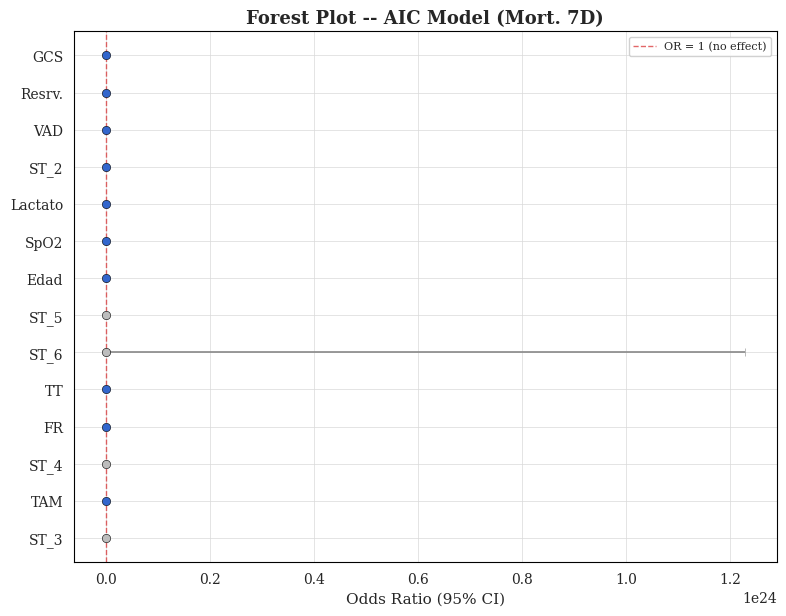


Significant predictors (p < 0.05): 10/14
Non-significant (consider excluding): ['ST_5', 'ST_6', 'ST_4', 'ST_3']
Strongest predictors (|log OR| > 0.5): ['Resrv.', 'VAD', 'ST_2']


In [ ]:
"""
PURPOSE : Rank AIC-selected variables by significance, effect size, and precision.
INPUT   : sm_aic -- fitted statsmodels Logit result from AIC selection.
OUTPUT  : Ranked summary table + Zhang-styled forest plot of Odds Ratios.
"""

# Build ranking table
coef_full = coef_table_sm_full(sm_aic, drop_const=True)
coef_full["abs_log_OR"]   = np.abs(coef_full["beta"])
coef_full["CI_width"]     = coef_full["CI_high"] - coef_full["CI_low"]
coef_full["significant"]  = coef_full["p_value"] < 0.05
coef_full["OR_crosses_1"] = (coef_full["OR_CI_low"] <= 1) & (coef_full["OR_CI_high"] >= 1)

coef_full["rank_p"]  = coef_full["p_value"].rank()
coef_full["rank_OR"] = coef_full["abs_log_OR"].rank(ascending=False)
coef_full["rank_composite"] = (coef_full["rank_p"] + coef_full["rank_OR"]) / 2
coef_full = coef_full.sort_values("rank_composite")

display(Markdown(f"### Variable ranking -- {TARGET_COL}"))
rank_cols = ["variable", "beta", "se", "p_value", "OR", "OR_CI_low", "OR_CI_high",
             "significant", "OR_crosses_1"]
display(coef_full[rank_cols].round(4).reset_index(drop=True))

# ── Forest plot (Zhang theme_bw style) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, max(3.5, 0.45 * len(coef_full))))
y_pos = range(len(coef_full))

for yi, (_, row) in zip(y_pos, coef_full.iterrows()):
    clr = TFG_COLORS["loess_curve"] if row["significant"] else "#bdbdbd"
    ax.errorbar(row["OR"], yi,
                xerr=[[row["OR"] - row["OR_CI_low"]], [row["OR_CI_high"] - row["OR"]]],
                fmt="o", color=clr, ecolor="#888888", elinewidth=1.2, capsize=3, ms=6,
                markeredgecolor="black", markeredgewidth=0.4, zorder=5)

ax.axvline(1.0, color=TFG_COLORS["ref_line"], linestyle="--", lw=1, alpha=0.7,
           label="OR = 1 (no effect)")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(coef_full["variable"].values)
ax.set_xlabel("Odds Ratio (95% CI)")
ax.set_title(f"Forest Plot -- AIC Model ({TARGET_COL})")
ax.legend(fontsize=8)
ax.invert_yaxis()
fig.tight_layout()
_save_fig(fig, f"fig_05_forest_plot_{TARGET_SUFFIX}.png")

n_sig = coef_full["significant"].sum()
print(f"\nSignificant predictors (p < 0.05): {n_sig}/{len(coef_full)}")
non_sig = coef_full[~coef_full["significant"]]["variable"].tolist()
if non_sig:
    print(f"Non-significant (consider excluding): {non_sig}")
strong = coef_full[(coef_full["significant"]) & (coef_full["abs_log_OR"] > 0.5)]["variable"].tolist()
if strong:
    print(f"Strongest predictors (|log OR| > 0.5): {strong}")

## **6. K-Means clustering (optional section)**

K-Means partitions patients into k non-overlapping clusters by minimising within-cluster sum of squared Euclidean distances (inertia).

**Preprocessing**: median imputation + z-score standardisation (K-Means is distance-based and scale-sensitive).

**Model selection**: elbow method (inertia) + silhouette score over k ∈ {2, …, 8}. Optimal k = 3 was consistently identified.

**Validation**: PCA 2D projection, feature heatmap (z-scored cluster medians), mortality rates by cluster.

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `df["Cluster_kmeans_k3"]` | `int` | Cluster assignment per patient |
| Elbow + silhouette plots | plot | Model selection diagnostics |
| Feature heatmap | plot | Cluster signatures |
| Mortality table | `pd.DataFrame` | Event rates per cluster per outcome |

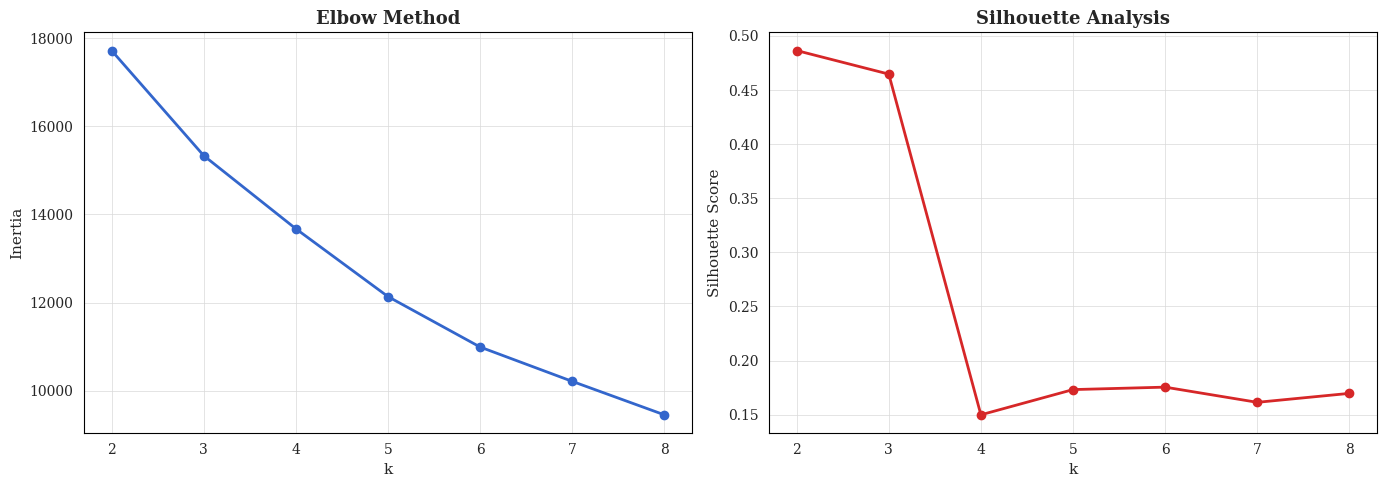

Cluster distribution:
Cluster_kmeans_k3
0    2098
1     265
2      13
Name: count, dtype: int64

Median feature values per cluster:


,Edad,GCS,Lactato,SpO2,TT,TAM,FR,Resrv.,VAD
Cluster_kmeans_k3,,,,,,,,,
0,68.0,15.0,2.8,96.0,36.3,99.33,17.0,0.0,0.0
1,76.0,11.0,4.8,81.0,36.3,95.00,24.0,1.0,0.0
2,63.0,3.0,6.4,68.0,35.9,70.00,6.0,0.0,1.0


In [ ]:
# NOTE: Clustering is purely descriptive/exploratory and does NOT feed
# the scoring model (10). It is intentionally fitted on the full dataset
# to maximise cluster stability and visual clarity. No information from
# cluster labels leaks into the train/test scoring pipeline.
cluster_features = FEATURES
outcomes = ALL_MORT_COLS

# Preprocessing pipeline (clustering only — does not modify df)
preprocess_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

X_cluster = df[cluster_features].copy()
X_scaled  = preprocess_pipe.fit_transform(X_cluster)

# Elbow + silhouette
Ks = range(2, 9)
inertias, silhouettes = [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000,
                                         random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(Ks), inertias, "o-", color=TFG_COLORS["loess_curve"], lw=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method", fontweight="bold")
axes[1].plot(list(Ks), silhouettes, "o-", color=TFG_COLORS["ref_line"], lw=2)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis", fontweight="bold")
plt.tight_layout()
_save_fig(fig, "fig_06_kmeans_elbow_silhouette.png")

# Fit k=3
k_opt = 3
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
df[f"Cluster_kmeans_k{k_opt}"] = km_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(df[f"Cluster_kmeans_k{k_opt}"].value_counts().sort_index())
print("\nMedian feature values per cluster:")
display(df.groupby(f"Cluster_kmeans_k{k_opt}")[cluster_features].median().round(2))

### K-Means validation — mortality rates and visualisation

Four views characterise the three K-Means clusters:

| Panel | Content | Purpose |
|-------|---------|---------|
| PCA scatter | 2D projection of standardised space, coloured by cluster | Geometric separation |
| Feature heatmap | Z-scored cluster medians per predictor | Cluster signature profiles |
| Medians ± IQR bar chart | Key variables: GCS, Lactato, SpO2, Edad | Clinical characterisation |
| Mortality stacked bars | Event rates per cluster per outcome | Clinical validity |

> Clustering is fitted on `df` (full dataset) for maximum stability.
> Cluster labels are **not** fed to the scoring model (10); they serve descriptive purposes only.



── Mort. 2D ──


,Events,N,Mortality %
Cluster_kmeans_k3,,,
0,35,2098,1.67
1,72,265,27.17
2,7,13,53.85



── Mort. 7D ──


,Events,N,Mortality %
Cluster_kmeans_k3,,,
0,71,2098,3.38
1,93,265,35.09
2,9,13,69.23



── Mort. 30D ──


,Events,N,Mortality %
Cluster_kmeans_k3,,,
0,134,2098,6.39
1,116,265,43.77
2,11,13,84.62


/tmp/ipykernel_3384/1281370851.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


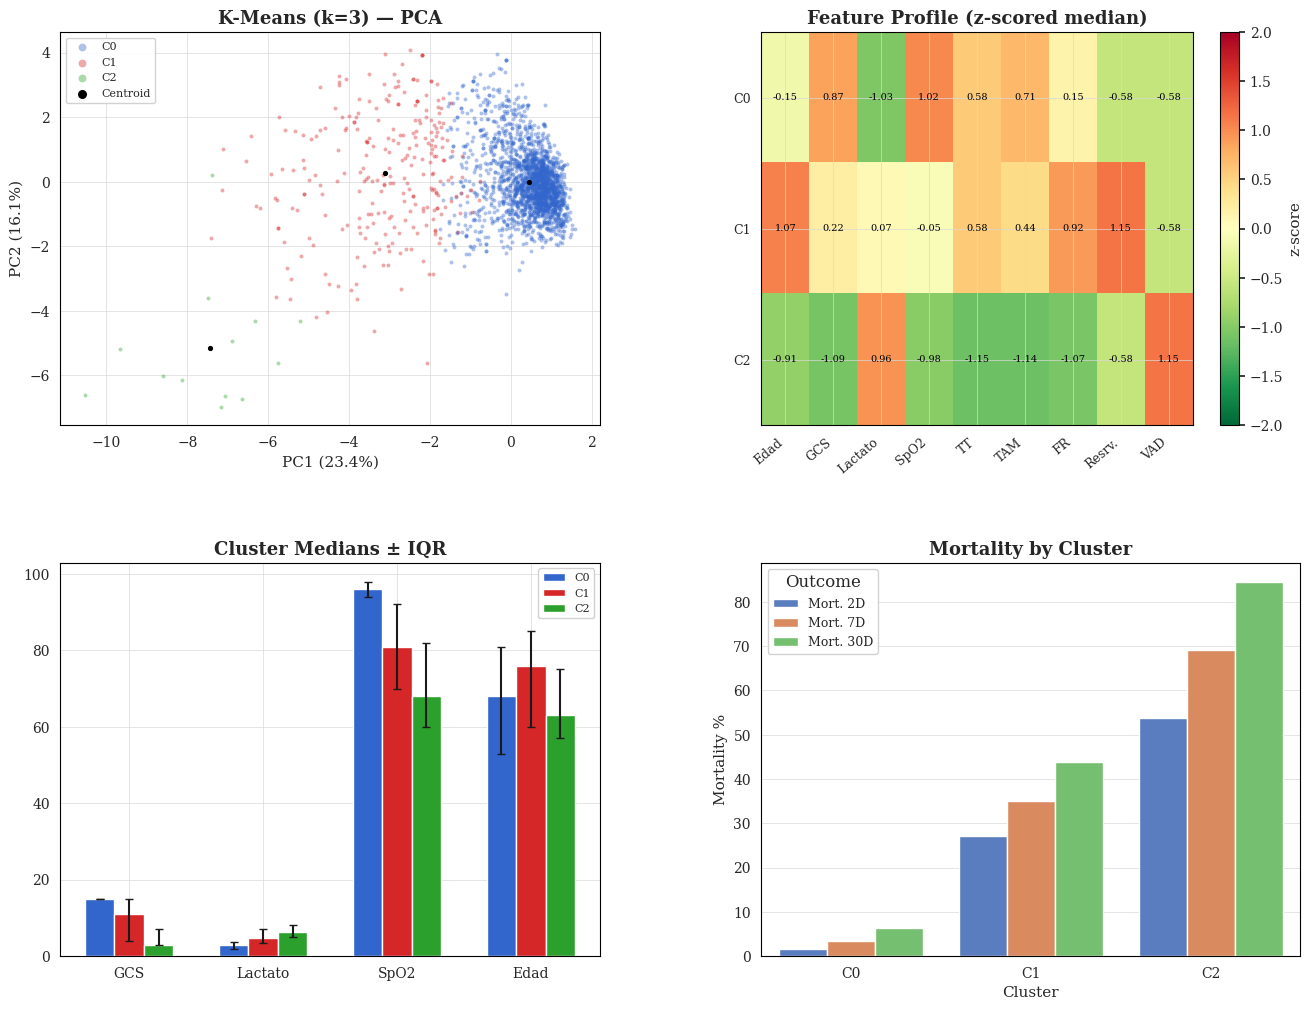

In [ ]:
k = 3
cluster_col = f"Cluster_kmeans_k{k}"

# Mortality by cluster
for oc in ALL_MORT_COLS:
    if oc not in df.columns:
        continue
    tab = df.groupby(cluster_col)[oc].agg(["sum", "count", "mean"])
    tab["mean"] = (tab["mean"] * 100).round(2)
    tab.columns = ["Events", "N", "Mortality %"]
    print(f"\n── {oc} ──")
    display(tab)

# 4-panel visualisation
colors_k = [TFG_COLORS["loess_curve"], TFG_COLORS["ref_line"], TFG_COLORS["cutpoint"]]
labels_k = {0: "C0", 1: "C1", 2: "C2"}

fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# PCA scatter
ax1 = fig.add_subplot(gs[0, 0])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
for c in range(k):
    mask = df[cluster_col].values == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.4,
                color=colors_k[c], label=labels_k[c], linewidths=0)
centroids_pca = pca.transform(km_final.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=30, marker=".", color="black", zorder=5, label="Centroid")
var_exp = pca.explained_variance_ratio_
ax1.set_xlabel(f"PC1 ({var_exp[0]:.1%})"); ax1.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
ax1.set_title("K-Means (k=3) — PCA", fontweight="bold")
ax1.legend(fontsize=8, markerscale=2); # grid inherited from Zhang style

# Feature heatmap
ax2 = fig.add_subplot(gs[0, 1])
cluster_medians = (df.groupby(cluster_col)[cluster_features]
                   .apply(lambda g: g.apply(pd.to_numeric, errors="coerce").median())
                   .apply(lambda col: (col - col.mean()) / (col.std() + 1e-8)))
im = ax2.imshow(cluster_medians.values.astype(float), cmap="RdYlGn_r", aspect="auto",
                vmin=-2, vmax=2)
ax2.set_xticks(range(len(cluster_features)))
ax2.set_xticklabels(cluster_features, rotation=40, ha="right", fontsize=9)
ax2.set_yticks(range(k))
ax2.set_yticklabels([labels_k[i] for i in range(k)], fontsize=9)
ax2.set_title("Feature Profile (z-scored median)", fontweight="bold")
plt.colorbar(im, ax=ax2, label="z-score")
for i in range(k):
    for j in range(len(cluster_features)):
        val = cluster_medians.iloc[i, j]
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=7, color="white" if abs(val) > 1.2 else "black")

# Boxplots
ax3 = fig.add_subplot(gs[1, 0])
key_vars = ["GCS", "Lactato", "SpO2", "Edad"]
n_vars = len(key_vars); width = 0.22; x = np.arange(n_vars)
for c in range(k):
    mask = df[cluster_col] == c
    medians = [df.loc[mask, v].median() for v in key_vars]
    q25 = [df.loc[mask, v].quantile(0.25) for v in key_vars]
    q75 = [df.loc[mask, v].quantile(0.75) for v in key_vars]
    errs = [[m - q for m, q in zip(medians, q25)], [q - m for m, q in zip(medians, q75)]]
    ax3.bar(x + c * width, medians, width, label=labels_k[c], color=colors_k[c],
            yerr=errs, capsize=3)
ax3.set_xticks(x + width); ax3.set_xticklabels(key_vars)
ax3.set_title("Cluster Medians ± IQR", fontweight="bold")
ax3.legend(fontsize=8)

# Mortality bars
ax4 = fig.add_subplot(gs[1, 1])
mort_data = []
for oc in ALL_MORT_COLS:
    if oc not in df.columns:
        continue
    for c in range(k):
        mask = df[cluster_col] == c
        rate = df.loc[mask, oc].mean() * 100
        mort_data.append({"Outcome": oc, "Cluster": labels_k[c], "Mortality %": rate})
mort_df = pd.DataFrame(mort_data)
if not mort_df.empty:
    sns.barplot(data=mort_df, x="Cluster", y="Mortality %", hue="Outcome",
                palette="muted", ax=ax4)
    ax4.set_title("Mortality by Cluster", fontweight="bold")

plt.tight_layout()
_save_fig(fig, "fig_06_kmeans_validation_panels.png")

## **7. FAMD + Ward hierarchical clustering (optional section)**

The dataset contains mixed-type variables: continuous (*Edad*, *GCS*, *Lactato*, *SpO2*, *TT*, *FR*), binary (O2), and nominal categorical (*Ritmo*, *ST*). FAMD generalises PCA to handle all three types simultaneously, producing a Euclidean embedding suitable for Ward's agglomerative hierarchical clustering.

### Function: `famd_ward_pipeline()`

| Parameter | Value | Description |
|-----------|-------|-------------|
| `features` | `FEATURES` | Active feature set for the selected outcome |
| `k` | `3` | Number of clusters |
| `n_components` | `8` | FAMD dimensions retained |
| `cat_override` | `CATEGORICAL_VARS` | Columns forced to categorical regardless of dtype |

### Output

Validation metrics (silhouette, Calinski-Harabasz, Davies-Bouldin), FAMD scatter,
Ward dendrogram, PCA projection in original feature space, cluster heatmap,
and mortality rates per cluster.


In [ ]:
def to_event_binary(series: pd.Series) -> pd.Series:
    """Convert a mortality column to binary (0/1), handling bool/str/int."""
    s = series.copy()
    if s.dtype == bool:
        return s.astype(int)
    if s.dtype == object:
        s = s.str.strip().str.lower().map({"si": 1, "sí": 1, "yes": 1, "1": 1,
                                            "no": 0, "0": 0})
    return pd.to_numeric(s, errors="coerce")


def famd_ward_pipeline(
    df: pd.DataFrame, features: Sequence[str], k: int = 3,
    n_components: int = 8, random_state: int = 42,
    cat_override: Optional[Sequence[str]] = None,
) -> Dict[str, object]:
    """FAMD + Ward clustering pipeline. Falls back to PCA when all features are
    quantitative. Returns dict with features, famd, reducer_name, X_f, Z, labels, metrics.

    Parameters
    ----------
    cat_override : columns to force-treat as categorical regardless of dtype.
                   Defaults to an empty list if not provided.
    """
    _cat_override = set(cat_override) if cat_override is not None else set()

    feats = [c for c in features if c in df.columns]
    X = df[feats].copy()
    num_cols = [c for c in feats if c not in _cat_override
                and X[c].dtype.kind in "iufc" and X[c].nunique(dropna=True) > 2]
    cat_cols = [c for c in feats if c not in num_cols]

    if num_cols:
        X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])
        X[num_cols] = StandardScaler().fit_transform(X[num_cols])
    if cat_cols:
        X[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])
        for c in cat_cols:
            X[c] = X[c].astype("category")

    n_comp = min(n_components, len(feats))

    if cat_cols:
        # Mixed-type data: use FAMD
        reducer = prince.FAMD(n_components=n_comp, n_iter=10,
                              random_state=random_state).fit(X)
        X_f = reducer.row_coordinates(X)
        reducer_name = "FAMD"
    else:
        # All-quantitative data: fall back to PCA
        print("  [famd_ward_pipeline] No categorical variables in feature set "
              "— falling back to PCA.")
        X_num = X[num_cols].values
        reducer = PCA(n_components=n_comp, random_state=random_state).fit(X_num)
        X_f = pd.DataFrame(
            reducer.transform(X_num),
            columns=[f"PC{i+1}" for i in range(n_comp)],
            index=X.index,
        )
        reducer_name = "PCA"

    Z = linkage(X_f.values, method="ward")
    labels = fcluster(Z, t=k, criterion="maxclust") - 1
    metrics = {
        "silhouette":        float(silhouette_score(X_f.values, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X_f.values, labels)),
        "davies_bouldin":    float(davies_bouldin_score(X_f.values, labels)),
    }
    return {"features": feats, "famd": reducer, "reducer_name": reducer_name,
            "X_f": X_f, "Z": Z, "labels": labels, "metrics": metrics}


def plot_famd_scatter(X_f: pd.DataFrame, labels: np.ndarray, title: str,
                       fname: str = "") -> None:
    """Scatter plot of the first two FAMD (or PCA) dimensions, coloured by cluster label."""
    fig, ax = plt.subplots(figsize=(6, 5))
    palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))
    for i, lab in enumerate(np.unique(labels)):
        mask = labels == lab
        ax.scatter(X_f.iloc[mask, 0], X_f.iloc[mask, 1],
                   s=12, alpha=0.6, color=palette[i], label=f"Cluster {lab}")
    ax.set_xlabel("FAMD Dim 1"); ax.set_ylabel("FAMD Dim 2")
    ax.set_title(title); ax.legend()
    plt.tight_layout()
    if fname:
        _save_fig(fig, fname)
    else:
        plt.show(); plt.close(fig)


def plot_dendrogram(Z: np.ndarray, k: int, title: str,
                    fname: str = "") -> None:
    """Plot a Ward hierarchical clustering dendrogram with a horizontal cut at *k* clusters."""
    fig, ax = plt.subplots(figsize=(11, 4))
    cut_height = sorted(Z[:, 2], reverse=True)[k - 1]
    dendrogram(Z, no_labels=True, ax=ax, color_threshold=cut_height)
    ax.axhline(y=cut_height, color="red", linestyle="--", linewidth=1.2, label=f"Cut at k={k}")
    ax.set_title(title); ax.set_ylabel("Ward distance"); ax.legend()
    plt.tight_layout()
    if fname:
        _save_fig(fig, fname)
    else:
        plt.show(); plt.close(fig)


def plot_mortality_bars(df: pd.DataFrame, cluster_col: str,
                        mort_cols: Sequence[str]) -> None:
    """Stacked bar chart of mortality rates per cluster for each outcome."""
    rows = []
    for m in mort_cols:
        if m not in df.columns:
            continue
        y = to_event_binary(df[m])
        tmp = pd.DataFrame({cluster_col: df[cluster_col], m: y}).dropna()
        rate = tmp.groupby(cluster_col)[m].mean() * 100
        for cid, val in rate.items():
            rows.append({"Outcome": m, "Cluster": cid, "Mortality (%)": float(val)})
    out = pd.DataFrame(rows)
    if out.empty:
        return
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=out, x="Cluster", y="Mortality (%)", hue="Outcome",
                palette="muted", ax=ax)
    ax.set_title("Mortality rate by cluster")
    plt.tight_layout()
    _save_fig(fig, "fig_07_famd_mortality_bars.png")


def plot_famd_variance(famd, title: str, fname: str = "") -> None:
    """Plot explained variance/inertia per component. Handles both FAMD (prince)
    and PCA (sklearn) reducer objects."""
    if hasattr(famd, "explained_inertia_"):
        # prince.FAMD
        ev = np.array(famd.explained_inertia_)
    elif hasattr(famd, "eigenvalues_"):
        # older prince versions
        ev = np.array(famd.eigenvalues_) / np.array(famd.eigenvalues_).sum()
    elif hasattr(famd, "explained_variance_ratio_"):
        # sklearn PCA fallback
        ev = np.array(famd.explained_variance_ratio_)
    else:
        print("  [plot_famd_variance] Cannot extract explained variance — skipping plot.")
        return

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(range(1, len(ev) + 1), ev * 100, color="steelblue")
    ax.set_xlabel("Component")
    ax.set_ylabel("Explained inertia (%)")
    ax.set_title(title)
    plt.tight_layout()
    if fname:
        _save_fig(fig, fname)
    else:
        plt.show()
        plt.close(fig)


def plot_pca_clusters(df: pd.DataFrame, features: Sequence[str],
                      cluster_col: str,
                      cat_override: Optional[Sequence[str]] = None) -> None:
    """PCA 2D projection of the feature space coloured by cluster assignment."""
    _cat_override = set(cat_override) if cat_override is not None else set()

    feats = [f for f in features if f in df.columns]
    X = df[feats].copy()
    num_cols = [c for c in feats if c not in _cat_override
                and X[c].dtype.kind in "iufc" and X[c].nunique(dropna=True) > 2]
    cat_cols = [c for c in feats if c not in num_cols]
    X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])
    X[num_cols] = StandardScaler().fit_transform(X[num_cols])
    if cat_cols:
        X[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)
    var = pca.explained_variance_ratio_ * 100
    labels = df[cluster_col].values
    palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))
    fig, ax = plt.subplots(figsize=(6, 5))
    for i, cl in enumerate(sorted(np.unique(labels))):
        mask = labels == cl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=12, alpha=0.6, color=palette[i], label=f"Cluster {cl}")
    ax.set_xlabel(f"PC1 ({var[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
    ax.set_title("PCA — clusters in original feature space")
    ax.legend(title="Cluster")
    plt.tight_layout()
    _save_fig(fig, "fig_07_famd_pca_clusters.png")


def plot_cluster_heatmap(df: pd.DataFrame, features: Sequence[str],
                         cluster_col: str) -> None:
    """Heatmap of z-scored cluster medians for each continuous feature."""
    feats = [f for f in features if f in df.columns]
    med = df.groupby(cluster_col)[feats].median()
    z = (med - med.mean()) / (med.std() + 1e-8)
    fig, ax = plt.subplots(figsize=(10, 3.5))
    sns.heatmap(z, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, ax=ax)
    ax.set_title("Cluster profile heatmap (z-scored medians)")
    plt.tight_layout()
    _save_fig(fig, "fig_07_famd_cluster_heatmap.png")

### FAMD + Ward — execution and visualisation

**Parameters used:**
- `K = 3` — consistent with K-Means optimal k (6).
- `n_components = 8` — typically retains ≥ 80 % inertia.
- `cat_override = CATEGORICAL_VARS` — forces `Ritmo` / `ST` to categorical within FAMD.

**Plots produced (saved to OUTPUT_DIR):**

| Plot | Filename |
|------|----------|
| FAMD Dim 1 × Dim 2 scatter | `fig_07_famd_scatter.png` |
| Ward dendrogram | `fig_07_famd_dendrogram.png` |
| FAMD explained inertia | `fig_07_famd_variance.png` |
| PCA projection (original feature space) | `fig_07_famd_pca_clusters.png` |
| Feature profile heatmap (z-scored medians) | `fig_07_famd_cluster_heatmap.png` |
| Mortality rate bars | `fig_07_famd_mortality_bars.png` |


FAMD + Ward  (k=3)
  Silhouette        : 0.4813
  Calinski-Harabasz : 490.14
  Davies-Bouldin    : 1.0627


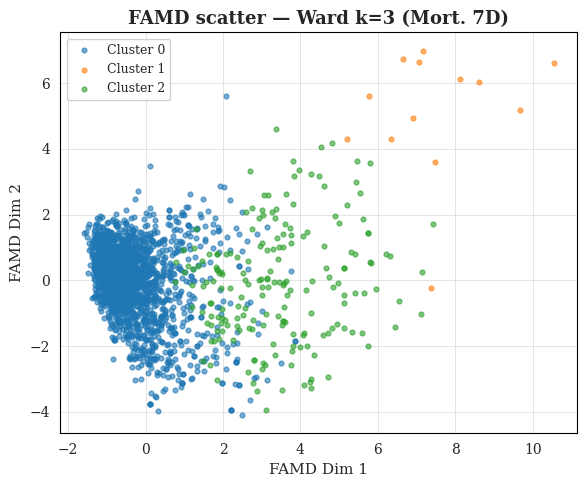

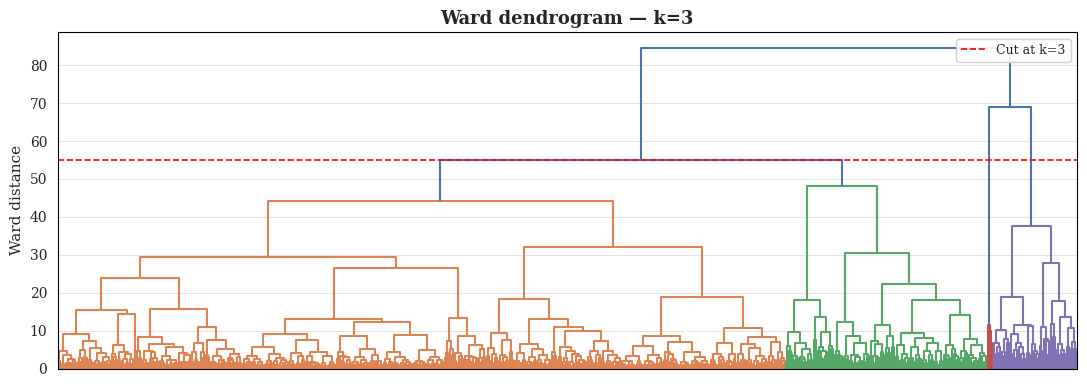

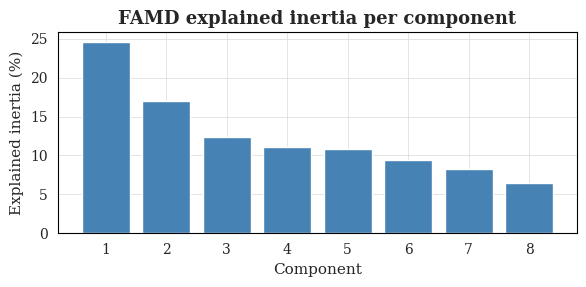

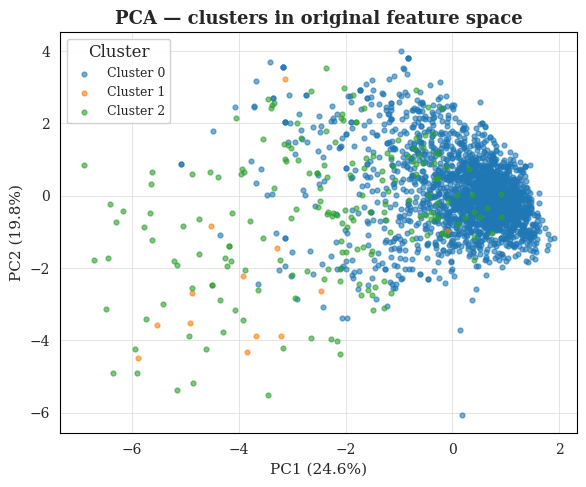

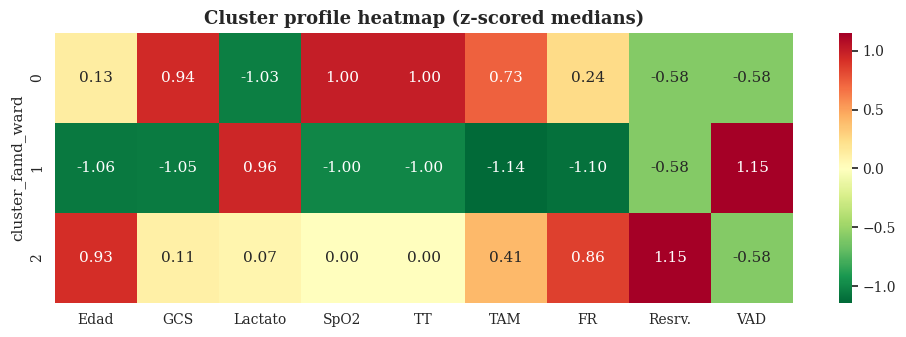

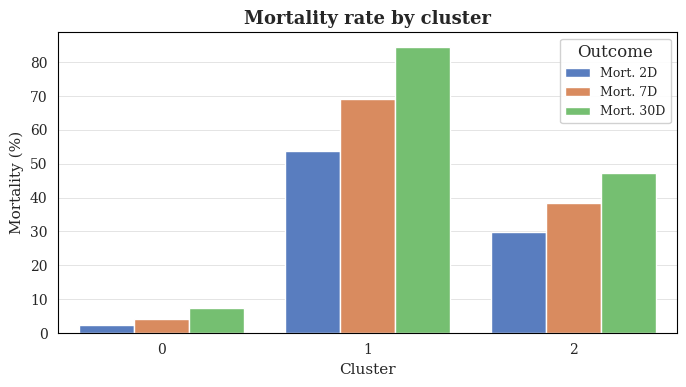

In [ ]:
# ── FAMD + Ward clustering ───────────────────────────────────────────────────
# Runs on the full dataset for maximum cluster stability.
# cat_override ensures Ritmo and ST are treated as categorical by FAMD
# regardless of their storage dtype in the DataFrame.

K = 3
res = famd_ward_pipeline(
    df, FEATURES, k=K, n_components=8,
    random_state=RANDOM_STATE,
    cat_override=list(CATEGORICAL_VARS),
)
df["cluster_famd_ward"] = res["labels"]

print(f"FAMD + Ward  (k={K})")
print(f"  Silhouette        : {res['metrics']['silhouette']:.4f}")
print(f"  Calinski-Harabasz : {res['metrics']['calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin    : {res['metrics']['davies_bouldin']:.4f}")

cluster_col_fw = "cluster_famd_ward"
plot_famd_scatter(res["X_f"], res["labels"],
                  title=f"FAMD scatter — Ward k={K} ({TARGET_COL})",
                  fname="fig_07_famd_scatter.png")
plot_dendrogram(res["Z"], K,
                title=f"Ward dendrogram — k={K}",
                fname="fig_07_famd_dendrogram.png")
plot_famd_variance(res["famd"],
                   title="FAMD explained inertia per component",
                   fname="fig_07_famd_variance.png")
plot_pca_clusters(df, FEATURES, cluster_col_fw,
                  cat_override=list(CATEGORICAL_VARS))
plot_cluster_heatmap(df, [v for v in FEATURES if v not in CATEGORICAL_VARS],
                     cluster_col_fw)
plot_mortality_bars(df, cluster_col_fw, ALL_MORT_COLS)


## **8. Cutpoint identification via LOESS**

This section provides **visual diagnostics** for continuous variable risk curves:

1. **Top panel**: raw events (jittered), LOESS smoothed risk curve, 95 % Bayesian interval
2. **Bottom panel**: event density along X

Cut-points used downstream (**section 9.**) are taken from `CLINICAL_CUTS_PER_OUTCOME` (defined in **section 2**).

>LOESS candidate cuts shown here in grey are for visual reference only and are only used as a fallback if no clinical cut is defined.

>Green dashed lines represent the **active cut-points** that will be applied in 9.

### Visualisation improvements
- Deaths shown **inside** the \[0, 1\] area with jitter to avoid overplotting
- Density panel shows where deaths concentrate along X
- Cutpoints use a segment-aware greedy selection algorithm
- Monotonic constraints applied via `IsotonicRegression` (sklearn) or cumulative fallback


In [ ]:
# Conditional imports for LOESS utilities (core libs already in 1)
from statsmodels.nonparametric.smoothers_lowess import lowess

try:
    from sklearn.isotonic import IsotonicRegression
    _HAS_ISO = True
except ImportError:
    _HAS_ISO = False

try:
    from scipy.signal import savgol_filter
    _HAS_SCIPY_SIGNAL = True
except ImportError:
    _HAS_SCIPY_SIGNAL = False

try:
    from scipy.stats import beta as _beta_dist
    _HAS_SCIPY_BETA = True
except ImportError:
    _HAS_SCIPY_BETA = False


def _enforce_monotone(y: np.ndarray, direction: str) -> np.ndarray:
    """Fallback monotonic enforcement (no sklearn)."""
    y = np.asarray(y, dtype=float)
    if direction == "increasing":
        return np.maximum.accumulate(y)
    if direction == "decreasing":
        return np.minimum.accumulate(y)
    return y


def _beta_ci(deaths: np.ndarray, n: np.ndarray, a: float = 0.5, b: float = 0.5,
             alpha: float = 0.05) -> Tuple[np.ndarray, np.ndarray]:
    """
    Jeffreys-prior Beta posterior interval for a binomial proportion.
    Fast and stable even when counts are small.
    """
    deaths = np.asarray(deaths, dtype=float)
    n = np.asarray(n, dtype=float)
    aa = deaths + a
    bb = (n - deaths) + b

    if _HAS_SCIPY_BETA:
        lo = _beta_dist.ppf(alpha / 2, aa, bb)
        hi = _beta_dist.ppf(1 - alpha / 2, aa, bb)
        return lo, hi

    # Fallback: normal approx (less accurate in small n)
    p = aa / (aa + bb)
    se = np.sqrt(p * (1 - p) / np.maximum(n, 1))
    z = 1.96
    return np.clip(p - z * se, 0, 1), np.clip(p + z * se, 0, 1)


def _prepare_xy(df: pd.DataFrame, x_col: str, y_col: str,
                trim_percentile: float = 5.0) -> Tuple[np.ndarray, np.ndarray]:
    """Extract and clean (x, y) arrays for LOESS from a DataFrame.

    Drops missing values, converts y to 0/1 via ``to_event_binary``, and
    optionally trims extreme percentiles of x to reduce outlier influence.
    """
    tmp = df[[x_col, y_col]].copy()
    tmp[x_col] = pd.to_numeric(tmp[x_col], errors="coerce")
    y01 = to_event_binary(tmp[y_col])
    tmp["_y01"] = y01
    tmp = tmp.dropna(subset=[x_col, "_y01"]).sort_values(x_col)

    x = tmp[x_col].to_numpy(dtype=float)
    y = tmp["_y01"].to_numpy(dtype=float)

    if len(x) == 0:
        return x, y

    lo = np.percentile(x, trim_percentile)
    hi = np.percentile(x, 100 - trim_percentile)
    keep = (x >= lo) & (x <= hi)
    return x[keep], y[keep]


def _bin_event_rate(
    x: np.ndarray,
    y: np.ndarray,
    n_bins: int = 70,
    min_bin_n: int = 25,
    bayes_a: float = 0.5,
    bayes_b: float = 0.5
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bin X and compute:
      - bin_x      median X per bin
      - bin_rate   smoothed (Bayesian) event rate per bin
      - bin_d      deaths per bin
      - bin_n      N per bin
      - ci_low/hi  Beta posterior interval for each bin (raw, before LOWESS)
    """
    if len(x) < 200:
        return (np.array([]),) * 6

    # Prefer quantile bins to avoid empty bins in long-tailed vars
    try:
        bins = pd.qcut(x, q=n_bins, duplicates="drop")
    except Exception:
        bins = pd.cut(x, bins=n_bins)

    s = pd.DataFrame({"x": x, "y": y, "bin": bins})
    g = s.groupby("bin", observed=True)

    bin_x = g["x"].median().to_numpy()
    bin_n = g.size().to_numpy()
    bin_d = g["y"].sum().to_numpy()

    keep = bin_n >= min_bin_n
    bin_x, bin_n, bin_d = bin_x[keep], bin_n[keep], bin_d[keep]

    if len(bin_x) < 12:
        return (bin_x, np.array([]), bin_d, bin_n, np.array([]), np.array([]))

    order = np.argsort(bin_x)
    bin_x, bin_n, bin_d = bin_x[order], bin_n[order], bin_d[order]

    # Bayesian-smoothed rate
    bin_rate = (bin_d + bayes_a) / (bin_n + bayes_a + bayes_b)

    ci_low, ci_hi = _beta_ci(bin_d, bin_n, a=bayes_a, b=bayes_b, alpha=0.05)
    return bin_x, bin_rate, bin_d, bin_n, ci_low, ci_hi


def _lowess_smooth(x: np.ndarray, y: np.ndarray, frac: float, it: int = 0) -> np.ndarray:
    return np.clip(lowess(y, x, frac=frac, it=it, return_sorted=False), 0, 1)


def _smooth_for_derivatives(y: np.ndarray, window_frac: float = 0.14) -> np.ndarray:
    """
    Stabilise derivatives. If SciPy is available, use Savitzky-Golay.
    Otherwise, fall back to a simple rolling mean.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 9:
        return y

    if _HAS_SCIPY_SIGNAL:
        w = max(9, int(round(window_frac * n)))
        if w % 2 == 0:
            w += 1
        w = min(w, n - 1 if (n - 1) % 2 == 1 else n - 2)
        w = max(w, 9)
        return savgol_filter(y, window_length=w, polyorder=2, mode="interp")

    # fallback rolling
    k = max(5, int(round(window_frac * n)))
    return pd.Series(y).rolling(k, center=True, min_periods=1).mean().to_numpy()


def _rank_cut_candidates(
    bin_x: np.ndarray,
    sm: np.ndarray,
    bin_d: np.ndarray,
    bin_n: np.ndarray,
    max_candidates: int = 25,
    min_zone_n: int = 50,
    min_risk_delta: float = 0.01,
    min_risk_level: float = 0.02,
    edge_exclude_frac: float = 0.06,
) -> pd.DataFrame:
    """
    Score candidates at each bin index i (cut at bin_x[i]) using:
      - risk jump (left vs right)
      - death balance (min deaths left/right)
      - curvature (second derivative magnitude)
    Returns a ranked table for human inspection.
    """
    if len(bin_x) < 12:
        return pd.DataFrame()

    sm2 = _smooth_for_derivatives(sm)
    d1 = np.gradient(sm2, bin_x)
    d2 = np.gradient(d1, bin_x)
    curv = np.abs(d2)

    n_bins = len(bin_x)
    edge = int(round(edge_exclude_frac * n_bins))
    edge = max(edge, 2)

    rows = []
    csum_n = np.cumsum(bin_n)
    csum_d = np.cumsum(bin_d)
    total_n = float(csum_n[-1])
    total_d = float(csum_d[-1])

    for i in range(edge, n_bins - edge - 1):
        left_n = float(csum_n[i])
        right_n = float(total_n - left_n)
        if left_n < min_zone_n or right_n < min_zone_n:
            continue

        left_d = float(csum_d[i])
        right_d = float(total_d - left_d)

        left_rate = left_d / left_n if left_n > 0 else 0.0
        right_rate = right_d / right_n if right_n > 0 else 0.0
        delta = abs(right_rate - left_rate)

        if delta < min_risk_delta:
            continue
        if max(left_rate, right_rate) < min_risk_level:
            continue

        death_balance = min(left_d, right_d)
        score = (delta * (death_balance + 1.0) ** 0.5 * (curv[i] + 1e-9) ** 0.35)

        rows.append({
            "cut_x": float(bin_x[i]),
            "score": float(score),
            "delta_rate": float(delta),
            "left_n": int(left_n),
            "right_n": int(right_n),
            "left_deaths": int(left_d),
            "right_deaths": int(right_d),
            "left_rate": float(left_rate),
            "right_rate": float(right_rate),
            "curvature": float(curv[i]),
            "idx": int(i),
        })

    if not rows:
        return pd.DataFrame()

    out = (pd.DataFrame(rows)
             .sort_values("score", ascending=False)
             .reset_index(drop=True))

    return out.head(max_candidates)


def loess_cutpoints_v2(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    n_bins: int = 70,
    frac: Optional[float] = None,
    it: int = 0,
    bayes_a: float = 0.5,
    bayes_b: float = 0.5,
    min_bin_n: int = 25,
    trim_percentile: float = 5.0,
    max_cuts: int = 3,
    min_gap_frac: float = 0.15,
    min_risk_delta: float = 0.01,
    min_zone_n: int = 50,
    min_risk_level: float = 0.02,
    monotonic: Optional[str] = None,
) -> Dict:
    """
    Returns a dict with everything needed for plotting + cutpoint inspection:
      - bin_x, bin_rate, bin_d, bin_n, ci_low, ci_hi
      - sm, sm_ci_low, sm_ci_hi (LOWESS-smoothed)
      - candidates (ranked DataFrame)
      - cuts (selected list)
    """
    x, y = _prepare_xy(df, x_col, y_col, trim_percentile=trim_percentile)
    if len(x) < 200:
        return dict(bin_x=np.array([]), cuts=[], candidates=pd.DataFrame())

    bin_x, bin_rate, bin_d, bin_n, ci_low, ci_hi = _bin_event_rate(
        x, y, n_bins=n_bins, min_bin_n=min_bin_n, bayes_a=bayes_a, bayes_b=bayes_b
    )
    if len(bin_x) < 12 or len(bin_rate) == 0:
        return dict(bin_x=bin_x, bin_rate=bin_rate, bin_d=bin_d, bin_n=bin_n,
                    ci_low=ci_low, ci_hi=ci_hi, cuts=[], candidates=pd.DataFrame())

    if frac is None:
        # heuristic: keep a ~10-point neighbourhood, bounded
        frac = float(np.clip(10 / len(bin_x), 0.10, 0.28))

    sm = _lowess_smooth(bin_x, bin_rate, frac=frac, it=it)
    sm_lo = _lowess_smooth(bin_x, ci_low, frac=frac, it=it)
    sm_hi = _lowess_smooth(bin_x, ci_hi, frac=frac, it=it)

    # Monotonic enforcement (prevents sparse-tail drops)
    if monotonic in {"increasing", "decreasing"}:
        if _HAS_ISO:
            inc = (monotonic == "increasing")
            iso = IsotonicRegression(increasing=inc, out_of_bounds="clip")
            sm = iso.fit_transform(bin_x, sm)
            sm_lo = iso.fit_transform(bin_x, sm_lo)
            sm_hi = iso.fit_transform(bin_x, sm_hi)
        else:
            sm = _enforce_monotone(sm, monotonic)
            sm_lo = _enforce_monotone(sm_lo, monotonic)
            sm_hi = _enforce_monotone(sm_hi, monotonic)

    cand = _rank_cut_candidates(
        bin_x, sm, bin_d, bin_n,
        max_candidates=30,
        min_zone_n=min_zone_n,
        min_risk_delta=min_risk_delta,
        min_risk_level=min_risk_level,
    )

    # Segment-aware greedy selection (avoids clustered cuts)
    cuts: List[float] = []
    if not cand.empty:
        x_range = float(bin_x[-1] - bin_x[0])
        min_gap = float(min_gap_frac * x_range)

        # segments as (left_idx, right_idx) inclusive
        segments = [(0, len(bin_x) - 1)]

        def best_in_segment(seg):
        #Return the highest-ranked cutpoint candidate within a single segment.
            l, r = seg
            cseg = cand[(cand["idx"] >= l + 2) & (cand["idx"] <= r - 3)].copy()
            if cseg.empty:
                return None
            return cseg.iloc[0]


        while len(cuts) < max_cuts:
            best_row = None
            best_seg = None

            for seg in segments:
                row = best_in_segment(seg)
                if row is None:
                    continue
                if (best_row is None) or (row["score"] > best_row["score"]):
                    best_row = row
                    best_seg = seg

            if best_row is None:
                break

            cx = float(best_row["cut_x"])
            if any(abs(cx - c) < min_gap for c in cuts):
                # invalidate this one and continue
                cand = cand[cand["cut_x"] != cx].reset_index(drop=True)
                if cand.empty:
                    break
                continue

            cuts.append(cx)
            cuts.sort()

            # split segment
            l, r = best_seg
            i = int(best_row["idx"])
            segments.remove(best_seg)
            segments.extend([(l, i), (i + 1, r)])

    return dict(
        x_raw=x,
        y_raw=y,
        bin_x=bin_x,
        bin_rate=bin_rate,
        bin_d=bin_d,
        bin_n=bin_n,
        ci_low=ci_low,
        ci_hi=ci_hi,
        sm=sm,
        sm_ci_low=sm_lo,
        sm_ci_hi=sm_hi,
        candidates=cand,
        cuts=cuts,
        frac=frac,
    )


> Savitzky-Golay smoothing is applied after LOESS to reduce residual
> oscillation in sparse regions. This affects visual presentation only;
> active cutpoints are defined in `CLINICAL_CUTS_PER_OUTCOME`, not derived
> from the smoothed curve.

Continuous variables for LOESS (Mort. 7D): ['Edad', 'Lactato', 'SpO2', 'TT', 'TAM', 'FR']


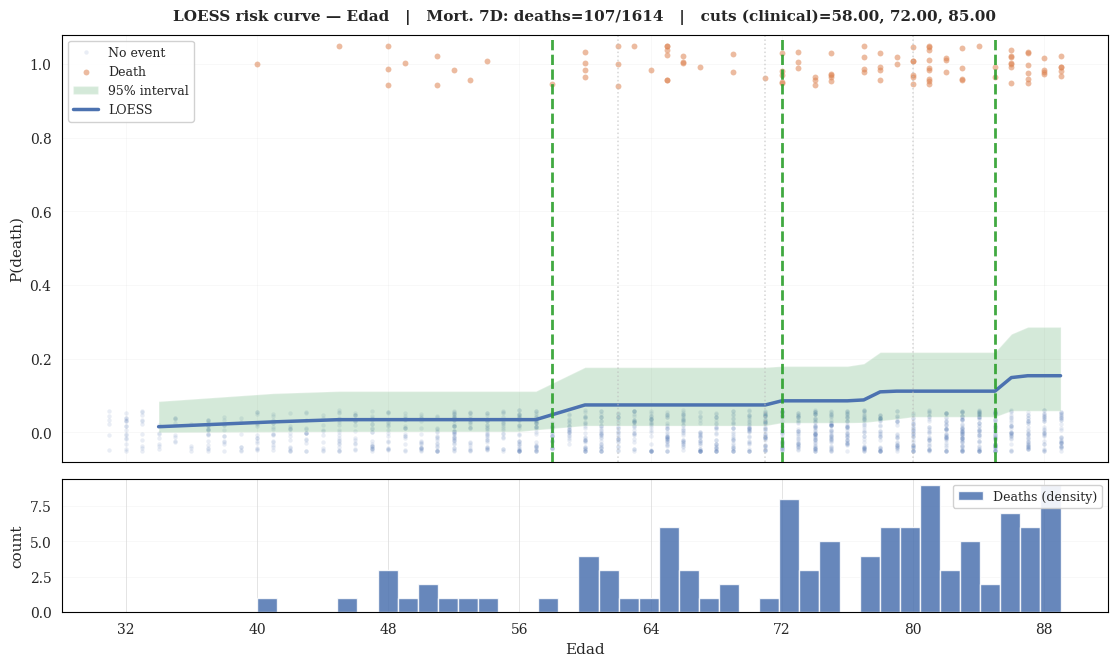

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,80.0,0.0447,0.0498,952,374,57,41,0.0599,0.1096,0.0035
1,79.0,0.0431,0.0576,912,414,51,47,0.0559,0.1135,0.0017
2,78.0,0.0291,0.0554,884,442,49,49,0.0554,0.1109,0.0006
3,62.0,0.0267,0.0542,309,1017,10,88,0.0324,0.0865,0.0043
4,63.0,0.0256,0.0551,336,990,11,87,0.0327,0.0879,0.0032
5,82.0,0.0227,0.0318,1032,294,69,29,0.0669,0.0986,0.0030
6,81.0,0.0199,0.0289,991,335,66,32,0.0666,0.0955,0.0023
7,61.0,0.0187,0.0623,282,1044,7,91,0.0248,0.0872,0.0016
8,71.0,0.0148,0.0585,598,728,25,73,0.0418,0.1003,0.0002
9,56.0,0.0123,0.0672,186,1140,3,95,0.0161,0.0833,0.0011


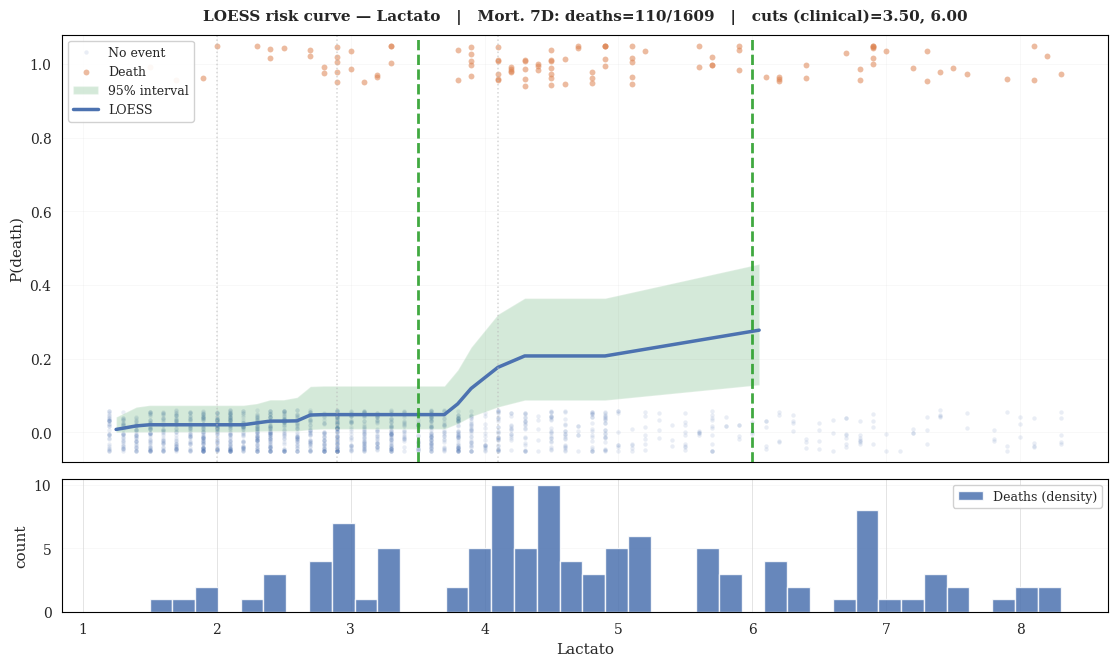

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,4.1,0.8105,0.1876,1238,142,38,31,0.0307,0.2183,0.4629
1,3.9,0.7624,0.1824,1203,177,32,37,0.0266,0.2090,0.4029
2,3.8,0.6872,0.1750,1168,212,27,42,0.0231,0.1981,0.4265
3,4.3,0.2539,0.1882,1263,117,43,26,0.0340,0.2222,0.0212
4,2.9,0.1783,0.0777,848,532,17,52,0.0200,0.0977,0.1727
5,3.0,0.1751,0.0782,879,501,19,50,0.0216,0.0998,0.1387
6,3.1,0.1479,0.0856,923,457,20,49,0.0217,0.1072,0.0618
7,2.8,0.1232,0.0773,767,613,12,57,0.0156,0.0930,0.0970
8,4.5,0.1159,0.1567,1299,81,53,16,0.0408,0.1975,0.0074
9,2.7,0.1014,0.0769,729,651,10,59,0.0137,0.0906,0.0717


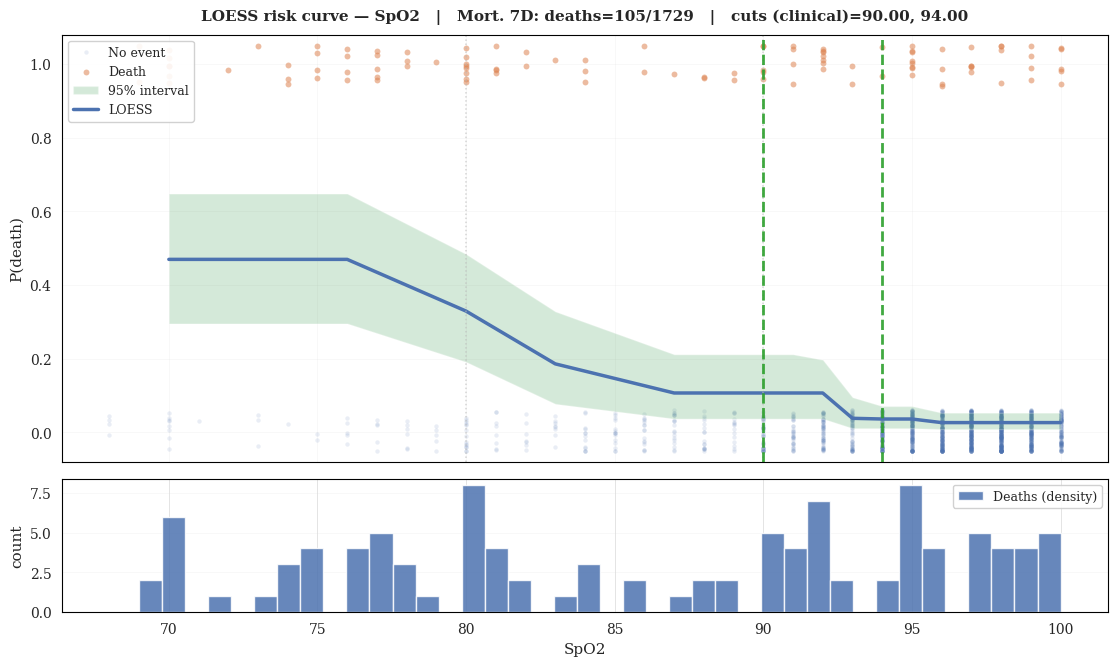

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,90.0,0.2177,0.2143,212,1454,52,45,0.2453,0.0309,0.0044
1,91.0,0.2036,0.1941,251,1415,56,41,0.2231,0.0290,0.0055
2,83.0,0.2002,0.3148,126,1540,44,53,0.3492,0.0344,0.0012
3,80.0,0.1356,0.3756,92,1574,38,59,0.4130,0.0375,0.0003
4,93.0,0.1149,0.1452,382,1284,65,32,0.1702,0.0249,0.0035
5,95.0,0.0696,0.0906,666,1000,75,22,0.1126,0.0220,0.0053
6,94.0,0.0693,0.1083,500,1166,67,30,0.1340,0.0257,0.0021
7,92.0,0.0625,0.1735,317,1349,63,34,0.1987,0.0252,0.0003
8,87.0,0.0551,0.2533,164,1502,47,50,0.2866,0.0333,0.0001
9,96.0,0.0462,0.0709,850,816,79,18,0.0929,0.0221,0.0044


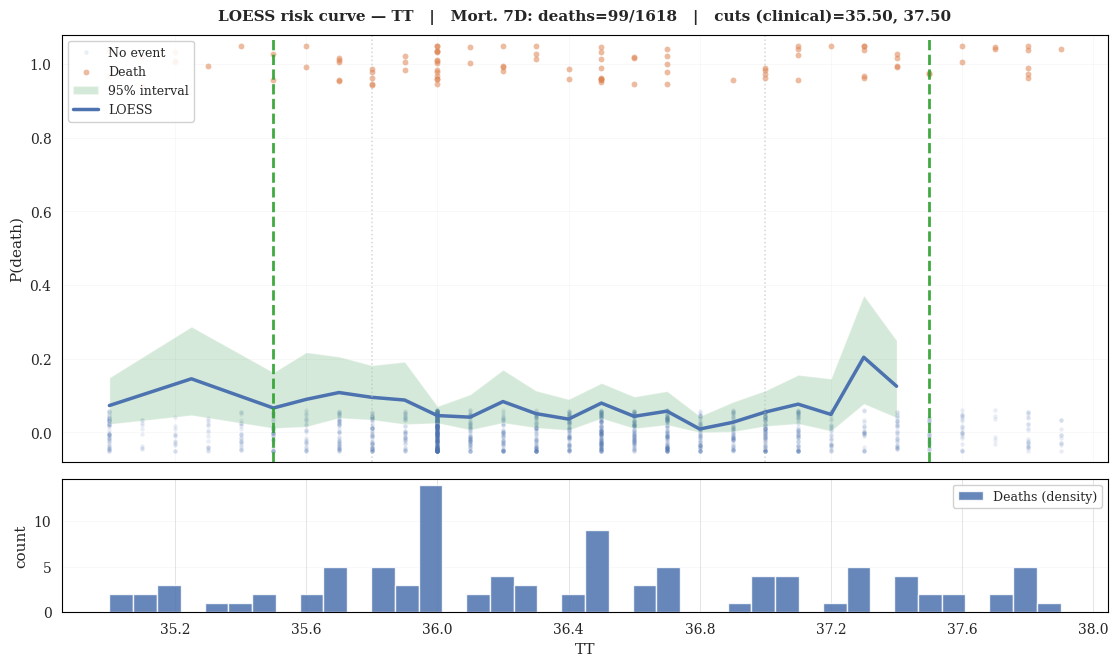

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,37.0,0.1522,0.0409,1356,149,72,14,0.0531,0.0940,0.8942
1,37.1,0.1327,0.0561,1414,91,76,10,0.0537,0.1099,0.3803
2,36.9,0.1231,0.0249,1275,230,68,18,0.0533,0.0783,1.4276
3,35.8,0.1108,0.0325,262,1243,22,64,0.0840,0.0515,0.3780
4,35.9,0.0929,0.0324,301,1204,25,61,0.0831,0.0507,0.1934
5,35.7,0.0870,0.0298,205,1300,17,69,0.0829,0.0531,0.3418
6,35.6,0.0690,0.0226,155,1350,12,74,0.0774,0.0548,0.6208
7,35.5,0.0441,0.0229,128,1377,10,76,0.0781,0.0552,0.2104


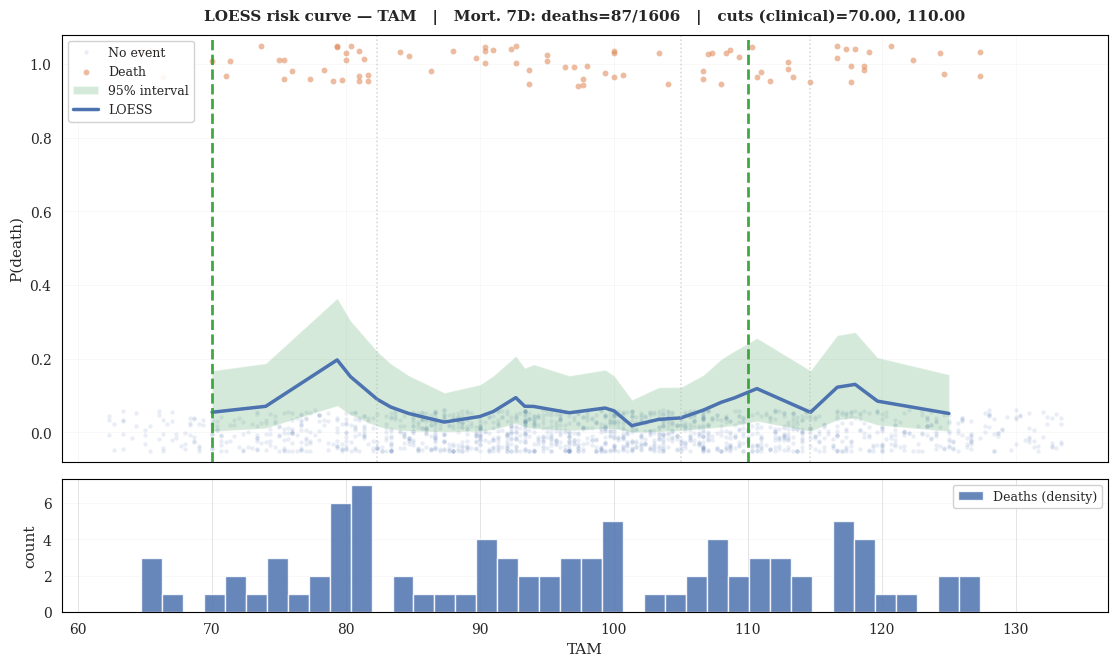

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,82.3333,0.0301,0.0421,129,668,12,34,0.0930,0.0509,0.0098
1,80.3333,0.0235,0.0452,103,694,10,36,0.0971,0.0519,0.0050
2,84.6667,0.0173,0.0249,182,615,14,32,0.0769,0.0520,0.0074
3,105.0000,0.0150,0.0259,545,252,27,19,0.0495,0.0754,0.0029
4,83.3333,0.0144,0.0331,154,643,13,33,0.0844,0.0513,0.0021
5,114.6667,0.0114,0.0322,692,105,37,9,0.0535,0.0857,0.0019
6,79.3333,0.0113,0.0380,76,721,7,39,0.0921,0.0541,0.0016
7,116.6667,0.0113,0.0343,718,79,39,7,0.0543,0.0886,0.0021
8,108.0000,0.0099,0.0299,611,186,31,15,0.0507,0.0806,0.0008
9,103.3333,0.0088,0.0149,515,282,27,19,0.0524,0.0674,0.0030


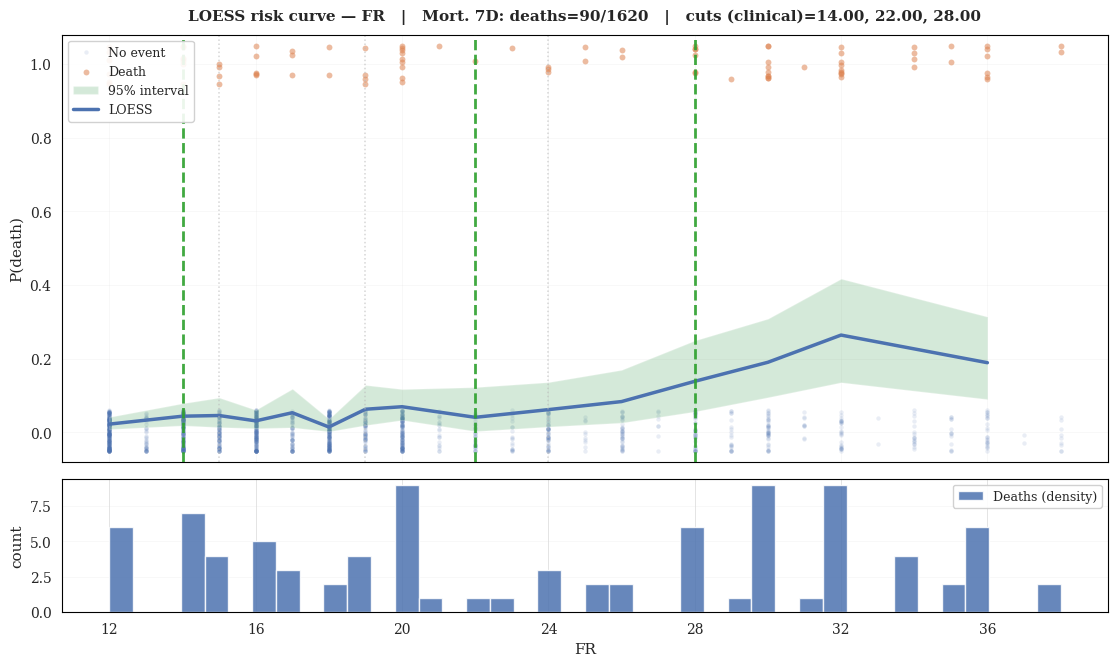

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,24.0,0.0922,0.1242,1278,227,44,36,0.0344,0.1586,0.0025
1,22.0,0.0824,0.1043,1222,283,41,39,0.0336,0.1378,0.0026
2,28.0,0.0610,0.1639,1377,128,54,26,0.0392,0.2031,0.0005
3,26.0,0.0593,0.1478,1331,174,48,32,0.0361,0.1839,0.0005
4,20.0,0.0465,0.0917,1186,319,40,40,0.0337,0.1254,0.0007
5,19.0,0.0359,0.0782,1050,455,31,49,0.0295,0.1077,0.0008
6,18.0,0.0245,0.0732,979,526,27,53,0.0276,0.1008,0.0004
7,17.0,0.0225,0.0474,804,701,25,55,0.0311,0.0785,0.0011
8,15.0,0.0043,0.0366,562,943,17,63,0.0302,0.0668,0.0000



----------------------------------------------------------------------
Active cuts (Mort. 7D) summary:
  Edad        : [58.0, 72.0, 85.0]  (clinical)
  Lactato     : [3.5, 6.0]  (clinical)
  SpO2        : [90.0, 94.0]  (clinical)
  TT          : [35.5, 37.5]  (clinical)
  TAM         : [70, 110]  (clinical)
  FR          : [14, 22, 28]  (clinical)

Cutpoint source summary (Mort. 7D):
  Edad           : clinical
  Lactato        : clinical
  SpO2           : clinical
  TT             : clinical
  TAM            : clinical
  FR             : clinical


In [ ]:
"""
PURPOSE : LOESS cutpoint visualisation + candidate table (readable + diagnostic).

Plot layout:
  - Top panel: raw points (jittered), LOESS curve, 95% band, active cutpoints
  - Bottom panel: event density (histogram of deaths along X)
"""

import matplotlib.ticker as mticker

numeric_vars = [
    v for v in FEATURES
    if v not in BINARY_VARS and v not in GCS_VARS and v not in CATEGORICAL_VARS and v in df.columns
]
print(f"Continuous variables for LOESS ({TARGET_COL}): {numeric_vars}")

cutpoint_results = {}

def _resolve_active_cuts(var: str, loess_cuts: List[float]):
    """Return (active_cutpoints, source) using clinical → LOESS priority."""
    cc = CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {})
    if var in cc:
        return list(cc[var]), "clinical"
    return loess_cuts, "LOESS"

def _plot_one(var: str, res: dict):
    """Render the two-panel LOESS diagnostic plot for one continuous variable."""
    bx = res.get("bin_x", np.array([]))
    sm = res.get("sm", np.array([]))
    lo = res.get("sm_ci_low", np.array([]))
    hi = res.get("sm_ci_hi", np.array([]))
    cuts_loess = res.get("cuts", [])
    x = res.get("x_raw", np.array([]))
    y = res.get("y_raw", np.array([]))

    display_cuts, cut_source = _resolve_active_cuts(var, cuts_loess)

    fig = plt.figure(figsize=PLOT_CFG["figsize"])
    if PLOT_CFG.get("show_density_panel", True):
        gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.06)
        ax = fig.add_subplot(gs[0])
        axd = fig.add_subplot(gs[1], sharex=ax)
    else:
        ax = fig.add_subplot(1, 1, 1)
        axd = None

    # ── Top: raw points (jittered) + LOESS ────────────────────────────────────
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.25)

    if PLOT_CFG.get("show_scatter", True) and len(x) > 0:
        rng = np.random.default_rng(RANDOM_STATE)
        # Optional downsample for speed/overplot control
        if len(x) > PLOT_CFG.get("max_points_scatter", 4000):
            idx = rng.choice(np.arange(len(x)), size=PLOT_CFG["max_points_scatter"], replace=False)
            x_s, y_s = x[idx], y[idx]
        else:
            x_s, y_s = x, y

        jit = rng.uniform(-PLOT_CFG["scatter_jitter"], PLOT_CFG["scatter_jitter"], size=len(y_s))
        yj = np.clip(y_s + jit, -0.05, 1.05)

        mask_ev = y_s == 1
        ax.scatter(x_s[~mask_ev], yj[~mask_ev],
                   s=PLOT_CFG["scatter_size"], alpha=PLOT_CFG["scatter_alpha"],
                   linewidths=0, label="No event")
        ax.scatter(x_s[mask_ev], yj[mask_ev],
                   s=PLOT_CFG["event_size"], alpha=0.55,
                   linewidths=0, label="Death")

    if len(bx) > 0 and len(sm) == len(bx):
        ax.fill_between(bx, lo, hi, alpha=0.25, label="95% interval")
        ax.plot(bx, sm, lw=2.5, label="LOESS")

    # LOESS-only candidates (grey) if overridden by clinical/manual
    if cut_source != "LOESS" and cuts_loess:
        for c in cuts_loess:
            ax.axvline(c, color="#bbbbbb", linestyle=":", lw=1.1, alpha=0.6, zorder=2)

    # Active cuts (green)
    for c in display_cuts:
        ax.axvline(c, color="#2ca02c", linestyle="--", lw=2.0, alpha=0.9, zorder=3)

    ax.set_ylim(-0.08, 1.08)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.set_ylabel("P(death)")

    # Use sane x-ticks (no rainbow spaghetti)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
    ax.tick_params(axis="x", labelbottom=False)

    n_death = int(y.sum()) if len(y) else 0
    n_tot = int(len(y)) if len(y) else 0
    cuts_str = ", ".join([f"{c:.2f}" for c in display_cuts]) if display_cuts else "none"

    ax.set_title(
        f"LOESS risk curve — {var}   |   {TARGET_COL}: deaths={n_death}/{n_tot}   |   cuts ({cut_source})={cuts_str}",
        fontsize=11, fontweight="bold", pad=10
    )

    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

    # ── Bottom: event density ─────────────────────────────────────────────────
    if axd is not None and len(x) > 0:
        axd.set_facecolor("white")
        axd.grid(True, axis="y", alpha=0.25)

        x_ev = x[y == 1]
        axd.hist(x_ev, bins=PLOT_CFG["hist_bins"], alpha=0.85, label="Deaths (density)")
        axd.set_ylabel("count")
        axd.set_xlabel(var)
        axd.xaxis.set_major_locator(mticker.MaxNLocator(8))
        axd.legend(loc="upper right", fontsize=9, framealpha=0.9)

    _save_fig(fig, f"fig_08_loess_{var.replace(".", "")}.png")

    # ── Candidate table (top ~10) ─────────────────────────────────────────────
    cand = res.get("candidates", pd.DataFrame())
    if cand is not None and not cand.empty:
        display(cand.head(10)[
            ["cut_x", "score", "delta_rate", "left_n", "right_n", "left_deaths", "right_deaths", "left_rate", "right_rate", "curvature"]
        ].round(4))


for var in numeric_vars:
    params = LOESS_PARAMS.get(var, {})
    mono = MONO.get(var, None)

    # Use training data only for LOESS cut-point detection to prevent
    # information leakage if fallback cuts are activated downstream.
    res = loess_cutpoints_v2(df_train, var, TARGET_COL, monotonic=mono, **params)
    cutpoint_results[var] = res

    _plot_one(var, res)

print("\n" + "-" * 70)
print(f"Active cuts ({TARGET_COL}) summary:")
cc = CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {})
for var in numeric_vars:
    if var in cc:
        print(f"  {var:12s}: {cc[var]}  (clinical)")
    else:
        print(f"  {var:12s}: {[round(c, 2) for c in cutpoint_results[var].get('cuts', [])]}  (LOESS)")

print(f"\nCutpoint source summary ({TARGET_COL}):")
for var in numeric_vars:
    _, source = _resolve_active_cuts(var, cutpoint_results.get(var, {}).get("cuts", []))
    print(f"  {var:<15}: {source}")


> LOESS-derived candidate cutpoints are estimated on the training split only.
> Clinical cutpoints defined in `CLINICAL_CUTS_PER_OUTCOME` are preferred and
> are not derived from test-set outcomes.

## **9. Variable binning and reference category selection**

### Cut-point source hierarchy (continuous variables)

Cut-points follow a 2-tier priority:

1. **Clinical** — expert-defined thresholds from `CLINICAL_CUTS_PER_OUTCOME[TARGET_COL]`
2. **LOESS** — training-set data-driven fallback from `cutpoint_results`

### Categorical variable handling

- **GCS**: ordered categories 3–15; reference = 15 (clinical convention, overridden).
- **Binary** (O2, Resrv., etc.): two-level encoding; reference = 0 (absence).

GCS is intentionally kept as the full ordinal Glasgow score instead of being grouped.
This preserves the original clinical granularity, follows the supervisor's
recommendation, and lets the coefficient-to-points step decide whether each exact
level contributes additional points. Consequently, some GCS levels may receive the
same number of points, or zero points, if their Ridge β coefficient does not cross
the β-rounding threshold.

*In case these variables are added:*
- **Ritmo** : 21 nominal rhythm classes; reference = lowest-mortality category (n ≥ 30).
- **ST**: 7 ST-segment classes (`NO`, `Elevación`, `Descenso`, `T. picudas`,
  `T. negativas`, `Onda Q`, `Otros`); reference = `NO` or the lowest-mortality
  category if the reference level is too sparse.

### Reference category selection

All reference categories are selected on the **training split only** to avoid leakage.
`REFERENCE_CATEGORY_OVERRIDES` forces GCS reference = "15".
All other variables use `choose_reference()` (lowest mortality, n ≥ 30).

In [ ]:
"""
PURPOSE : Apply variable binning using a priority:
          CLINICAL_CUTS_PER_OUTCOME[TARGET_COL][var]   (clinical knowledge)
OUTPUT  : df with <var>_cat columns; score_cat_cols list; reference categories
          chosen on the master training split without leakage / index errors.
"""

MIN_N_REF = 30
# Full Glasgow Coma Scale levels to preserve as ordered categories
GCS_LEVELS = list(range(3, 16))   # 3, 4, ..., 15

# Fixed reference categories (override data-driven selection)
# Only GCS requires a fixed reference (clinical convention: 15 = normal).
# All other variables use data-driven selection (lowest mortality rate).
REFERENCE_CATEGORY_OVERRIDES: Dict[str, str] = {
    "GCS_cat": "15",
}

# ── Helpers ───────────────────────────────────────────────────────────────────
def _resolve_final_cuts(var: str) -> tuple[list[float], str]:
    """Resolve final cutpoints for one continuous variable."""
    if var in CATEGORICAL_VARS:
        return [], "CATEGORICAL"
    cc = CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {})
    if var in cc:
        return [round(c, 3) for c in cc[var]], "CLINICAL"
    if var in cutpoint_results and cutpoint_results[var].get("cuts"):
        return [round(c, 3) for c in cutpoint_results[var]["cuts"]], "LOESS"
    return [], "NONE"


def cut_bins(series: pd.Series, cutpoints, right: bool, precision: int = 3) -> pd.Categorical:
    """Bin a numeric series using specified cut-points."""
    s = pd.to_numeric(series, errors="coerce")
    cuts_list = [-np.inf] + list(cutpoints) + [np.inf]
    labels = []
    for j in range(len(cuts_list) - 1):
        a, b = cuts_list[j], cuts_list[j + 1]
        la = f"{a:.{precision}g}" if np.isfinite(a) else "-inf"
        lb = f"{b:.{precision}g}" if np.isfinite(b) else "+inf"
        labels.append(f"({la}, {lb}]" if right else f"[{la}, {lb})")
    return pd.cut(
        s, bins=cuts_list, labels=labels,
        include_lowest=True, right=right
    ).astype("category")


def make_gcs_cat(gcs: pd.Series, levels: List[int] = None) -> pd.Categorical:
    """
    Keep the full Glasgow Coma Scale score as ordered categories (3 to 15).

    Values outside the declared range are set to missing.
    Categories are preserved even if some scores are absent in the current data.
    """
    if levels is None:
        levels = list(range(3, 16))

    g = pd.to_numeric(gcs, errors="coerce").round()
    g = pd.Series(g, index=gcs.index)

    valid_levels = set(levels)
    g = g.where(g.isin(valid_levels))

    categories = [str(x) for x in levels]
    out = g.astype("Int64").astype("string")

    return pd.Categorical(out, categories=categories, ordered=True)


def make_binary_cat(series: pd.Series) -> pd.Categorical:
    """
    Robust binary encoder for feature variables.

    Supports both {0,1} and {1,2} conventions, returning categories ["0","1"]
    where "1" = presence / positive / yes and "0" = absence / no.
    """
    s = pd.to_numeric(series, errors="coerce")

    if set(s.dropna().unique()).issubset({0, 1}):
        out = s.map({0: "0", 1: "1"})
    elif set(s.dropna().unique()).issubset({1, 2}):
        out = s.map({2: "0", 1: "1"})
    else:
        # Fallback: largest observed code = no / majority, smallest = yes
        vc = s.value_counts(dropna=True)
        if len(vc) >= 2:
            no_val = vc.idxmax()
            yes_val = [v for v in vc.index if v != no_val][0]
            out = s.map({no_val: "0", yes_val: "1"})
        else:
            out = pd.Series(pd.NA, index=s.index, dtype="object")

    return pd.Categorical(out, categories=["0", "1"], ordered=True)


def make_categorical_cat(series: pd.Series, mapping: Dict[int, str],
    group_order: List[str]) -> pd.Categorical:
    """
    Map integer-coded categorical variable to labels, preserving all declared categories.

    Codes not present in *mapping* are assigned to 'Otros'.
    All categories in *group_order* are kept, even if absent in the current data.
    """
    s = pd.to_numeric(series, errors="coerce")
    mapped = s.map(mapping).fillna("Otros")

    # Ensure 'Otros' exists in the declared order if it may be used as fallback
    categories = list(group_order)
    if "Otros" in mapped.values and "Otros" not in categories:
        categories.append("Otros")

    return pd.Categorical(mapped, categories=categories, ordered=True)


def risk_table(df_in: pd.DataFrame, cat_col: str, target: str) -> pd.DataFrame:
    """Mortality table per category level using robust 0/1 event encoding."""
    tmp = df_in[[cat_col, target]].copy()
    tmp[target] = to_event_binary(tmp[target])
    tmp = tmp.dropna(subset=[cat_col, target])

    if tmp.empty:
        return pd.DataFrame(columns=["n", "events", "rate"])

    # Ensure column is categorical before groupby; recover categories
    # from the master df if the slice lost its CategoricalDtype.
    col_series = tmp[cat_col]
    if not isinstance(col_series.dtype, pd.CategoricalDtype):
        master_cats = list(df[f"{cat_col}"].cat.categories) if isinstance(
            df[f"{cat_col}"].dtype, pd.CategoricalDtype) else None
        if master_cats:
            col_series = col_series.astype(
                pd.CategoricalDtype(categories=master_cats, ordered=True))
        else:
            col_series = col_series.astype("category")
        tmp[cat_col] = col_series

    tab = tmp.groupby(cat_col, observed=True).agg(
        n=(target, "count"),
        events=(target, "sum"),
        rate=(target, "mean"),
    )
    return tab.sort_index()


def choose_reference(tab: pd.DataFrame, min_n: int = 30):
    """Select the level with lowest mortality rate, prioritising n >= min_n."""
    if tab.empty:
        return None
    eligible = tab[tab["n"] >= min_n]
    if eligible.empty:
        eligible = tab
    return eligible.sort_values(["rate", "n"], ascending=[True, False]).index[0]


def reorder_ref_first(series: pd.Series, ref):
    """Place reference category first in a categorical series."""
    if ref is None or not isinstance(series.dtype, pd.CategoricalDtype):
        return series
    cats = list(series.cat.categories)
    if ref in cats:
        cats.remove(ref)
        cats.insert(0, ref)
        return series.cat.reorder_categories(cats, ordered=True)
    return series


# ── Resolve final cutpoints ───────────────────────────────────────────────────
CUTS_RIGHT_TRUE = {}
CUTS_RIGHT_FALSE = {}
CUT_SOURCE_MAP = {}

print("Resolved cut-points:")
for var in FEATURES:
    if var in BINARY_VARS or var in GCS_VARS or var in CATEGORICAL_VARS or var not in df.columns:
        continue

    cuts_resolved, src_label = _resolve_final_cuts(var)
    if not cuts_resolved:
        print(f"  WARNING: no cuts for {var} — variable skipped")
        continue

    CUT_SOURCE_MAP[var] = src_label
    if var in RIGHT_FALSE_VARS:
        CUTS_RIGHT_FALSE[var] = cuts_resolved
        right_flag = False
    else:
        CUTS_RIGHT_TRUE[var] = cuts_resolved
        right_flag = True
        if var not in RIGHT_TRUE_VARS:
            print(f"  NOTE: {var} not in RIGHT_TRUE/FALSE_VARS → defaulting to right=True")

    print(f"  {var:12s}: {cuts_resolved}  (source={src_label}, right={right_flag})")


# ── Apply binning to full df, then realign train/test by index ───────────────
for col, cuts in CUTS_RIGHT_TRUE.items():
    if col in df.columns and col in FEATURES:
        df[f"{col}_cat"] = cut_bins(df[col], cuts, right=True)

for col, cuts in CUTS_RIGHT_FALSE.items():
    if col in df.columns and col in FEATURES:
        df[f"{col}_cat"] = cut_bins(df[col], cuts, right=False)

for col in FEATURES:
    if col in GCS_VARS and col in df.columns:
        df[f"{col}_cat"] = make_gcs_cat(df[col], GCS_LEVELS)
    elif col in BINARY_VARS and col in df.columns:
        df[f"{col}_cat"] = make_binary_cat(df[col])
    elif col in CATEGORICAL_VARS and col in df.columns:
        _map = CATEGORICAL_MAPS.get(col, {})
        _ord = CATEGORICAL_GROUP_ORDER.get(col, sorted(set(_map.values())))
        df[f"{col}_cat"] = make_categorical_cat(df[col], _map, _ord)

score_cat_cols = [f"{v}_cat" for v in FEATURES if f"{v}_cat" in df.columns]
print(f"\nActive scoring variables ({TARGET_COL}): {score_cat_cols}")

missing_score_cols = [c for c in [*score_cat_cols, TARGET_COL] if c not in df.columns]
if missing_score_cols:
    raise ValueError(f"Missing scored columns after binning: {missing_score_cols}")

# Rebuild split views from updated df (2 split indices + new _cat columns).
# Reference category selection uses training data only to avoid leakage.
df_train_ref = df.loc[df_train.index, score_cat_cols + [TARGET_COL]].copy()

print(f"\nReference categories (train split, min_n={MIN_N_REF}):")
for col in score_cat_cols:
    tab = risk_table(df_train_ref, col, TARGET_COL)

    ref = REFERENCE_CATEGORY_OVERRIDES.get(col)
    if ref is None:
        ref = choose_reference(tab, MIN_N_REF)

    # Apply reference-first ordering to the master df (propagates to all views)
    df[col] = reorder_ref_first(df[col], ref)

    display(Markdown(f"**{col}** — reference: `{ref}`"))
    display(tab.round(4))

del df_train_ref  # transient — not needed downstream

# Refresh master split views with updated categories for 10 onward
df_train = df.loc[df_train.index].copy()
df_test  = df.loc[df_test.index].copy()

# ── Applied cut-points summary ────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"APPLIED CUT-POINTS SUMMARY ({TARGET_COL})")
print("=" * 70)
_cc = CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {})
for var in FEATURES:
    if var in GCS_VARS:
        print(f"  {var:12s}: {GCS_LEVELS} (ordinal — full GCS scores, ref=15)")
    elif var in BINARY_VARS:
        print(f"  {var:12s}: binary (no binning)")
    elif var in CATEGORICAL_VARS:
        _n_groups = df[f"{var}_cat"].nunique() if f"{var}_cat" in df.columns else 0
        print(f"  {var:12s}: categorical mapping → {_n_groups} groups")
    else:
        cuts = CUTS_RIGHT_TRUE.get(var, CUTS_RIGHT_FALSE.get(var, []))
        src = CUT_SOURCE_MAP.get(var, "NONE")
        right = False if var in RIGHT_FALSE_VARS else True
        print(f"  {var:12s}: {cuts}  (source={src}, right={right})")
print("=" * 70)

Resolved cut-points:
  Edad        : [58.0, 72.0, 85.0]  (source=CLINICAL, right=True)
  Lactato     : [3.5, 6.0]  (source=CLINICAL, right=True)
  SpO2        : [90.0, 94.0]  (source=CLINICAL, right=False)
  TT          : [35.5, 37.5]  (source=CLINICAL, right=False)
  TAM         : [70, 110]  (source=CLINICAL, right=False)
  FR          : [14, 22, 28]  (source=CLINICAL, right=True)

Active scoring variables (Mort. 7D): ['Edad_cat', 'GCS_cat', 'Lactato_cat', 'SpO2_cat', 'TT_cat', 'TAM_cat', 'FR_cat', 'Resrv._cat', 'VAD_cat']

Reference categories (train split, min_n=30):


**Edad_cat** — reference: `(-inf, 58]`

,n,events,rate
Edad_cat,,,
"(-inf, 58]",569,14,0.0246
"(58, 72]",441,27,0.0612
"(72, 85]",546,46,0.0842
"(85, +inf]",225,42,0.1867


**GCS_cat** — reference: `15`

,n,events,rate
GCS_cat,,,
3,51,30,0.5882
4,9,2,0.2222
5,5,3,0.6000
6,12,2,0.1667
7,9,4,0.4444
8,19,6,0.3158
9,22,5,0.2273
10,33,8,0.2424
11,45,6,0.1333


...

**Resrv._cat** — reference: `0`

,n,events,rate
Resrv._cat,,,
0,1641,81,0.0494
1,140,48,0.3429


**VAD_cat** — reference: `0`

,n,events,rate
VAD_cat,,,
0,1772,121,0.0683
1,9,8,0.8889



APPLIED CUT-POINTS SUMMARY (Mort. 7D)
  Edad        : [58.0, 72.0, 85.0]  (source=CLINICAL, right=True)
  GCS         : [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] (ordinal — full GCS scores, ref=15)
  Lactato     : [3.5, 6.0]  (source=CLINICAL, right=True)
  SpO2        : [90.0, 94.0]  (source=CLINICAL, right=False)
  TT          : [35.5, 37.5]  (source=CLINICAL, right=False)
  TAM         : [70, 110]  (source=CLINICAL, right=False)
  FR          : [14, 22, 28]  (source=CLINICAL, right=True)
  Resrv.      : binary (no binning)
  VAD         : binary (no binning)


## **10. Risk scoring system — β-rounding method**

Following **Zhang et al. (2017)** *Development of scoring system for risk stratification in clinical medicine*, each categorical variable level is
assigned integer risk points by direct rounding of its logistic regression coefficient:

$$\\{Points}_i = {round}(β_i)$$

A modified rounding threshold (`ROUND_THRESHOLD = 0.45`) is used so that any |β| ≥ 0.45
rounds to 1 rather than 0, preserving discriminative information from smaller coefficients
while remaining consistent with the Zhang et al. integer-scale principle.

### Pipeline

| Step | Detail |
|------|--------|
| 1. Data preparation | Categorical columns from 9.; target encoded as 0/1 |
| 2. Train/test split | Reuses master split from 2. (fixed 75/25, non-stratified) |
| 3. String coercion | Categories cast to string to avoid sklearn `TypeError` with mixed dtypes |
| 4. One-Hot Encoding | `drop="first"` — reference category absorbed into intercept (β = 0) |
| 5. Ridge logistic regression | L2 penalty; C tuned by 10-fold CV optimising Brier score |
| 6. β extraction | Coefficients mapped back to (variable, level) pairs |
| 7. Point assignment | `round_beta(β, threshold=0.45)` applied per level |
| 8. Score computation | Patient score = Σ points across all variables |

### Regularisation choice

Ridge (L2) logistic regression is retained for two reasons:
1. **Stability**: the small dataset (N ≈ 2 376, rare positive class) yields unstable MLE
   estimates; L2 shrinkage reduces variance without the sparsity of Lasso.
2. **β-rounding compatibility**: coefficients must be rounded to integers. L2 shrinkage biases estimates towards zero proportionally, preserving the *relative* ordering of coefficients across levels, the property needed for clinical interpretability.


> GCS is not grouped before modelling. Exact levels 3–15 are retained because this
was recommended by the supervisor and preserves the original clinical scale. After
Ridge shrinkage and β-rounding, not every GCS level necessarily receives a distinct
point value: levels with small coefficients may receive 0 points, and neighbouring
levels may collapse to the same integer value. This is expected behaviour of an
integer score derived from coefficients, not a manual recoding error.

### Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| `ROUND_THRESHOLD` | `0.45` | |β| ≥ threshold rounds to ±1 instead of 0 |
| `CLIP_NEGATIVE` | `False` | If True, negative points clipped to 0 (non-negative scale) |
| `C_GRID` | `[0.003, …, 100]` | Ridge regularisation candidates (CV selects best) |

### Functions

- `force_string_categories(df_in, cat_cols, missing_token)` — cast categories to string preserving order
- `make_ohe(cats)` — build a `ColumnTransformer`-compatible `OneHotEncoder`
- `compute_risk_score(df_in, score_map, cat_cols)` — apply `SCORE_MAP` to a dataframe


### **10a. Category preparation and split alignment**

The scored categorical columns (`score_cat_cols`) and the target are extracted from
the master train/test split defined in 2.

**`_prep_split(df_in)`:**
1. Select scored categorical columns + `TARGET_COL`.
2. Drop rows where `TARGET_COL` is missing, if any remain after loading and split alignment.
3. Ensure all categorical columns have `pd.CategoricalDtype` — required for consistent OHE.

**`force_string_categories(df_in, cat_cols, missing_token)`:**
- Casts all category levels to `str` to prevent scikit-learn `TypeError` with mixed dtypes.
- Appends `__MISSING__` to the category list if any missing value is present.

> **Leakage guard:** reference categories are selected on `df_train` only on  **section 9.**.
> `X_test_s` uses the same category order as `X_train_s`.


In [ ]:
MISSING_TOKEN = "__MISSING__"

# ── Subset to scored categorical columns + target ─────────────────────────────
needed = score_cat_cols + [TARGET_COL]
missing_cols = [c for c in needed if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# ── Align categorical columns with the master train/test split from 2 ────────
# df_train and df_test are index-aligned subsets of df (created in 2).
# We select only the rows where TARGET_COL is non-missing (should be all after 2 filter).

def _prep_split(df_in: pd.DataFrame) -> tuple:
    """Return (X_cat, y) from a split dataframe."""
    tmp = df_in[needed].copy()
    y   = pd.to_numeric(tmp[TARGET_COL], errors="coerce")
    msk = y.notna()
    tmp, y = tmp.loc[msk], y.loc[msk].astype(int)
    for c in score_cat_cols:
        if not isinstance(tmp[c].dtype, pd.CategoricalDtype):
            tmp[c] = tmp[c].astype("category")
    return tmp[score_cat_cols].copy(), y

X_train, y_train = _prep_split(df_train)
X_test,  y_test  = _prep_split(df_test)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Prevalence — Train: {y_train.mean():.3%} | Test: {y_test.mean():.3%}")


# ── String coercion ───────────────────────────────────────────────────────────
def force_string_categories(
    df_in: pd.DataFrame, cat_cols: List[str],
    missing_token: str = "__MISSING__",
) -> pd.DataFrame:
    """Cast categorical columns to string while preserving reference-first order."""
    df2 = df_in.copy()
    for c in cat_cols:
        if not isinstance(df2[c].dtype, pd.CategoricalDtype):
            df2[c] = df2[c].astype("category")
        cats_str = [str(x) for x in df2[c].cat.categories]
        df2[c] = df2[c].apply(lambda v: missing_token if pd.isna(v) else str(v))
        if (df2[c] == missing_token).any() and missing_token not in cats_str:
            cats_str = cats_str + [missing_token]
        df2[c] = pd.Categorical(df2[c], categories=cats_str, ordered=True)
    return df2


X_train_s = force_string_categories(X_train, score_cat_cols, MISSING_TOKEN)
X_test_s  = force_string_categories(X_test,  score_cat_cols, MISSING_TOKEN)

categories = [list(X_train_s[c].cat.categories) for c in score_cat_cols]

print("\nCategory counts per variable:")
for col, cats in zip(score_cat_cols, categories):
    print(f"  {col:<15}: {len(cats)} levels")


Train: 1781 | Test: 595
Prevalence — Train: 7.243% | Test: 7.395%

Category counts per variable:
  Edad_cat       : 4 levels
  GCS_cat        : 13 levels
  Lactato_cat    : 3 levels
  SpO2_cat       : 3 levels
  TT_cat         : 3 levels
  TAM_cat        : 3 levels
  FR_cat         : 4 levels
  Resrv._cat     : 2 levels
  VAD_cat        : 2 levels


### **10b. Ridge logistic regression with cross-validation (Brier-score optimised)**

The coefficients for the integer scoring system are obtained from a logistic regression model fitted on the training set. In this work, the classical (unpenalised) logistic regression is replaced by **Ridge (L2)-penalised** logistic regression to stabilise coefficient estimates before β-rounding
particularly for low-prevalence outcomes where the events-per-variable ratio is low.

Ridge is preferred over Lasso (L1) because L1 may shrink individual category-level coefficients exactly to zero, removing variables from the clinical score and breaking interpretability. Ridge shrinks continuously without eliminating categories.

The regularisation parameter `C` (inverse of regularisation strength) is tuned
via **10-fold stratified cross-validation within the training set only**.
The test partition is never involved in hyperparameter selection.

> **Why Brier score for cross-validation?**  The Brier score is a strictly
> proper scoring rule that penalises calibration and discrimination jointly.
> Because the model coefficients are subsequently converted into integer
> points (**section 10c**), stable probabilistic behaviour is prioritised over
> ranking performance alone.  AUC measures ranking only; Brier score rewards
> well-calibrated probabilities, which translate more faithfully to integer
> points via the β-rounding step.

| Decision | Detail |
|----------|--------|
| Penalty | L2 (Ridge) — continuous shrinkage, no variable elimination |
| Scoring | `neg_brier_score` — strictly proper, penalises calibration + discrimination jointly |
| `C_GRID` | 0.003 → 100 (10 values) — wide range for low-prevalence outcomes |
| `CW_GRID` | `["balanced", None]` when prevalence < 8 %; `[None]` otherwise |
| CV folds | 10-fold stratified |

After `GridSearchCV` selects the best `C`, it refits the full pipeline on all of `X_train`. The β coefficients extracted in **section 10c** come from this refitted model, not from any individual CV fold.

> **Note:** Ridge does not replace the clinical score.  It provides stable β
 coefficients that are rounded to integer points.  The integer score is the artefact delivered for clinical use.


In [ ]:
def make_ohe(cats: list) -> OneHotEncoder:
    """Create a OneHotEncoder compatible across scikit-learn >= 1.0.

    Parameters
    ----------
    cats : list of list
        Explicit category lists for each categorical column, in column order.
        Providing explicit categories prevents the encoder from inferring
        unseen levels at transform time (critical for train/test consistency).

    Returns
    -------
    OneHotEncoder
        Configured with ``drop="first"``, ``handle_unknown="ignore"``
        and dense output.  The ``sparse_output`` keyword changed to
        ``sparse`` in sklearn < 1.2; this helper tries both.
    """
    try:
        return OneHotEncoder(categories=cats, drop="first",
                             handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(categories=cats, drop="first",
                             handle_unknown="ignore", sparse=False)


preprocessor = ColumnTransformer(
    transformers=[("cat", make_ohe(categories), score_cat_cols)],
    remainder="drop")

# ── Ridge logistic regression with CV (Brier-score optimised) ────────────────
# KEY DESIGN DECISIONS:
#
# 1. Scoring = "neg_brier_score" (instead of neg_log_loss).
#    The Brier score is a strictly proper scoring rule that penalises both
#    discrimination and calibration simultaneously.  Optimising it during CV
#    encourages the model to learn well-calibrated β estimates — a prerequisite
#    for the integer β-rounding step (10c) to preserve clinical meaning.
#
# 2. Extended C_GRID (0.003 → 100): heavier regularisation options ensure
#    that when coefficients are small (e.g., TT, SpO2), stronger L2 shrinkage
#    is available to stabilise estimates before rounding.
#
# 3. class_weight tuning: activated for highly imbalanced outcomes (prevalence
#    < 8 %, i.e., Mort. 2D ≈ 2 %).  "balanced" amplifies gradient signal from
#    positive cases, yielding better β estimates for the minority class.
#    For Mort. 7D / 30D (higher prevalence) only None is tried.

C_GRID = [0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

PREVALENCE = float(y_train.mean())
CW_GRID    = ["balanced", None] if PREVALENCE < 0.08 else [None]

logit = LogisticRegression(penalty="l2", solver="lbfgs",
                           max_iter=5000, random_state=RANDOM_STATE)
pipe_base = Pipeline([("pre", preprocessor), ("model", logit)])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(
    estimator=pipe_base,
    param_grid={"model__C": C_GRID, "model__class_weight": CW_GRID},
    scoring="neg_brier_score",   # optimise calibration + discrimination jointly
    cv=cv, n_jobs=-1, refit=True,
)
gs.fit(X_train_s, y_train)

pipe           = gs.best_estimator_
best_C         = gs.best_params_["model__C"]
best_cw        = gs.best_params_["model__class_weight"]
p_train        = pipe.predict_proba(X_train_s)[:, 1]
p_test         = pipe.predict_proba(X_test_s)[:, 1]

print(f"Best C   (CV Brier):  {best_C}")
print(f"Best class_weight:    {best_cw}")
print(f"Training prevalence:  {PREVALENCE:.3%}")
print(f"AUC-ROC  (test):      {roc_auc_score(y_test, p_test):.3f}")
from sklearn.metrics import brier_score_loss
print(f"Brier    (test):      {brier_score_loss(y_test, p_test):.4f}")

Best C   (CV Brier):  1
Best class_weight:    None
Training prevalence:  7.243%
AUC-ROC  (test):      0.864
Brier    (test):      0.0526


### **10b. Cross-validated performance on the training set**

The best pipeline (selected in **10b**) is evaluated via 10-fold stratified
`cross_validate` on `X_train_s` / `y_train` exclusively — **the test set is
never touched**.

| Output | Interpretation |
|--------|----------------|
| AUC-ROC mean ± SD | Discriminative ability across folds; SD reflects model stability |
| Brier mean ± SD | Calibration + discrimination jointly; lower is better |
| AP mean ± SD | Average precision; informative under class imbalance |

> **On the difference between CV AUC and test AUC:** the Cross-Validation AUC is computed on validation folds of the *training set*, each containing 10 % of training rows. The test AUC (**section 11.**) is computed on a fixed held-out set of different composition. It is normal and expected for these two values to differ, they measure performance on different data subsets. A CV AUC *lower* than test AUC is common when the test set happens to be slightly easier to discriminate, or when each CV fold has fewer positive cases than the full training set.  What matters is that the CV Standard Deviation is small, confirming the model is stable and the β estimates reliable.

> **Note:** `cross_validate` uses the pipeline already fitted by `GridSearchCV` with the best hyperparameters.  It does **not** perform another hyperparameter search, it only re-evaluates the fixed model across different data partitions.


In [ ]:
# ── 10b-cv  Cross-validated performance on the training set ─────────────────
"""
PURPOSE : Evaluate the best pipeline (from GridSearchCV) via 10-fold stratified
          cross_validate on the training set only.

CONCEPT : cross_validate refits the pipeline on each of the 10 training folds
          and scores on the corresponding validation fold.  Reporting mean ± SD
          provides an internal estimate of model stability without leaking
          information from the held-out test set.

          10 folds are used for consistency with the number of synthetic replicas
          generated in NB6 (CTAB-GAN+) and NB7 (ARF/FORDE).

INPUTS  : pipe      -- best pipeline from 10b (already fitted on full X_train_s)
          X_train_s -- stringified categorical training features
          y_train   -- binary outcome labels (training set)
OUTPUT  : cv_perf   -- DataFrame with mean ± SD for AUC-ROC, Brier, AP
"""

from sklearn.model_selection import cross_validate

cv_eval = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    pipe,                          # best_estimator_ from GridSearchCV
    X_train_s, y_train,
    cv=cv_eval,
    scoring={
        'auc':    'roc_auc',
        'brier':  'neg_brier_score',
        'ap':     'average_precision',
    },
    return_train_score=False,
    n_jobs=-1,
)

cv_perf = pd.DataFrame({
    'Metric':  ['AUC-ROC', 'Brier', 'Average Precision'],
    'CV Mean': [
         cv_results['test_auc'].mean(),
        -cv_results['test_brier'].mean(),   # neg_brier_score → positive Brier
         cv_results['test_ap'].mean(),
    ],
    'CV SD': [
        cv_results['test_auc'].std(),
        cv_results['test_brier'].std(),
        cv_results['test_ap'].std(),
    ],
})

print(f"10-fold CV performance on training set  ({TARGET_COL})")
print(f"{'Metric':<22} {'Mean':>8} {'SD':>8}")
print('─' * 42)
for _, row in cv_perf.iterrows():
    print(f"{row['Metric']:<22} {row['CV Mean']:>8.4f} {row['CV SD']:>8.4f}")
print()
print("Note: test-set performance is reported in 11.")


10-fold CV performance on training set  (Mort. 7D)
Metric                     Mean       SD
──────────────────────────────────────────
AUC-ROC                  0.8919   0.0425
Brier                    0.0472   0.0062
Average Precision        0.5622   0.1059

Note: test-set performance is reported in 11.


### **10c. β coefficient extraction and integer point assignment**

Coefficients (β) are extracted from the **Ridge logistic regression refitted on the full
training set** by `GridSearchCV` (10b) — not from any individual CV fold.  The model lives
at `pipe.named_steps['model']`, accessed after OHE feature names are recovered from
`pipe.named_steps['pre']`.

Each β represents the change in log-odds of the outcome associated with a patient belonging
to that variable level relative to the reference category (absorbed into the intercept,
β = 0 by convention).  Coefficients are then converted to integer points:

$$\text{Points}_i = \text{round}_{\,\theta}(\beta_i), \quad \theta = 0.45$$

The modified threshold $\theta = 0.45$  ensures that any $|\beta| \geq 0.45$
rounds to ±1 rather than 0, preventing clinically relevant but numerically small coefficients
from being silently discarded.

The `CLIP_NEGATIVE` flag (default `False`) controls whether negative point values are allowed.
Preserving negative points maintains the full log-odds interpretation; clipping to zero
produces a strictly additive non-negative scale at the cost of discarding protective effects.

For GCS, the point allocation should be interpreted as part of the complete
multivariable score rather than as isolated clinical effects for each individual
Glasgow level. Exact GCS levels were retained by design; if a level receives 0
points, it means its penalised β coefficient did not exceed the rounding threshold
relative to the reference category.


In [ ]:
# ── 10c  β extraction and integer point assignment ───────────────────────────
"""
PURPOSE : Extract Ridge logistic regression coefficients from the fitted pipeline
          and convert them to integer risk points via β-rounding (Zhang et al. 2017).

SOURCE OF COEFFICIENTS:
    pipe = GridSearchCV.best_estimator_, refitted on the full X_train after CV.
    Coefficients come from pipe.named_steps['model'].coef_ — the Ridge LR trained
    on all training rows with the CV-selected C.  They are NOT fold-level estimates.

OHE FEATURE NAME RECOVERY:
    OHE encodes each (variable, level) pair as a column named "<variable>_<level>".
    parse_ohe_feature() reverses this mapping so coefficients are labelled by their
    original (variable, level) identity rather than an opaque OHE index.
    Reference categories (dropped by drop='first') are re-inserted with β = 0.

β-ROUNDING:
    round_beta(β, threshold=0.45):
        sign(β) × floor(|β| + (1 − threshold))
    With threshold=0.45: values in [0.45, 1.45) → 1, [1.45, 2.45) → 2, etc.
    Standard rounding uses threshold=0.5; lowering it to 0.45 captures coefficients
    that are clinically meaningful but slightly below the 0.5 boundary.

CLIP_NEGATIVE:
    If True, non-reference levels with negative points are clipped to 0.
    Must match NB9 8b for a valid TSTR comparison.

OUTPUTS:
    SCORE_MAP  : Dict[(variable, level) → int points] — used in 10d and 11
    MAX_SCORE  : int — theoretical maximum (sum of per-variable max points)
    points_df  : DataFrame — full β and points table for inspection
"""

CLIP_NEGATIVE   = True
ROUND_THRESHOLD = 0.45


def parse_ohe_feature(feat: str, cols: List[str]) -> Tuple[str, str]:
    """Recover (variable, level) from an OHE feature name.

    OHE names follow the pattern '<variable>_<level>', optionally prefixed
    by the ColumnTransformer step name ('cat__<variable>_<level>').
    Longest-match on col names prevents mis-splitting when a variable name
    contains an underscore.
    """
    if "__" in feat:
        feat = feat.split("__", 1)[-1]           # strip ColumnTransformer prefix
    for col in sorted(cols, key=len, reverse=True):   # longest match first
        if feat.startswith(col + "_"):
            return col, feat[len(col) + 1:]
    return None, feat


# ── Extract OHE feature names and Ridge β coefficients ───────────────────────
# pipe.named_steps['pre'] is the ColumnTransformer; 'cat' is the OHE transformer.
# coef_.ravel() returns one β per OHE column, in the same order as get_feature_names_out().
ohe        = pipe.named_steps["pre"].named_transformers_["cat"]
feat_names = ohe.get_feature_names_out(score_cat_cols)
betas      = pipe.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({"feature": feat_names, "beta": betas})
coef_df[["variable", "level"]] = coef_df["feature"].apply(
    lambda s: pd.Series(parse_ohe_feature(s, score_cat_cols)))

# ── Re-insert reference levels (β = 0, dropped by OHE drop='first') ──────────
# The reference category is the first in each variable's category list (9).
# It is not present in coef_df because OHE dropped it; we add it explicitly
# so the scoring table is complete and SCORE_MAP covers all levels.
ref_levels = {c: list(X_train_s[c].cat.categories)[0] for c in score_cat_cols}
rows = []
for var in score_cat_cols:
    rows.append({"variable": var, "level": ref_levels[var],
                 "beta": 0.0, "is_reference": True})
    sub = coef_df[coef_df["variable"] == var][["level", "beta"]]
    for r in sub.itertuples(index=False):
        rows.append({"variable": var, "level": r.level,
                     "beta": float(r.beta), "is_reference": False})

points_df = pd.DataFrame(rows)


# ── β-rounding: convert each coefficient to an integer point value ────────────
def round_beta(b: float, threshold: float = ROUND_THRESHOLD) -> int:
    """Round β to integer using a modified threshold (Zhang et al. 2017).

    Any |β| >= (1 - threshold) rounds away from zero.
    With threshold=0.45: the rounding boundary is at 0.45 rather than 0.50,
    so coefficients in [0.45, 1.45) → 1 instead of collapsing to 0.
    """
    sign = 1 if b >= 0 else -1
    return sign * int(np.floor(abs(b) + (1 - threshold)))


points_df["points"] = points_df["beta"].apply(round_beta).astype(int)

# ── Optional: clip negative points to zero ────────────────────────────────────
# Reference levels are excluded — their points are always 0 by definition.
if CLIP_NEGATIVE:
    mask_nonref = ~points_df["is_reference"]
    points_df.loc[mask_nonref, "points"] = (
        points_df.loc[mask_nonref, "points"].clip(lower=0))

# ── Build SCORE_MAP and compute theoretical maximum ───────────────────────────
SCORE_MAP = {(row["variable"], row["level"]): int(row["points"])
             for _, row in points_df.iterrows()}
MAX_SCORE = sum(points_df.groupby("variable")["points"].max())

display(Markdown(f"### Scoring table ({TARGET_COL})"))
display(points_df.sort_values(["variable", "points"]))
print(f"\nMaximum theoretical score: {MAX_SCORE} points")

### Scoring table (Mort. 7D)

,variable,level,beta,is_reference,points
0,Edad_cat,"(-inf, 58]",0.000000,True,0
1,Edad_cat,"(58, 72]",0.723875,False,1
2,Edad_cat,"(72, 85]",0.935991,False,1
3,Edad_cat,"(85, +inf]",1.637231,False,2
29,FR_cat,"(14, 22]",0.000000,True,0
30,FR_cat,"(-inf, 14]",0.034909,False,0
31,FR_cat,"(22, 28]",0.243581,False,0
32,FR_cat,"(28, +inf]",0.549393,False,1
4,GCS_cat,15,0.000000,True,0
8,GCS_cat,6,0.288400,False,0



Maximum theoretical score: 11 points


### **10d. Risk score computation**

Each patient's total score is the sum of integer points across all n variables:

$$\text{Score}_i = \sum_{j=1}^{n} \text{points}(\text{variable}_j, \text{level}_j(\text{patient}_i))$$

In [ ]:
def compute_risk_score(
    df_in: pd.DataFrame, score_map: Dict[Tuple[str, str], int],
    cat_cols: List[str], missing_token: str = "__MISSING__",
) -> pd.Series:
    """Compute the total integer risk score per patient.

    Each patient's score is the sum of integer points assigned to their
    level of every categorical predictor, following Zhang et al. (2017).

    Parameters
    ----------
    df_in         : pd.DataFrame
        Data with categorical predictor columns (pre-binned, string-category dtype).
    score_map     : Dict[Tuple[str, str], int]
        Mapping (variable, level) → integer points (from 10c).
    cat_cols      : List[str]
        Names of categorical columns to sum over.
    missing_token : str, default "__MISSING__"
        Placeholder for missing values; mapped to 0 by default.

    Returns
    -------
    pd.Series of int — total risk score per patient (index matches df_in).
    """
    scores = np.zeros(len(df_in), dtype=int)
    for col in cat_cols:
        col_pts = df_in[col].apply(
            lambda v: score_map.get(
                (col, missing_token if pd.isna(v) else str(v)), 0)
        ).astype(int).values
        scores += col_pts
    return pd.Series(scores, index=df_in.index, name="risk_score")


train_scores = compute_risk_score(X_train_s, SCORE_MAP, score_cat_cols, MISSING_TOKEN)
test_scores  = compute_risk_score(X_test_s,  SCORE_MAP, score_cat_cols, MISSING_TOKEN)

print("Score distribution — Train:")
print(train_scores.describe().round(2))
print("\nScore distribution — Test:")
print(test_scores.describe().round(2))

Score distribution — Train:
count    1781.00
mean        2.07
std         1.63
min         0.00
25%         1.00
50%         2.00
75%         3.00
max         9.00
Name: risk_score, dtype: float64

Score distribution — Test:
count    595.00
mean       2.07
std        1.58
min        0.00
25%        1.00
50%        2.00
75%        3.00
max        8.00
Name: risk_score, dtype: float64


### **10e. β-rounding threshold sensitivity analysis**

The β-rounding formula `int(np.floor(abs(b) + (1 - threshold)))` is equivalent
to standard nearest-integer rounding when `threshold = 0.50`. This notebook uses
`ROUND_THRESHOLD = 0.45` to retain small but clinically relevant positive
coefficients: |β| ≥ 0.45 rounds to 1 rather than 0.  A coefficient of 0.45
corresponds to an odds ratio of approximately 1.57, a meaningful effect size for
a bedside risk scale.

The comparison below is **descriptive only**.  The threshold is justified by
clinical interpretation of the coefficient scale and by training-set behaviour.
It is **not** selected from test-set results; test AUC is shown only as a final
robustness check after the scoring rule has been fixed.


In [ ]:
# Sensitivity analysis: compare ROUND_THRESHOLD = 0.45 vs 0.50
"""
PURPOSE : Quantify how much the integer score changes when using the chosen
          rounding threshold (0.45) instead of standard rounding (0.50).

DESIGN  :
  - The threshold is not selected from the test set.
  - Training-set AUC is used as the primary internal comparison.
  - Test-set AUC is reported only as a descriptive robustness check after the
    scoring rule has already been fixed.

INPUT   : points_df with β coefficients extracted in 10.4.
OUTPUT  : Side-by-side train/test AUC and maximum score under both thresholds.
"""

def build_score_map_from_points(
    points_df_in: pd.DataFrame,
    threshold: float,
    clip_negative: bool,
) -> Dict[Tuple[str, str], int]:
    """Build a score map from β coefficients using a chosen rounding threshold."""
    df_tmp = points_df_in.copy()
    df_tmp["points"] = df_tmp["beta"].apply(
        lambda b: (1 if b >= 0 else -1) * int(np.floor(abs(b) + (1 - threshold)))
    ).astype(int)

    if clip_negative:
        mask_nonref = ~df_tmp["is_reference"]
        df_tmp.loc[mask_nonref, "points"] = (
            df_tmp.loc[mask_nonref, "points"].clip(lower=0)
        )

    return {
        (r["variable"], r["level"]): int(r["points"])
        for _, r in df_tmp.iterrows()
    }


sens_results = []
for thr in (0.45, 0.50):
    score_map_tmp = build_score_map_from_points(points_df, thr, CLIP_NEGATIVE)
    s_train_tmp = compute_risk_score(
        X_train_s, score_map_tmp, score_cat_cols, MISSING_TOKEN
    )
    s_test_tmp = compute_risk_score(
        X_test_s, score_map_tmp, score_cat_cols, MISSING_TOKEN
    )

    max_points_tmp = int(
        pd.DataFrame(
            [{"variable": k[0], "points": v} for k, v in score_map_tmp.items()]
        ).groupby("variable")["points"].max().sum()
    )

    sens_results.append({
        "round_threshold": thr,
        "max_score": max_points_tmp,
        "AUC_train": roc_auc_score(y_train.values, s_train_tmp.values),
        "AUC_test_descriptive": roc_auc_score(y_test.values, s_test_tmp.values),
    })

sens_df = pd.DataFrame(sens_results)
auc_train_050 = sens_df.loc[
    sens_df["round_threshold"] == 0.50, "AUC_train"
].iloc[0]
auc_test_050 = sens_df.loc[
    sens_df["round_threshold"] == 0.50, "AUC_test_descriptive"
].iloc[0]

sens_df["delta_AUC_train_vs_0.50"] = sens_df["AUC_train"] - auc_train_050
sens_df["delta_AUC_test_vs_0.50"] = (
    sens_df["AUC_test_descriptive"] - auc_test_050
)

display(Markdown(f"### β-rounding sensitivity ({TARGET_COL})"))
display(sens_df.round(4))

chosen_row = sens_df.loc[
    sens_df["round_threshold"] == float(ROUND_THRESHOLD)
].iloc[0]

print(f"\nChosen threshold: {ROUND_THRESHOLD}")
print(
    "Internal comparison versus 0.50 "
    f"(train AUC): {chosen_row['delta_AUC_train_vs_0.50']:+.4f}"
)
print(
    "Descriptive robustness check versus 0.50 "
    f"(test AUC): {chosen_row['delta_AUC_test_vs_0.50']:+.4f}"
)
print(
    "Interpretation: ROUND_THRESHOLD = 0.45 is retained as a pre-specified "
    "clinical rounding convention; the test set is not used to choose it."
)


### β-rounding sensitivity (Mort. 7D)

,round_threshold,max_score,AUC_train,AUC_test_descriptive,delta_AUC_train_vs_0.50,delta_AUC_test_vs_0.50
0,0.45,11,0.9030,0.8593,-0.0012,0.0059
1,0.50,11,0.9043,0.8534,0.0000,0.0000



Chosen threshold: 0.45
Internal comparison versus 0.50 (train AUC): -0.0012
Descriptive robustness check versus 0.50 (test AUC): +0.0059
Interpretation: ROUND_THRESHOLD = 0.45 is retained as a pre-specified clinical rounding convention; the test set is not used to choose it.


## **11. Model validation**

### Metrics

| Category | Metric | Interpretation |
|----------|--------|----------------|
| **Discrimination** | AUC-ROC | Area under the ROC curve (C-statistic) |
| **Discrimination** | AUC-PR | Average precision (relevant for imbalanced data) |
| **Calibration** | Brier Score | Mean squared error of predicted probabilities |
| **Calibration** | Hosmer-Lemeshow | χ² test; p > 0.05 = no evidence of major miscalibration |
| **Clinical utility** | Sensitivity, Specificity | At multiple score thresholds |
| **Clinical utility** | NPV, PPV | Negative / Positive predictive values |

Validation metrics are reported separately for two distinct objects:

**(i) Ridge logistic regression model** — evaluated using `p_test` (predicted
probabilities from the Ridge model).  This quantifies how well the continuous
probability model discriminates and is calibrated.

**(ii) Integer scoring system** — evaluated using `test_scores`.
Discrimination is assessed directly via the AUC-ROC of the integer score.
Calibration is assessed via an **auxiliary logistic regression** (`outcome ~ score`,
binomial logit) fitted **on the training partition only** and applied unchanged
to the test partition.  This calibration model:
- does not redefine the score
- does not change the integer points
- does not modify the Ridge model
- only converts total score values to predicted mortality probabilities enabling computation of the Brier score and Hosmer-Lemeshow statistic without test-set leakage.

> The point table was derived from the training set and then applied unchanged to the held-out test set.

The integer scoring system is the artefact delivered for clinical interpretation; Ridge
model metrics are reported as supporting evidence of model adequacy.


In [ ]:
# Validation metrics: separate Ridge probability model from integer score
"""
PURPOSE : Compute discrimination and calibration metrics for both the
          underlying Ridge probability model and the integer scoring system.

DESIGN  :
  - Ridge metrics use p_test (predict_proba on test partition).
  - Score metrics use a GLM (outcome ~ score) fitted on TRAINING data and
    applied to test data, yielding p_test_score. This avoids test-set
    tuning and lets us compute Brier / H-L on the integer score in a
    leakage-free manner.

OUTPUT  : Two separate metric tables: Ridge model | Integer score.
"""

# ── Auxiliary GLM: outcome ~ integer score, fitted on TRAIN only ─────────────
import statsmodels.api as sm_api

_train_X = sm_api.add_constant(train_scores.values.astype(float))
_test_X  = sm_api.add_constant(test_scores.values.astype(float))
glm_score_train = sm_api.GLM(y_train.values, _train_X,
                             family=sm_api.families.Binomial()).fit()
p_train_score = np.asarray(glm_score_train.predict(_train_X))
p_test_score  = np.asarray(glm_score_train.predict(_test_X))


def _calibration_metrics(y_true: np.ndarray, p: np.ndarray,
                         n_hl_groups: int = 10) -> Dict[str, float]:
    """Brier score and Hosmer-Lemeshow chi-square + p-value on probabilities."""
    out = {"Brier": brier_score_loss(y_true, p)}
    try:
        df_hl = pd.DataFrame({"y": y_true, "p": p})
        df_hl["grp"] = pd.qcut(df_hl["p"], q=n_hl_groups, duplicates="drop")
        hl = df_hl.groupby("grp", observed=True).agg(
            observed=("y", "sum"), n=("y", "count"),
            expected_rate=("p", "mean"))
        hl["expected"] = hl["expected_rate"] * hl["n"]
        chi2 = float(np.sum((hl["observed"] - hl["expected"])**2 /
                            (hl["expected"] * (1 - hl["expected_rate"]) + 1e-10)))
        out["H-L Chi2"]    = chi2
        out["H-L p-value"] = float(1 - stats.chi2.cdf(chi2, len(hl) - 2))
    except Exception:
        out["H-L Chi2"]    = np.nan
        out["H-L p-value"] = np.nan
    return out


def _full_metrics(y_true: np.ndarray, p: np.ndarray,
                  scores: np.ndarray) -> Dict[str, float]:
    m = {
        "AUC-ROC":        roc_auc_score(y_true, p),
        "AUC-PR":         average_precision_score(y_true, p),
        "AUC-ROC Score":  roc_auc_score(y_true, scores),
        "Somers Dxy":     2 * roc_auc_score(y_true, p) - 1,
    }
    m.update(_calibration_metrics(y_true, p))
    return m


# ── Ridge probability model metrics ───────────────────────────────────────────
ridge_train_m = _full_metrics(y_train.values, p_train,       train_scores.values)
ridge_test_m  = _full_metrics(y_test.values,  p_test,        test_scores.values)

# ── Integer score (via GLM auxiliar) metrics ─────────────────────────────────
score_train_m = _full_metrics(y_train.values, p_train_score, train_scores.values)
score_test_m  = _full_metrics(y_test.values,  p_test_score,  test_scores.values)

display(Markdown(f"### Validation metrics — Ridge probability model ({TARGET_COL})"))
ridge_df = pd.DataFrame({"Train": ridge_train_m, "Test": ridge_test_m}).round(4)
display(ridge_df)

display(Markdown(f"### Validation metrics — Integer scoring system ({TARGET_COL})"))
score_df = pd.DataFrame({"Train": score_train_m, "Test": score_test_m}).round(4)
display(score_df)

# Compatibility aliases for downstream cells (plots, score card, summary)
metrics_train = ridge_train_m
metrics_test  = ridge_test_m
metrics_score_train = score_train_m
metrics_score_test  = score_test_m


# ── Uncertainty intervals for TEST metrics (stratified bootstrap) ─────────────
# These intervals quantify uncertainty of the already fitted models/scores.
# They do NOT refit models, reselect variables, or optimise thresholds.
N_BOOTSTRAP_CI = 1000

def _fmt_ci(median: float, low: float, high: float, decimals: int = 3) -> str:
    """Compact string representation for point estimate + 95% CI."""
    if any(pd.isna(v) for v in [median, low, high]):
    #Compute discrimination + calibration metrics (AUC-ROC, AUC-PR, Brier, H-L).
        return "NA"
    return f"{median:.{decimals}f} [{low:.{decimals}f}, {high:.{decimals}f}]"


def stratified_bootstrap_test_metrics(
    y_true: np.ndarray,
    score: np.ndarray,
    prob: np.ndarray,
    n_boot: int = 1000,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Stratified bootstrap CIs for test-set metrics.

    Resampling is stratified by outcome to preserve the event/non-event balance.
    This is only an uncertainty analysis: the model and score are kept fixed.
    """
    y_true = np.asarray(y_true).astype(int)
    score  = np.asarray(score)
    prob   = np.asarray(prob)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]

    if len(idx_pos) < 2 or len(idx_neg) < 2:
        return pd.DataFrame(columns=["Metric", "Point estimate", "CI 2.5%", "CI 97.5%", "Formatted"])

    rng = np.random.default_rng(seed)
    rows = []

    for _ in range(n_boot):
        boot_idx = np.concatenate([
            rng.choice(idx_pos, size=len(idx_pos), replace=True),
            rng.choice(idx_neg, size=len(idx_neg), replace=True),
        ])

        y_b     = y_true[boot_idx]
        score_b = score[boot_idx]
        prob_b  = prob[boot_idx]

        rows.append({
            "AUC-ROC": roc_auc_score(y_b, score_b),
            "AUC-PR": average_precision_score(y_b, score_b),
            "Brier": brier_score_loss(y_b, prob_b),
        })

    boot_df = pd.DataFrame(rows)
    point = {
        "AUC-ROC": roc_auc_score(y_true, score),
        "AUC-PR": average_precision_score(y_true, score),
        "Brier": brier_score_loss(y_true, prob),
    }

    out_rows = []
    for metric in ["AUC-ROC", "AUC-PR", "Brier"]:
        low, high = boot_df[metric].quantile([0.025, 0.975]).to_numpy()
        out_rows.append({
            "Metric": metric,
            "Point estimate": point[metric],
            "CI 2.5%": low,
            "CI 97.5%": high,
            "Formatted": _fmt_ci(point[metric], low, high, decimals=3),
        })

    return pd.DataFrame(out_rows)


score_test_ci = stratified_bootstrap_test_metrics(
    y_true=y_test.values,
    score=test_scores.values,
    prob=p_test_score,
    n_boot=N_BOOTSTRAP_CI,
    seed=RANDOM_STATE,
)

ridge_test_ci = stratified_bootstrap_test_metrics(
    y_true=y_test.values,
    score=p_test,
    prob=p_test,
    n_boot=N_BOOTSTRAP_CI,
    seed=RANDOM_STATE,
)

display(Markdown(f"### 95% bootstrap confidence intervals — TEST integer score ({TARGET_COL})"))
display(score_test_ci)

display(Markdown(f"### 95% bootstrap confidence intervals — TEST Ridge model ({TARGET_COL})"))
display(ridge_test_ci)


### Validation metrics — Ridge probability model (Mort. 7D)

,Train,Test
AUC-ROC,0.9122,0.8643
AUC-PR,0.5905,0.4554
AUC-ROC Score,0.9030,0.8593
Somers Dxy,0.8244,0.7286
Brier,0.0429,0.0526
H-L Chi2,5.5687,13.2972
H-L p-value,0.6954,0.1020


### Validation metrics — Integer scoring system (Mort. 7D)

,Train,Test
AUC-ROC,0.9030,0.8593
AUC-PR,0.5137,0.3728
AUC-ROC Score,0.9030,0.8593
Somers Dxy,0.8061,0.7187
Brier,0.0441,0.0542
H-L Chi2,3.2365,5.6366
H-L p-value,0.3566,0.1307


### 95% bootstrap confidence intervals — TEST integer score (Mort. 7D)

,Metric,Point estimate,CI 2.5%,CI 97.5%,Formatted
0,AUC-ROC,0.859347,0.798731,0.910519,"0.859 [0.799, 0.911]"
1,AUC-PR,0.372765,0.276403,0.510937,"0.373 [0.276, 0.511]"
2,Brier,0.054187,0.045063,0.062684,"0.054 [0.045, 0.063]"


### 95% bootstrap confidence intervals — TEST Ridge model (Mort. 7D)

,Metric,Point estimate,CI 2.5%,CI 97.5%,Formatted
0,AUC-ROC,0.864296,0.800905,0.917491,"0.864 [0.801, 0.917]"
1,AUC-PR,0.455376,0.336228,0.596215,"0.455 [0.336, 0.596]"
2,Brier,0.052621,0.044556,0.060719,"0.053 [0.045, 0.061]"


### **Clinical metrics at multiple score thresholds**

Binary classification metrics are evaluated at every integer score threshold from 0 to
`min(MAX_SCORE, 12)`, enabling selection of an operating threshold that balances
sensitivity and specificity for a given clinical use case:

- **High sensitivity** threshold → few false negatives; appropriate for triage screening.
- **High specificity** threshold → few false positives; appropriate for ICU allocation.
- **Youden-optimal threshold** (13) → maximises Sensitivity + Specificity − 1.

> Metrics are computed on the **test set** only. PPV and NPV depend on prevalence and
> will differ when applied to populations with different event rates.


In [ ]:
def calculate_clinical_metrics(
    y_true: np.ndarray, scores: np.ndarray, threshold: int,
) -> Dict:
    """Compute binary classification metrics at a fixed score threshold.

    Patients with score >= threshold are classified as high-risk (positive).

    Parameters
    ----------
    y_true    : np.ndarray of int — binary ground-truth labels.
    scores    : np.ndarray of int — integer risk scores.
    threshold : int — cut-off (positive if score >= threshold).

    Returns
    -------
    Dict with keys: Threshold, Sensitivity (%), Specificity (%),
    PPV (%), NPV (%), False Negatives, False Positives.
    """
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Threshold":       threshold,
        "Sensitivity (%)": round(100 * tp / (tp + fn), 1) if (tp + fn) > 0 else 0,
        "Specificity (%)": round(100 * tn / (tn + fp), 1) if (tn + fp) > 0 else 0,
        "PPV (%)":         round(100 * tp / (tp + fp), 1) if (tp + fp) > 0 else 0,
        "NPV (%)":         round(100 * tn / (tn + fn), 1) if (tn + fn) > 0 else 0,
        "False Negatives": fn,
        "False Positives": fp,
    }


clinical_df = pd.DataFrame([
    calculate_clinical_metrics(y_test.values, test_scores.values, t)
    for t in range(0, min(MAX_SCORE, 12) + 1)
])
display(clinical_df)

,Threshold,Sensitivity (%),Specificity (%),PPV (%),NPV (%),False Negatives,False Positives
0,0,100.0,0.0,7.4,0.0,0,551
1,1,100.0,14.3,8.5,100.0,0,472
2,2,93.2,45.2,12.0,98.8,3,302
3,3,86.4,71.9,19.7,98.5,6,155
4,4,68.2,87.5,30.3,97.2,14,69
5,5,43.2,95.5,43.2,95.5,25,25
6,6,29.5,98.4,59.1,94.6,31,9
7,7,18.2,99.3,66.7,93.8,36,4
8,8,4.5,99.8,66.7,92.9,42,1
9,9,0.0,100.0,0.0,92.6,44,0


### **Validation plots — ROC, calibration, score distribution, risk stratification**

Risk categories are generated automatically for the active endpoint (`TARGET_COL`), because `Mort. 2D`, `Mort. 7D`, and `Mort. 30D` can produce different score ranges.

To avoid leakage, the cutoffs are learned from **training scores only**. The test set is used only to report the final mortality gradient.

Current automatic rule:

1. Start from quantile-like cutoffs on the integer score in the training set.
2. Remove duplicated cutoffs caused by discrete scores.
3. Merge adjacent bands if a band is too small.
4. If `RISK_ENFORCE_MONOTONIC = True`, merge adjacent training bands until observed mortality is non-decreasing.
5. Apply the resulting bins unchanged to the test set.

The resulting labels adapt automatically:
- 1 band: `All`
- 2 bands: `Low`, `High`
- 3 bands: `Low`, `Moderate`, `High`
- 4 bands: `Very Low`, `Low`, `Moderate`, `High`

This is intentionally simpler than maintaining fixed cutoffs per outcome, while still avoiding test-set outcome optimisation.

**Each plot is rendered as a separate figure** (not a combined panel) for direct inclusion in the thesis document:

| Figure | Content |
|--------|---------|
| **Fig A** | Scores vs probability of death (Zhang Fig 3): stacked bars (survivors/non-survivors) with death count annotations + logistic overlay |
| **Fig B** | Calibration plot for the β-rounded integer score: grouped observations, LOWESS smooth, ideal line, statistics box |
| **Fig C** | ROC curve for the β-rounded integer score with AUC annotation |
| **Fig D** | Mortality by risk category: stacked absolute counts (left) + mortality percentage (right) |


Risk-strata method: automatic train-only
Risk bins for Mort. 7D: [-inf, 1.5, 2.5, inf]
Labels: ('Low', 'Moderate', 'High')


### Risk strata learned on TRAIN — Mort. 7D

,N,Events,Mortality,Score_Min,Score_Max,Mortality %
Low,780,4,0.005128,0,1,0.51
Moderate,446,7,0.015695,2,2,1.57
High,555,118,0.212613,3,9,21.26


### Risk stratification table — TEST Mort. 7D

,Score Min,Score Max,N,Events,Mortality,Mortality %,% Population,Survivors
category,,,,,,,,
Low,0,1,252,3,0.011905,1.19,42.4,249
Moderate,2,2,150,3,0.020000,2.00,25.2,147
High,3,8,193,38,0.196891,19.69,32.4,155


Monotonic mortality gradient in TEST: Yes


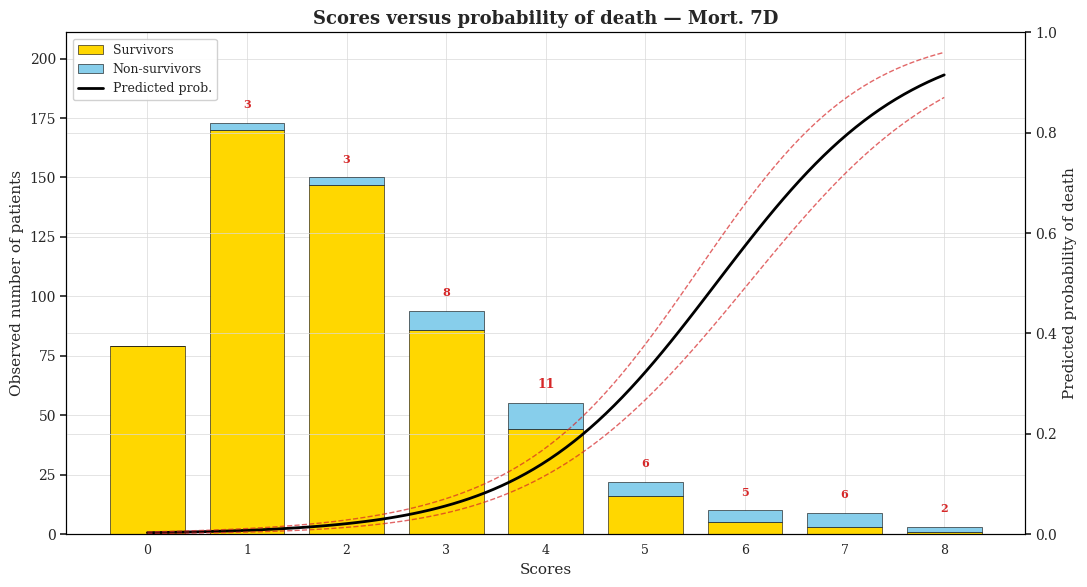

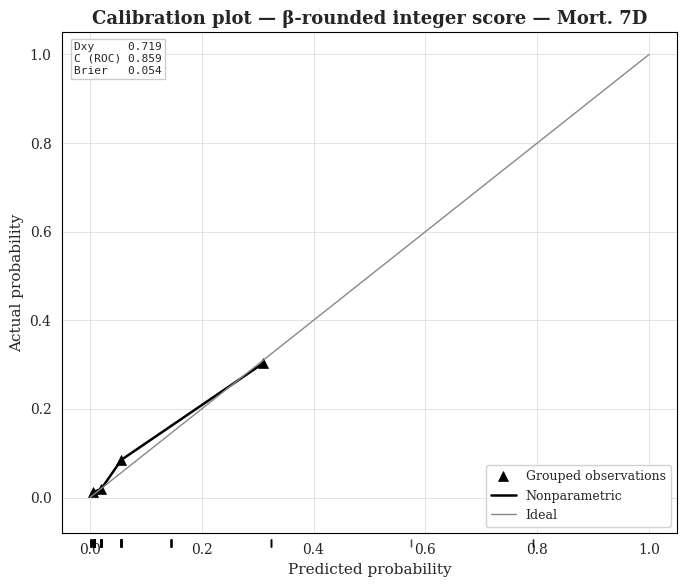

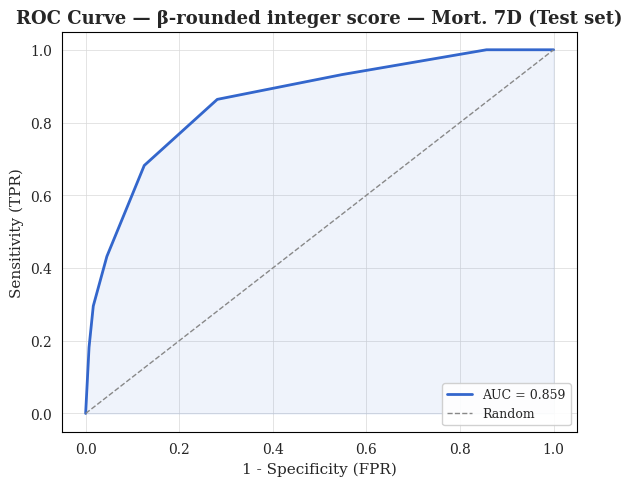

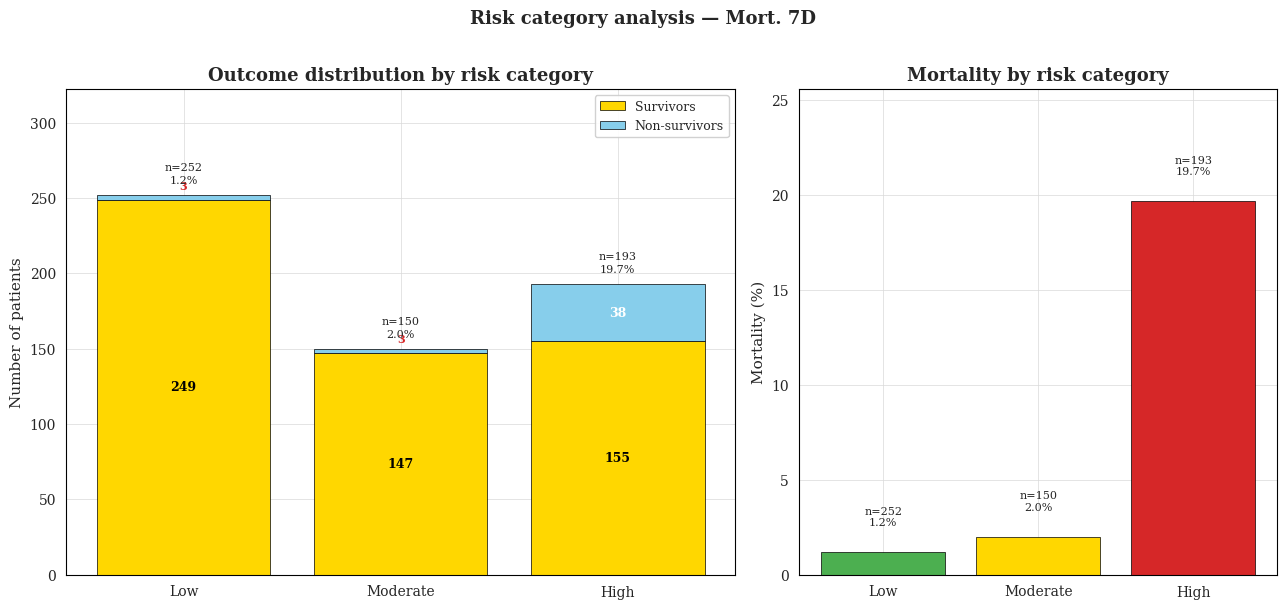

In [ ]:
"""
PURPOSE : Risk stratification + validation plots (Zhang et al. 2017 style).
          Each diagnostic plot is rendered as a SEPARATE figure.

Plots generated:
  Fig A — Scores vs probability of death (Zhang Fig 3)
  Fig B — Calibration plot (Zhang Fig 4)
  Fig C — ROC curve
  Fig D — Mortality by risk category (stacked absolute + mortality %)
"""

from sklearn.calibration import calibration_curve


# ── Simple automatic risk categories (TRAIN-only; no test-outcome optimisation)
def _risk_labels(n_categories: int) -> List[str]:
    """Human-readable labels for ordered risk categories."""
    if n_categories <= 1:
        return ["All"]
    if n_categories == 2:
        return ["Low", "High"]
    if n_categories == 3:
        return ["Low", "Moderate", "High"]
    if n_categories == 4:
        return ["Very Low", "Low", "Moderate", "High"]
    return [f"Risk {i + 1}" for i in range(n_categories)]


def _bins_from_thresholds(thresholds: Sequence[int]) -> List[float]:
    """Convert integer score thresholds into pd.cut bin edges."""
    return [-np.inf] + [float(t) + 0.5 for t in thresholds] + [np.inf]


def _group_table(scores: pd.Series, y: pd.Series,
                 thresholds: Sequence[int]) -> pd.DataFrame:
    """Training group table for a candidate set of score thresholds."""
    bins = _bins_from_thresholds(thresholds)
    groups = pd.cut(scores, bins=bins, labels=False, include_lowest=True, right=True)
    return (
        pd.DataFrame({"group": groups, "score": scores, "y": y})
        .groupby("group", observed=False)
        .agg(N=("y", "size"), Events=("y", "sum"), Mortality=("y", "mean"),
             Score_Min=("score", "min"), Score_Max=("score", "max"))
        .dropna(subset=["N"])
    )


def auto_risk_bins_from_train(
    train_scores: pd.Series,
    y_train: pd.Series,
    max_categories: int = 3,
    min_group_size: int = 40,
    enforce_monotonic: bool = True,
) -> Tuple[List[float], Tuple[str, ...], pd.DataFrame]:
    """
    Build risk-score bins automatically using TRAIN data only.

    The score is discrete, so quantiles can collapse to the same value. Duplicate
    thresholds are removed. Adjacent groups are then merged if they are too small
    and, optionally, if training mortality is not monotonic.

    y_test is never used here.
    """
    s = pd.Series(train_scores).dropna().astype(int)
    y = pd.Series(y_train).loc[s.index].astype(int)

    unique_scores = np.sort(s.unique())
    if len(unique_scores) <= 1:
        bins = [-np.inf, np.inf]
        labels = tuple(_risk_labels(1))
        tab = _group_table(s, y, [])
        return bins, labels, tab

    max_categories = int(max(1, min(max_categories, len(unique_scores))))
    min_group_size = int(max(1, min_group_size))

    # Initial quantile-like thresholds on the TRAIN score distribution.
    probs = np.linspace(0, 1, max_categories + 1)[1:-1]
    thresholds = sorted({
        int(np.floor(np.quantile(s, q)))
        for q in probs
    })
    thresholds = [t for t in thresholds if s.min() <= t < s.max()]

    # If quantiles collapse too much, fall back to evenly spaced unique scores.
    if len(thresholds) < max_categories - 1 and len(unique_scores) > 2:
        candidate_idx = np.linspace(1, len(unique_scores) - 1, max_categories, dtype=int)[:-1]
        extra = [int(unique_scores[i - 1]) for i in candidate_idx]
        thresholds = sorted(set(thresholds + extra))
        thresholds = [t for t in thresholds if s.min() <= t < s.max()]

    # Keep only the first max_categories - 1 thresholds.
    thresholds = thresholds[: max_categories - 1]

    # Merge adjacent groups until every group is large enough.
    while thresholds:
        tab = _group_table(s, y, thresholds)
        if tab["N"].min() >= min_group_size:
            break

        smallest_pos = int(np.argmin(tab["N"].to_numpy()))
        if smallest_pos == 0:
            del thresholds[0]
        elif smallest_pos >= len(thresholds):
            del thresholds[-1]
        else:
            left_n = tab["N"].iloc[smallest_pos - 1]
            right_n = tab["N"].iloc[smallest_pos + 1]
            if left_n <= right_n:
                del thresholds[smallest_pos - 1]
            else:
                del thresholds[smallest_pos]

    # Merge adjacent groups until training mortality is non-decreasing.
    if enforce_monotonic:
        while thresholds:
            tab = _group_table(s, y, thresholds)
            mortality = tab["Mortality"].to_numpy(dtype=float)

            violation = None
            for k in range(len(mortality) - 1):
                if mortality[k] > mortality[k + 1]:
                    violation = k
                    break

            if violation is None:
                break

            # threshold k separates group k from group k+1
            del thresholds[violation]

    bins = _bins_from_thresholds(thresholds)
    labels = tuple(_risk_labels(len(bins) - 1))
    train_tab = _group_table(s, y, thresholds)
    train_tab.index = labels[:len(train_tab)]
    return bins, labels, train_tab


bins_risk, RISK_LABELS, risk_train_table = auto_risk_bins_from_train(
    train_scores=train_scores,
    y_train=y_train,
    max_categories=RISK_MAX_CATEGORIES,
    min_group_size=RISK_MIN_GROUP_SIZE,
    enforce_monotonic=RISK_ENFORCE_MONOTONIC,
)

print("Risk-strata method: automatic train-only")
print(f"Risk bins for {TARGET_COL}: {bins_risk}")
print(f"Labels: {RISK_LABELS}")

display(Markdown(f"### Risk strata learned on TRAIN — {TARGET_COL}"))
display(risk_train_table.assign(**{"Mortality %": lambda d: (100 * d["Mortality"]).round(2)}))

df_eval_test = pd.DataFrame({"score": test_scores.values, "outcome": y_test.values})
cat_dtype = pd.api.types.CategoricalDtype(categories=RISK_LABELS, ordered=True)
df_eval_test["category"] = pd.cut(
    df_eval_test["score"],
    bins=bins_risk,
    labels=RISK_LABELS,
    include_lowest=True,
    right=True,
).astype(cat_dtype)

risk_test = (
    df_eval_test.groupby("category", observed=False)
    .agg(**{
        "Score Min": ("score", "min"),
        "Score Max": ("score", "max"),
        "N": ("outcome", "count"),
        "Events": ("outcome", "sum"),
        "Mortality": ("outcome", "mean"),
    })
    .assign(**{
        "Mortality %":  lambda d: (d["Mortality"] * 100).round(2),
        "% Population": lambda d: (d["N"] / d["N"].sum() * 100).round(1),
    })
)
risk_test["N"]         = risk_test["N"].fillna(0).astype(int)
risk_test["Events"]    = risk_test["Events"].fillna(0).astype(int)
risk_test["Survivors"] = (risk_test["N"] - risk_test["Events"]).astype(int)

display(Markdown(f"### Risk stratification table — TEST {TARGET_COL}"))
display(risk_test)

mort_vals_arr = risk_test.loc[risk_test["N"] > 0, "Mortality"].dropna().values
gradiente_ok = all(mort_vals_arr[k] <= mort_vals_arr[k + 1]
                   for k in range(len(mort_vals_arr) - 1))
print(f"Monotonic mortality gradient in TEST: {'Yes' if gradiente_ok else 'No (diagnostic only; cutoffs were learned on train)'}")


# ══════════════════════════════════════════════════════════════════════════════
# Fig A — Scores vs probability of death
# ══════════════════════════════════════════════════════════════════════════════
fig_a, ax_a = plt.subplots(figsize=(11, 6))

score_min, score_max = int(test_scores.min()), int(test_scores.max())
score_vals = np.arange(score_min, score_max + 1)

counts_surv = np.array([((y_test.values == 0) & (test_scores.values == s)).sum()
                        for s in score_vals])
counts_dead = np.array([((y_test.values == 1) & (test_scores.values == s)).sum()
                        for s in score_vals])
totals_per_score = counts_surv + counts_dead

# Y-axis headroom: 20 % above the tallest bar so annotations fit
y_max_a = max(totals_per_score) if totals_per_score.max() > 0 else 1
ax_a.set_ylim(0, y_max_a * 1.22)
annot_offset_a = y_max_a * 0.022   # proportional vertical gap above bar top

x_bar = np.arange(len(score_vals))
bar_w = 0.75
ax_a.bar(x_bar, counts_surv, width=bar_w,
         color=TFG_COLORS["survivors"],     edgecolor="black", linewidth=0.4,
         label="Survivors")
ax_a.bar(x_bar, counts_dead, width=bar_w, bottom=counts_surv,
         color=TFG_COLORS["non_survivors"], edgecolor="black", linewidth=0.4,
         label="Non-survivors")

# Annotate number of deaths — only when n_dead > 0
y_range     = ax_a.get_ylim()[1] - ax_a.get_ylim()[0]
min_offset  = y_range * 0.025

for x_pos, count, bar_top in zip(range(len(counts_dead)), counts_dead, totals_per_score):
    if count > 0:
        y_text = bar_top + min_offset
        fs     = 8 if count < 10 else 9
        ax_a.text(x_pos, y_text, str(int(count)),
                ha="center", va="bottom",
                color=TFG_COLORS["ref_line"], fontsize=fs, fontweight="bold")

ax_a.set_xticks(x_bar)
ax_a.set_xticklabels([str(s) for s in score_vals], fontsize=9)
ax_a.set_xlabel("Scores")
ax_a.set_ylabel("Observed number of patients")

# Predicted probability overlay (secondary axis)
ax2_a = ax_a.twinx()
try:
    import statsmodels.api as sm_api
    newx   = np.linspace(score_min, score_max, 100)
    newx_c = sm_api.add_constant(newx)
    # Use the GLM fitted on TRAIN in section 11; do not refit on test.
    prd    = glm_score_train.predict(newx_c)
    se     = glm_score_train.get_prediction(newx_c).se_mean
    ax2_a.plot(np.interp(newx, score_vals, x_bar), prd, "-",
               color=TFG_COLORS["pred_prob_line"], lw=2, label="Predicted prob.")
    ax2_a.plot(np.interp(newx, score_vals, x_bar), np.clip(prd + 1.96 * se, 0, 1),
               "--", color=TFG_COLORS["pred_prob_ci"], lw=1, alpha=0.7)
    ax2_a.plot(np.interp(newx, score_vals, x_bar), np.clip(prd - 1.96 * se, 0, 1),
               "--", color=TFG_COLORS["pred_prob_ci"], lw=1, alpha=0.7)
except Exception as _glm_err:
    print(f"\u26a0\ufe0f GLM overlay failed: {_glm_err}")

ax2_a.set_ylabel("Predicted probability of death")
ax2_a.set_ylim(0, 1.0)
ax2_a.set_yticks(np.arange(0, 1.05, 0.2))

lines1, labels1 = ax_a.get_legend_handles_labels()
lines2, labels2 = ax2_a.get_legend_handles_labels()
ax_a.legend(lines1 + lines2, labels1 + labels2,
            loc="upper left", fontsize=9, framealpha=0.9)
ax_a.set_title(f"Scores versus probability of death — {TARGET_COL}",
               fontweight="bold")
fig_a.tight_layout()
_save_fig(fig_a, f"fig_11A_scores_vs_prob_{TARGET_SUFFIX}.png")


# ══════════════════════════════════════════════════════════════════════════════
# Fig B — Calibration plot  (Zhang Fig 4)
# ══════════════════════════════════════════════════════════════════════════════
fig_b, ax_b = plt.subplots(figsize=(7, 6))

_n_distinct  = len(np.unique(np.round(p_test_score, 3)))
_n_cal_bins  = max(5, min(10, _n_distinct // 2))
frac_pos, mean_pred = calibration_curve(
    y_test.values, p_test_score, n_bins=_n_cal_bins, strategy="quantile")
ax_b.plot(mean_pred, frac_pos, "^",
          color=TFG_COLORS["calib_curve"], ms=7, lw=0,
          label="Grouped observations",
          markeredgecolor="black", markeredgewidth=0.5)

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess as _lws
    sort_idx   = np.argsort(mean_pred)
    xsm, ysm   = mean_pred[sort_idx], frac_pos[sort_idx]
    frac_cal   = max(0.35, min(0.75, 4 / max(len(xsm), 1)))
    smoothed_cal = _lws(endog=ysm, exog=xsm, frac=frac_cal, it=1, return_sorted=True)
    ax_b.plot(np.clip(smoothed_cal[:, 0], 0, 1),
              np.clip(smoothed_cal[:, 1], 0, 1),
              "-", color=TFG_COLORS["calib_curve"], lw=1.8, label="Nonparametric")
except Exception as _e:
    ax_b.plot(mean_pred, frac_pos, "-", color=TFG_COLORS["calib_curve"],
              lw=1.5, label="Nonparametric")

ax_b.plot([0, 1], [0, 1], "-", color=TFG_COLORS["ideal_line"], lw=1, label="Ideal")
MAX_RUG   = 300
rug_data  = p_test_score
if len(rug_data) > MAX_RUG:
    rng      = np.random.default_rng(RANDOM_STATE)
    rug_data = rng.choice(rug_data, size=MAX_RUG, replace=False)

ax_b.plot(rug_data, np.full_like(rug_data, -0.02),
        "|", color="black", alpha=0.25, linewidth=0.6,
        transform=ax_b.get_xaxis_transform(), clip_on=False)

auc_val_cal = roc_auc_score(y_test.values, test_scores.values)
brier_val   = brier_score_loss(y_test.values, p_test_score)
dxy_val     = 2 * auc_val_cal - 1
stats_text  = (f"Dxy     {dxy_val:.3f}\n"
               f"C (ROC) {auc_val_cal:.3f}\n"
               f"Brier   {brier_val:.3f}")
ax_b.text(0.02, 0.98, stats_text, transform=ax_b.transAxes, fontsize=8,
          verticalalignment="top", fontfamily="monospace",
          bbox=dict(boxstyle="square,pad=0.3", facecolor="white",
                    edgecolor="#cccccc"))
ax_b.set_xlabel("Predicted probability")
ax_b.set_ylabel("Actual probability")
ax_b.set_xlim(-0.05, 1.05)
ax_b.set_ylim(-0.08, 1.05)
ax_b.legend(loc="lower right", fontsize=9)
ax_b.set_title(f"Calibration plot — β-rounded integer score — {TARGET_COL}", fontweight="bold")
fig_b.tight_layout()
_save_fig(fig_b, f"fig_11B_calibration_{TARGET_SUFFIX}.png")


# ══════════════════════════════════════════════════════════════════════════════
# Fig C — ROC curve
# ══════════════════════════════════════════════════════════════════════════════
fig_c, ax_c = plt.subplots(figsize=(6, 5))

fpr, tpr, _ = roc_curve(y_test.values, test_scores.values)
auc_val     = roc_auc_score(y_test.values, test_scores.values)
ax_c.plot(fpr, tpr, "-", color=TFG_COLORS["loess_curve"], lw=2,
          label=f"AUC = {auc_val:.3f}")
ax_c.plot([0, 1], [0, 1], "--", color=TFG_COLORS["ideal_line"], lw=1, label="Random")
ax_c.fill_between(fpr, tpr, alpha=0.08, color=TFG_COLORS["loess_curve"])
ax_c.set_xlabel("1 - Specificity (FPR)")
ax_c.set_ylabel("Sensitivity (TPR)")
ax_c.set_title(f"ROC Curve — β-rounded integer score — {TARGET_COL} (Test set)", fontweight="bold")
ax_c.legend(loc="lower right")
fig_c.tight_layout()
_save_fig(fig_c, f"fig_11C_roc_{TARGET_SUFFIX}.png")


# ══════════════════════════════════════════════════════════════════════════════
# Fig D — Mortality by risk category (stacked + mortality %)
# ══════════════════════════════════════════════════════════════════════════════
cats      = risk_test.index.tolist()
n_surv_d  = risk_test["Survivors"].values.astype(int)
n_dead_d  = risk_test["Events"].values.astype(int)
n_total_d = risk_test["N"].values.astype(int)
mort_pct_d= risk_test["Mortality %"].values
x_pos     = np.arange(len(cats))
n_cat     = len(cats)

# ── Left panel: stacked absolute counts ──────────────────────────────────────
fig_d, axes_d = plt.subplots(1, 2, figsize=(13, 6),
                              gridspec_kw={"width_ratios": [1.4, 1]})
ax_d1 = axes_d[0]

# Y-axis: 25 % headroom above tallest bar for "n=total / xx.x%" annotation
y_max_d1 = int(n_total_d.max())
ax_d1.set_ylim(0, y_max_d1 * 1.28)
annot_gap_d1 = y_max_d1 * 0.025   # gap between bar top and annotation text

ax_d1.bar(x_pos, n_surv_d, color=TFG_COLORS["survivors"],
          edgecolor="black", linewidth=0.5, label="Survivors")
ax_d1.bar(x_pos, n_dead_d, bottom=n_surv_d,
          color=TFG_COLORS["non_survivors"], edgecolor="black",
          linewidth=0.5, label="Non-survivors")

# Minimum segment height (in data units) required to print text inside
_min_text_h = y_max_d1 * 0.04   # ~4 % of y-range

for xi, (ns, nd, nt, mp) in enumerate(
        zip(n_surv_d, n_dead_d, n_total_d, mort_pct_d)):

    # --- Survivor count inside the gold segment ---
    if ns >= _min_text_h:
        ax_d1.text(xi, ns / 2, str(int(ns)),
                   ha="center", va="center",
                   fontsize=9, color="black", fontweight="bold")
    else:
        # Segment too thin: show count just below bar top (outside)
        if ns > 0:
            ax_d1.text(xi, ns - annot_gap_d1 * 0.5, str(int(ns)),
                       ha="center", va="top", fontsize=8, color="black")

    # --- Death count inside the blue segment (or outside if too thin) ---
    if nd > 0:
        if nd >= _min_text_h:
            ax_d1.text(xi, ns + nd / 2, str(int(nd)),
                       ha="center", va="center",
                       fontsize=9, color="white", fontweight="bold")
        else:
            # Too thin: place count above the segment in red
            ax_d1.text(xi, ns + nd + annot_gap_d1 * 0.4, str(int(nd)),
                       ha="center", va="bottom", fontsize=8,
                       color=TFG_COLORS["ref_line"], fontweight="bold")

    # --- n=total / mortality % label above the complete bar ---
    ax_d1.text(xi, nt + annot_gap_d1, f"n={nt}\n{mp:.1f}%",
               ha="center", va="bottom", fontsize=8, linespacing=1.4)

ax_d1.set_xticks(x_pos)
ax_d1.set_xticklabels(cats, fontsize=10)
ax_d1.set_ylabel("Number of patients")
ax_d1.set_title("Outcome distribution by risk category", fontweight="bold")
ax_d1.legend(loc="upper right", fontsize=9)

# ── Right panel: mortality % (colour gradient low→high) ──────────────────────
ax_d2 = axes_d[1]

if n_cat <= 2:
    colors_bar = [TFG_COLORS["alive_leaf"], TFG_COLORS["ref_line"]]
elif n_cat == 3:
    colors_bar = [TFG_COLORS["alive_leaf"], TFG_COLORS["survivors"],
                  TFG_COLORS["ref_line"]]
else:
    colors_bar = [TFG_COLORS["alive_leaf"], TFG_COLORS["survivors"],
                  "#FF7F00", TFG_COLORS["ref_line"]]

# Y-axis headroom: 30 % above tallest bar
max_mort_pct = float(mort_pct_d.max()) if len(mort_pct_d) > 0 else 1.0
ax_d2.set_ylim(0, max(max_mort_pct * 1.30, 5.0))   # at least 5 % so label fits
annot_gap_d2 = max_mort_pct * 0.025

bars = ax_d2.bar(x_pos, mort_pct_d,
                 color=colors_bar[:n_cat],
                 edgecolor="black", linewidth=0.5)
ax_d2.set_xticks(x_pos)
ax_d2.set_xticklabels(cats, fontsize=10)
ax_d2.set_ylabel("Mortality (%)")
ax_d2.set_title("Mortality by risk category", fontweight="bold")

y_range = ax_d2.get_ylim()[1] - ax_d2.get_ylim()[0]
offset  = y_range * 0.03
min_gap = y_range * 0.05

for bar, label in zip(bars, [f"n={nt}\n{mp:.1f}%" for nt, mp in zip(n_total_d, mort_pct_d)]):
    bar_top = bar.get_height()
    y_pos   = max(bar_top + offset, bar_top + min_gap)
    ax_d2.text(bar.get_x() + bar.get_width() / 2, y_pos,
            label, ha="center", va="bottom", fontsize=8)

fig_d.suptitle(f"Risk category analysis — {TARGET_COL}",
               fontsize=13, fontweight="bold", y=1.01)
fig_d.tight_layout()
_save_fig(fig_d, f"fig_11D_risk_categories_{TARGET_SUFFIX}.png")


## **12. Clinical score card**

The following table summarises the integer point assignment for each variable level
following the β-rounding method.

To use at the bedside: sum the points for each variable and consult the automatically
derived, train-only risk category table to interpret the total score. The test set
is used only to report the observed mortality within those categories.

`VAR_DISPLAY` maps internal column names to English/Spanish labels; it includes
`ST_cat` for cases where ST is part of the active feature set.

> GCS is displayed as exact levels 3–15. Equal or zero point values across some
> levels are expected after Ridge shrinkage and β-rounding; the score should be
> interpreted as a whole rather than level-by-level in isolation.


In [ ]:
VAR_DISPLAY = {
    "Edad_cat":     ("Age",                "Edad",               "years"),
    "GCS_cat":      ("Glasgow Coma Scale", "Escala Glasgow",     "3–15"),
    "Lactato_cat":  ("Lactate",            "Lactato",            "mmol/L"),
    "SpO2_cat":     ("O2 Saturation",      "Saturación O2",      "%"),
    "O2_cat":       ("Supplemental O2",    "O2 Suplementario",   "0/1"),
    "TT_cat":       ("Temperature",        "Temperatura",        "°C"),
    "FR_cat":       ("Respiratory Rate",   "Frec. Respiratoria", "rpm"),
    "Glucemia_cat": ("Blood Glucose",      "Glucemia",           "mg/dL"),
    "TAM_cat":      ("Mean Arterial Pressure", "TAM",            "mmHg"),
    "Ritmo_cat":    ("Heart Rhythm",           "Ritmo cardiaco", "grupo clínico"),
    "ST_cat":       ("ST Segment",              "Segmento ST",        "grupo clínico"),
    "Resrv._cat":   ("Reservoir Mask O2",      "Reservorio",     "0/1"),
    "Gafas_cat":    ("Nasal Cannula O2",       "Gafas",          "0/1"),
    "VNI_cat":      ("Non-Invasive Ventilation","VNI",           "0/1"),
    "VAD_cat":      ("Vasoactive Drugs",       "VAD",            "0/1"),
    "Venturi_cat":  ("Venturi Mask O2",        "Venturi",        "0/1"),
}

print("═" * 80)
print(" " * 8 + f"EMERGENCY DEPARTMENT {TARGET_COL.upper()} MORTALITY RISK SCORE")
print(" " * 20 + "(Zhang et al., 2017 — β-rounding method)")
print("═" * 80)

for var in score_cat_cols:
    if var not in VAR_DISPLAY:
        continue
    name_en, name_es, unit = VAR_DISPLAY[var]
    var_data = points_df[points_df["variable"] == var].sort_values("points")
    print(f"\n{'─' * 80}")
    print(f"  {name_en} / {name_es}  [{unit}]")
    print(f"  {'─' * 50}")
    print(f"  {'Category':<35} {'β':>8} {'Points':>8} {'Ref':>6}")
    print(f"  {'─' * 59}")
    for _, row in var_data.iterrows():
        ref_mark = "✓" if row["is_reference"] else ""
        print(f"  {str(row['level']):<35} {row['beta']:>8.3f} "
              f"{int(row['points']):>8} {ref_mark:>6}")

print(f"\n{'═' * 80}")
print("RISK CATEGORY INTERPRETATION")
print(f"{'═' * 80}")
print(f"  {'Category':<12} {'Score Range':<15} {'Mortality %':>12} {'% Patients':>12}")
print(f"  {'─' * 55}")
for cat, row in risk_test.iterrows():
    sc_min = int(row['Score Min']) if pd.notna(row['Score Min']) else '?'
    sc_max = int(row['Score Max']) if pd.notna(row['Score Max']) else '?'
    print(f"  {str(cat):<12} {f'{sc_min}–{sc_max}':<15} "
          f"{row['Mortality %']:>11.1f}% {row['% Population']:>11.1f}%")

print(f"\n  Maximum theoretical score: {MAX_SCORE} points")
print(f"  AUC-ROC (test): {roc_auc_score(y_test, test_scores):.3f}  |  "
      f"Brier Score (score GLM): {brier_score_loss(y_test, p_test_score):.3f}")
print("═" * 80)

════════════════════════════════════════════════════════════════════════════════
        EMERGENCY DEPARTMENT MORT. 7D MORTALITY RISK SCORE
                    (Zhang et al., 2017 — β-rounding method)
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────
  Age / Edad  [years]
  ──────────────────────────────────────────────────
  Category                                   β   Points    Ref
  ───────────────────────────────────────────────────────────
  (-inf, 58]                             0.000        0      ✓
  (58, 72]                               0.724        1       
  (72, 85]                               0.936        1       
  (85, +inf]                             1.637        2       

────────────────────────────────────────────────────────────────────────────────
  Glasgow Coma Scale / Escala Glasgow  [3–15]
  ──────────────────────────────────────────────────
  C

## **13. Confusion matrix**

The optimal classification threshold is selected via the **Youden index**
`J = Sensitivity + Specificity − 1`, computed on the **training** integer
scores (`train_scores`) and then applied unchanged to the test partition.

Selecting the threshold on the test set would constitute test-set tuning and
inflate apparent classification performance.  Computing it on the training set
keeps the test partition independent of all parameter choices in the pipeline,
consistent with the design principle of Zhang et al. (2017).

The resulting sensitivity and specificity on the test set are reported as
held-out validation metrics.


Optimal threshold (Youden, on TRAIN): 3 points
  Train sensitivity: 0.915 | Train specificity: 0.735
  Test  sensitivity: 0.864 | Test  specificity: 0.719


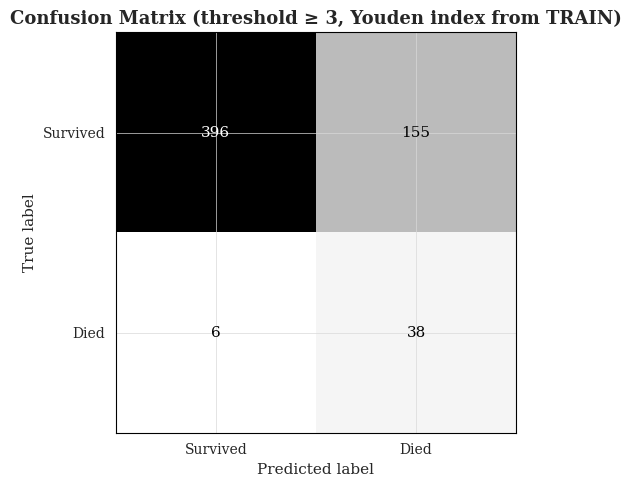


Classification Report (TEST):
              precision    recall  f1-score   support

    Survived       0.99      0.72      0.83       551
        Died       0.20      0.86      0.32        44

    accuracy                           0.73       595
   macro avg       0.59      0.79      0.58       595
weighted avg       0.93      0.73      0.79       595



In [ ]:
# Optimal threshold via Youden index on TRAIN; applied unchanged to TEST
fpr_tr, tpr_tr, thr_tr = roc_curve(y_train.values, train_scores.values)
youden_tr = tpr_tr - fpr_tr
best_idx_tr = int(np.argmax(youden_tr))
best_thr = float(thr_tr[best_idx_tr])

# Apply the train-derived threshold unchanged to the test partition
y_pred_opt = (test_scores.values >= best_thr).astype(int)

print(f"Optimal threshold (Youden, on TRAIN): {best_thr:.0f} points")
print(f"  Train sensitivity: {tpr_tr[best_idx_tr]:.3f} | "
      f"Train specificity: {1 - fpr_tr[best_idx_tr]:.3f}")

# Test-set diagnostic: compute the train-threshold metrics on TEST
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
cm = confusion_matrix(y_test.values, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
sens_test = tp / (tp + fn) if (tp + fn) > 0 else 0.0
spec_test = tn / (tn + fp) if (tn + fp) > 0 else 0.0
print(f"  Test  sensitivity: {sens_test:.3f} | "
      f"Test  specificity: {spec_test:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Survived", "Died"])
disp.plot(ax=ax, colorbar=False, cmap="Greys")
ax.set_title(f"Confusion Matrix (threshold ≥ {best_thr:.0f}, "
             f"Youden index from TRAIN)", fontweight="bold")
plt.tight_layout()
_save_fig(fig, f"fig_13_confusion_matrix_{TARGET_COL.replace(' ', '_').replace('.', '')}.png")

print("\nClassification Report (TEST):")
print(classification_report(y_test.values, y_pred_opt,
                             target_names=["Survived", "Died"]))


## **14. Conclusions**

### Risk scoring system performance

This notebook develops an endpoint-specific emergency department mortality score
following the β-rounding principle described by Zhang et al. (2017). Continuous
variables are discretised, reference categories are selected using the training
split only, Ridge logistic regression is fitted on the training data, and the
resulting β coefficients are converted into integer points.

For each active endpoint (`TARGET_COL`), the final variable set is defined in
`FEATURES_PER_OUTCOME[TARGET_COL]` after reviewing VIF, AIC/BIC, the multivariable
coefficient table, clinical plausibility, and interpretability of the score. The
printed summary at the end of the notebook contains the actual metrics for the
currently executed endpoint.

### Key findings

**Variable contributions:**
- **GCS** and **Lactate** consistently provide clinically meaningful information,
  reflecting neurological status and metabolic acidosis.
- **Age**, **SpO2**, and respiratory-support variables provide additional
  information, depending on the endpoint.
- Optional categorical variables such as **Ritmo** and **ST** are supported by the
  preprocessing pipeline, but are only included if selected for the active endpoint.

**Score design:**
- The integer scale facilitates bedside calculation without electronic tools.
- Exact GCS levels are retained by design, following the supervisor's recommendation;
  β-rounding may naturally assign the same or zero points to some levels.
- Risk strata are generated automatically from training scores only, then applied
  unchanged to the test set. The observed mortality gradient in test is therefore
  validation output, not an optimisation criterion.

---

> This scoring system can be used as the real-data reference for evaluating
> synthetic data utility. The next phase can train the same pipeline on synthetic
> data and test on real data (*Train on Synthetic, Test on Real*), comparing
> discrimination, calibration and risk-stratification behaviour across the three
> mortality endpoints.


### **Final summary**

The box below consolidates the key results of this notebook for the active target
outcome (`TARGET_COL`). It is printed last to ensure all upstream computations
(VIF, AIC/BIC, Ridge CV, score computation, validation, confidence intervals and
risk stratification) have already executed.

**Metrics reported:**
- `N test`, `Events test`, and `Event rate` — context for interpreting the endpoint.
- `AUC-ROC (Score)` — discrimination of the **integer score** on the test set.
- `AUC-PR (Score)` — precision-recall performance, useful when event prevalence is low.
- `Brier Score` — overall calibration + discrimination of the score-calibrated probability.
- `95% CI` — stratified bootstrap confidence interval for the fixed test-set score/model.
- `H-L p-value` — Hosmer-Lemeshow goodness-of-fit; p > 0.05 means no statistically significant evidence of major miscalibration.
- `Monotonic gradient` — checks whether the endpoint-specific risk categories show increasing observed mortality.
- Risk category table — score ranges, mortality %, and patient counts per stratum.

> Re-run the notebook with each value of `TARGET_COL` (`Mort. 2D`, `Mort. 7D`,
> `Mort. 30D`) to produce the corresponding tables for the three endpoints.


In [ ]:
# Final summary — integer scoring system on the test partition
auc_score_test = roc_auc_score(y_test.values, test_scores.values)
aupr_score_test = average_precision_score(y_test.values, test_scores.values)
brier_score_t  = metrics_score_test.get("Brier", float("nan"))
hl_p_score_t   = metrics_score_test.get("H-L p-value", float("nan"))

# Ridge headline (supporting evidence)
auc_ridge_test = roc_auc_score(y_test.values, p_test)
aupr_ridge_test = average_precision_score(y_test.values, p_test)
brier_ridge_t  = metrics_test.get("Brier", float("nan"))

n_test = int(len(y_test))
events_test = int(np.sum(y_test.values))
event_rate_test = 100 * events_test / n_test if n_test else float("nan")

def _ci_lookup(ci_df: pd.DataFrame, metric: str, fallback: float) -> str:
    """Return 'point [low, high]' from a CI table if available."""
    try:
        row = ci_df.loc[ci_df["Metric"].eq(metric)].iloc[0]
        return row["Formatted"]
    except Exception:
        return f"{fallback:.4f}"

auc_score_ci_str   = _ci_lookup(locals().get("score_test_ci", pd.DataFrame()), "AUC-ROC", auc_score_test)
aupr_score_ci_str  = _ci_lookup(locals().get("score_test_ci", pd.DataFrame()), "AUC-PR", aupr_score_test)
brier_score_ci_str = _ci_lookup(locals().get("score_test_ci", pd.DataFrame()), "Brier", brier_score_t)

auc_ridge_ci_str   = _ci_lookup(locals().get("ridge_test_ci", pd.DataFrame()), "AUC-ROC", auc_ridge_test)
aupr_ridge_ci_str  = _ci_lookup(locals().get("ridge_test_ci", pd.DataFrame()), "AUC-PR", aupr_ridge_test)
brier_ridge_ci_str = _ci_lookup(locals().get("ridge_test_ci", pd.DataFrame()), "Brier", brier_ridge_t)


def _row(label: str, value: str, width: int = 78) -> str:
    """Format a fixed-width box row."""
    content = f"  {label:<24}: {value}"
    return "║" + content + " " * max(width - len(content), 0) + "║"


print("\n")
print("╔" + "═" * 78 + "╗")
print("║" + f" RISK SCORING SYSTEM — FINAL SUMMARY ({TARGET_COL}) ".center(78) + "║")
print("╠" + "═" * 78 + "╣")
print(_row("Method",              "β-rounding (Zhang et al. 2017) on Ridge β"))
print(_row("Variables",           f"{len(score_cat_cols)} categorical predictors"))
print(_row("Max Score",           f"{MAX_SCORE} points"))
print(_row("Risk categories",     f"{len(RISK_LABELS)}"))
print(_row("Round threshold",     f"{ROUND_THRESHOLD}"))
print(_row("CLIP_NEGATIVE",       f"{CLIP_NEGATIVE}"))
print("╠" + "═" * 78 + "╣")
print("║" + " TEST SET CONTEXT ".center(78) + "║")
print(_row("N test",              f"{n_test}"))
print(_row("Events test",         f"{events_test}"))
print(_row("Event rate",          f"{event_rate_test:.2f}%"))
print("╠" + "═" * 78 + "╣")
print("║" + " INTEGER SCORING SYSTEM (test partition) ".center(78) + "║")
print(_row("AUC-ROC (Score)",     auc_score_ci_str))
print(_row("AUC-PR (Score)",      aupr_score_ci_str))
print(_row("Brier (Score, GLM)",  brier_score_ci_str))
print(_row("H-L p-value (Score)", f"{hl_p_score_t:.4f}"))
print("╠" + "═" * 78 + "╣")
print("║" + " RIDGE PROBABILITY MODEL (test partition, supporting) ".center(78) + "║")
print(_row("AUC-ROC (Ridge)",     auc_ridge_ci_str))
print(_row("AUC-PR (Ridge)",      aupr_ridge_ci_str))
print(_row("Brier (Ridge)",       brier_ridge_ci_str))
gradiente_ok = locals().get("gradiente_ok", None)
grad_str = ("Yes" if gradiente_ok is True else
            ("No" if gradiente_ok is False else "N/A"))
print("╠" + "═" * 78 + "╣")
print(_row("Monotonic gradient",  grad_str))
print("╠" + "═" * 78 + "╣")
print("║  RISK CATEGORY TABLE (test partition)" + " " * 40 + "║")
print("╟" + "─" * 78 + "╢")
header = f"  {'Category':<14} {'Score range':<13} {'Mortality %':>12} {'N':>8} {'% Cohort':>10}"
print("║" + header + " " * max(78 - len(header), 0) + "║")
print("╟" + "─" * 78 + "╢")
for cat, row in risk_test.iterrows():
    sc_min   = int(row["Score Min"])    if pd.notna(row["Score Min"]) else "?"
    sc_max   = int(row["Score Max"])    if pd.notna(row["Score Max"]) else "?"
    sc_range = f"{sc_min}-{sc_max}"
    n_pat    = int(row["N"])
    line = (f"  {str(cat):<14} {sc_range:<13} {row['Mortality %']:>11.1f}%"
            f" {n_pat:>8} {row['% Population']:>9.1f}%")
    print("║" + line + " " * max(78 - len(line), 0) + "║")
print("╚" + "═" * 78 + "╝")




╔══════════════════════════════════════════════════════════════════════════════╗
║                RISK SCORING SYSTEM — FINAL SUMMARY (Mort. 7D)                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Method                  : β-rounding (Zhang et al. 2017) on Ridge β         ║
║  Variables               : 9 categorical predictors                          ║
║  Max Score               : 11 points                                         ║
║  Risk categories         : 3                                                 ║
║  Round threshold         : 0.45                                              ║
║  CLIP_NEGATIVE           : True                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                               TEST SET CONTEXT                               ║
║  N test                  : 595                                               ║
║  Events test            

## **15. Export**

All figures have been saved to disk at the point of creation (5–13).
This cell saves the key **tables** as CSV files to the same output directory
(`OUTPUT_DIR = .../PREPROCESSING/NB4_RSS`).

| File | Content |
|------|---------|
| `tbl_03_vif_final_*.csv` | Final VIF table after iterative removal |
| `tbl_04_aic_history_*.csv` | AIC backward stepwise step-by-step history |
| `tbl_05_coef_table_*.csv` | β, OR, p-values for the AIC-selected model |
| `tbl_10_scoring_table_*.csv` | Integer points per (variable, level) |
| `tbl_11_validation_metrics_*.csv` | AUC-ROC, AUC-PR, Brier, H-L per split |
| `tbl_11_metric_ci_*.csv` | 95% bootstrap CI for test-set score and Ridge metrics |
| `tbl_11_clinical_metrics_*.csv` | Sensitivity / specificity per threshold |
| `tbl_11_risk_stratification_*.csv` | Train-derived risk category table applied to test |
| `score_config_*.json` | Scoring configuration needed to reproduce the NB4 scale in NB9 |

> Filenames include the active `TARGET_COL` suffix for traceability.
> Run for each outcome (`Mort. 2D`, `Mort. 7D`, `Mort. 30D`) to produce the full set.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 15  EXPORT — Tables to OUTPUT_DIR
# ══════════════════════════════════════════════════════════════════════════════
"""
PURPOSE : Save key result tables from NB4 as CSV files to OUTPUT_DIR.
          Figures are saved at the point of creation in 5–13.

Input   : All variables are produced by the cells above (VIF, AIC, Ridge CV, etc.)
Output  : CSV files in OUTPUT_DIR keyed by section and TARGET_COL suffix.
"""

import os
import json
import pandas as pd

os.makedirs(OUTPUT_DIR, exist_ok=True)
_suffix = TARGET_SUFFIX
_saved = []

def _export_df(df_in, name):
    """Save a DataFrame to OUTPUT_DIR as a CSV file keyed by section and TARGET_COL suffix."""
    path = os.path.join(OUTPUT_DIR, f"{name}_{_suffix}.csv")
    df_in.to_csv(path, index=False)
    _saved.append(path)
    print(f"  ✓ {name}_{_suffix}.csv")

# 3 VIF final table
try:
    _export_df(vif_final, "tbl_03_vif_final")
except NameError:
    print("  — vif_final not found (3 may not have run)")

# 4 AIC stepwise history
try:
    _export_df(hist_aic, "tbl_04_aic_history")
except NameError:
    print("  — hist_aic not found (4 may not have run)")

# 5 Coefficient table (AIC model)
try:
    _export_df(coef_table_sm_full(sm_aic, drop_const=True), "tbl_05_coef_table")
except NameError:
    print("  — sm_aic not found (4 may not have run)")

# 10 Scoring table
try:
    _export_df(points_df, "tbl_10_scoring_table")
except NameError:
    print("  — points_df not found (10.4 may not have run)")

# 11 Validation metrics (train + test combined)
try:
    _rows = []
    for split_name, m_dict in [("train", metrics_train), ("test", metrics_test)]:
        for k, v in m_dict.items():
            _rows.append({"split": split_name, "metric": k, "value": v})
    _export_df(pd.DataFrame(_rows), "tbl_11_validation_metrics")
except NameError:
    print("  — metrics_train / metrics_test not found (11 may not have run)")

# 11 Clinical metrics at multiple thresholds
try:
    _export_df(clinical_df, "tbl_11_clinical_metrics")
except NameError:
    print("  — clinical_df not found (11 may not have run)")

# 11 Test metric confidence intervals
try:
    _ci_rows = []
    for model_name, ci_df in [("score", score_test_ci), ("ridge", ridge_test_ci)]:
        tmp = ci_df.copy()
        tmp.insert(0, "model", model_name)
        _ci_rows.append(tmp)
    _export_df(pd.concat(_ci_rows, ignore_index=True), "tbl_11_metric_ci")
except NameError:
    print("  — score_test_ci / ridge_test_ci not found (11 may not have run)")

# 11 Risk stratification table
try:
    _export_df(risk_test.reset_index(), "tbl_11_risk_stratification")
except NameError:
    print("  — risk_test not found (11 may not have run)")

# 15 Reproducibility config for NB9 / TSTR
try:
    _reference_levels = {
        c: str(list(X_train_s[c].cat.categories)[0])
        for c in score_cat_cols
    }

    _score_config = {
        "target": TARGET_COL,
        "target_suffix": TARGET_SUFFIX,
        "features": list(FEATURES),
        "score_cat_cols": list(score_cat_cols),
        "round_threshold": float(ROUND_THRESHOLD),
        "clip_negative": bool(CLIP_NEGATIVE),
        "right_true_vars": sorted(list(RIGHT_TRUE_VARS)),
        "right_false_vars": sorted(list(RIGHT_FALSE_VARS)),
        "binary_vars": sorted(list(BINARY_VARS)),
        "gcs_vars": sorted(list(GCS_VARS)),
        "gcs_levels": [int(x) for x in GCS_LEVELS],
        "clinical_cuts": CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {}),
        "reference_levels": _reference_levels,
        # ── NB9 TRTR reproducibility: exact integer score map from NB4 ──────
        "score_map": [
            {"variable": row["variable"], "level": row["level"],
             "beta": float(row["beta"]), "points": int(row["points"])}
            for _, row in points_df.iterrows()
        ],
        "max_score": int(MAX_SCORE),
    }

    _config_path = os.path.join(OUTPUT_DIR, f"score_config_{_suffix}.json")
    with open(_config_path, "w", encoding="utf-8") as f:
        json.dump(_score_config, f, indent=2, ensure_ascii=False)
    _saved.append(_config_path)
    print(f"  ✓ score_config_{_suffix}.json")
except Exception as e:
    print(f"  — score_config export failed: {e}")

os.remove("/content/dataset_FINAL.csv")

print(f"\n✅ Export complete — {len(_saved)} table(s) saved to:\n   {OUTPUT_DIR}")


  ✓ tbl_03_vif_final_Mort_7D.csv
  ✓ tbl_04_aic_history_Mort_7D.csv
  ✓ tbl_05_coef_table_Mort_7D.csv
  ✓ tbl_10_scoring_table_Mort_7D.csv
  ✓ tbl_11_validation_metrics_Mort_7D.csv
  ✓ tbl_11_clinical_metrics_Mort_7D.csv
  ✓ tbl_11_metric_ci_Mort_7D.csv
  ✓ tbl_11_risk_stratification_Mort_7D.csv
  ✓ score_config_Mort_7D.json

✅ Export complete — 9 table(s) saved to:
   /content/drive/MyDrive/Colab Notebooks/TFG/PREPROCESSING/NB4_RSS
